# Diagnóstico de marca empleadora: CompuCom y sus peers
## Sentiment analysis (transformers) + topic modeling (BERTopic) sobre reseñas de Glassdoor

**Encargo de RRHH:** identificar los puntos fuertes y las áreas de mejora de CompuCom como empleador, a partir de lo que dicen sus empleados en Glassdoor, y compararlos con los de sus competidores directos.

## Empresa y comparabilidad
Se seleccionan **tres peers de servicios TI: Infogain, World Wide Technology y Rackspace Technology**, con una escala histórica de aproximadamente 5.000–11.000 personas. El solapamiento de ingeniería, infraestructura, cloud y operación tecnológica permite inferir competencia por perfiles técnicos; es una comparación de actividad y orden de magnitud, no de plantillas idénticas.

| Sección | Contenido |
|---|---|
| 0 | Carga y preparación |
| 1 | EDA: rating, recomendación, empleados actuales vs. antiguos |
| 2 | Sentimiento en pros y cons (control de calidad) |
| 3 | Topic modeling con BERTopic |
| 4 | Comparación con peers: peso de cada topic y balance neto |
| 5 | Empleados actuales vs. antiguos |
| 6 | Conclusiones y recomendaciones para RRHH |

Se toman hasta **1.000 reseñas por empresa, semilla 42**: equilibra el peso en los modelos conjuntos y acota el coste, pero añade variabilidad y no elimina sesgo de participación.

In [1]:
import hashlib
import importlib.metadata as metadata
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown

TARGET = "CompuCom"
PEERS = ["Infogain", "World-Wide-Technology", "Rackspace-Technology"]
FIRMS = [TARGET] + PEERS
MAX_POR_EMPRESA = 1000
SEED = 42
REENTRENAR_MODELOS = False
RUTA_DATOS = Path("glassdoor_reviews_hr.parquet")
RUTA_NOTEBOOK = Path("Glassdoor_ejemplo.ipynb")
MODELO_SENTIMIENTO = "distilbert-base-uncased-finetuned-sst-2-english"
MODELO_EMBEDDINGS = "sentence-transformers/all-MiniLM-L6-v2"
REVISION_SENTIMIENTO = "714eb0fa89d2f80546fda750413ed43d93601a13"
REVISION_EMBEDDINGS = "1110a243fdf4706b3f48f1d95db1a4f5529b4d41"
VERSIONES_REFERENCIA = {
    "numpy": "2.5.3", "pandas": "3.0.6", "matplotlib": "3.11.2",
    "pyarrow": "25.0.1", "torch": "2.14.1", "transformers": "5.18.0",
    "bertopic": "0.17.4", "sentence-transformers": "6.1.0",
    "umap-learn": "0.5.12", "hdbscan": "0.8.44", "scikit-learn": "1.9.1",
}
CONFIGURACION_TOPICS = {
    "vectorizer": {"stop_words": "english", "ngram_range": [1, 2], "min_df": 5},
    "umap": {"n_neighbors": 15, "n_components": 5, "min_dist": 0.0, "metric": "cosine", "random_state": 42},
    "pros": {"min_cluster_size": 30, "min_samples": 30, "cluster_selection_method": "eom"},
    "cons": {"min_cluster_size": 30, "min_samples": 10, "cluster_selection_method": "leaf"},
}
instaladas = {}
for paquete in VERSIONES_REFERENCIA:
    try:
        instaladas[paquete] = metadata.version(paquete)
    except metadata.PackageNotFoundError:
        instaladas[paquete] = "No instalado"
entorno = pd.DataFrame({"referencia": VERSIONES_REFERENCIA, "instalada": instaladas})
display(entorno)
if REENTRENAR_MODELOS and not entorno["referencia"].eq(entorno["instalada"]).all():
    raise RuntimeError("El entrenamiento requiere el entorno de referencia para mantener la taxonomía auditada.")

def fmt(valor, decimales=2):
    return f"{valor:,.{decimales}f}".replace(",", "_").replace(".", ",").replace("_", ".")

def mostrar(texto):
    display(Markdown(texto))

# Las mismas figuras se muestran en el notebook y en la presentación.
from IPython.display import Image as ImagenNotebook
RUTA_GRAFICAS = RUTA_DATOS.parent / "graficas_glassdoor"
GRAFICAS_PRESENTACION = {}
TEAL, NAVY, GREY, RED, GOLD = ('#137A8A', '#152B3B', '#8DA4B1', '#BB5148', '#C99128')
LIGHT, MUTED = ('#F3F6F9', '#536A7D')
NAMES = {'CompuCom': 'CompuCom', 'Infogain': 'Infogain', 'World-Wide-Technology': 'WWT', 'Rackspace-Technology': 'Rackspace'}
SHORT = {'Compensación y beneficios': 'Compensación', 'Conciliación y carga de trabajo': 'Conciliación y carga', 'Carrera y desarrollo': 'Carrera', 'Management y liderazgo': 'Liderazgo', 'Cultura y ambiente': 'Cultura', 'Instalaciones y servicios': 'Instalaciones', 'Aprendizaje y formación': 'Aprendizaje', 'Proyectos y clientes': 'Proyectos / clientes', 'Procesos y políticas internas': 'Procesos / políticas', 'Ubicación y movilidad': 'Ubicación', 'Estabilidad laboral': 'Estabilidad'}
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 16,
    "axes.titlesize": 20, "axes.labelsize": 16,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.spines.bottom": False,
    "text.color": NAVY, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": NAVY,
    "figure.facecolor": "white", "axes.facecolor": "white"})
def f(value, digits=2):
    return f'{value:,.{digits}f}'.replace(',', '_').replace('.', ',').replace('_', '.')

def polish(ax, unit=None):
    ax.grid(axis='x', alpha=0.16, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', length=0)
    if unit:
        ax.set_xlabel(unit)

def pairbars(ax, a, b, labels, limit, title, unit, digits=1, colors=(TEAL, GREY), legends=('CompuCom', 'Media peers')):
    y = np.arange(len(labels))
    h = 0.3
    ax.barh(y - h / 2, a, height=h, color=colors[0], label=legends[0], zorder=3)
    ax.barh(y + h / 2, b, height=h, color=colors[1], label=legends[1], zorder=3)
    for values, offset in [(a, -h / 2), (b, h / 2)]:
        for i, v in enumerate(values):
            ax.text(v + limit * 0.015, i + offset, f(v, digits), va='center', fontsize=14)
    ax.set(yticks=y, yticklabels=labels, xlim=(0, limit), title=title)
    ax.invert_yaxis()
    polish(ax, unit)

def guardar_grafica(fig, nombre):
    """Exporta y muestra una única figura; el PPT utiliza exactamente este PNG."""
    RUTA_GRAFICAS.mkdir(parents=True, exist_ok=True)
    png = RUTA_GRAFICAS / f"{nombre}.png"
    fig.savefig(png, dpi=200, bbox_inches="tight", facecolor="white")
    fig.savefig(RUTA_GRAFICAS / f"{nombre}.svg", bbox_inches="tight", facecolor="white")
    GRAFICAS_PRESENTACION[nombre] = str(png.resolve())
    display(ImagenNotebook(data=png.read_bytes()))
    plt.close(fig)


,referencia,instalada
numpy,2.5.3,2.5.3
pandas,3.0.6,3.0.6
matplotlib,3.11.2,3.11.2
pyarrow,25.0.1,25.0.1
torch,2.14.1,2.14.1
transformers,5.18.0,5.18.0
bertopic,0.17.4,0.17.4
sentence-transformers,6.1.0,6.1.0
umap-learn,0.5.12,0.5.12
hdbscan,0.8.44,0.8.44


## 0. Preparación y control de datos
La fuente es el Parquet , procedente de Glassdoor Job Reviews 1 y 2. La ventana anunciada es julio de 2018–julio de 2023; se informa también la cobertura efectiva.

Se filtran las empresas y se muestrea con semilla fija. Se separan situación y antigüedad; `o` se conserva como **Sin opinión**, no como neutralidad. Se normalizan espacios y marcadores de ausencia. «No cons» se conserva porque es una opinión, no un dato perdido. Se comprueban duplicados, fechas, ratings y códigos.

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt




# Configuración declarada en la celda anterior.


# Tope de reseñas por empresa: acota el tiempo de cómputo y evita que el peer
# más grande domine el modelo de topics conjunto



raw = pd.read_parquet(RUTA_DATOS, filters=[('firm', 'in', FIRMS)])
print('Reseñas disponibles por empresa:')
print(raw['firm'].value_counts())

df = pd.concat([g.sample(n=min(MAX_POR_EMPRESA, len(g)), random_state=SEED)
                for _, g in raw.groupby('firm')], ignore_index=True)
print(f'\nMuestra de trabajo: {len(df):,} reseñas')
disponibilidad = pd.DataFrame({"n_disponibles": raw.groupby("firm").size(), "n_muestra": df.groupby("firm").size()}).reindex(FIRMS)
display(disponibilidad)
def situacion(s):
    s = str(s).lower()
    if s.startswith('current'):
        return 'Actual'
    if s.startswith('former'):
        return 'Antiguo'
    return 'Desconocido'

def antiguedad(s):
    m = re.search(r'(less|more) than (\d+) year', str(s))
    return f'{m.group(1)} than {m.group(2)}y' if m else 'No disponible'

df['situacion'] = df['current'].map(situacion)
df['antiguedad'] = df['current'].map(antiguedad)
df['recomienda'] = df['recommend'].map({'v': 'Sí', 'o': 'Sin opinión', 'x': 'No'})
df['date_review'] = pd.to_datetime(df['date_review'], errors='coerce')
df['anio'] = df['date_review'].dt.year

for col in ['pros', 'cons']:
    textos = df[col].fillna('').astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
    marcadores_ausencia = textos.str.lower().isin({'nan', 'none', '<na>'})
    df[col] = textos.mask(marcadores_ausencia, '')

print(df['situacion'].value_counts())
print('Textos vacíos o ausentes por empresa:')
display(
    df.assign(
        pros_vacio=df['pros'].eq(''),
        cons_vacio=df['cons'].eq(''),
    )
    .groupby('firm')[['pros_vacio', 'cons_vacio']]
    .sum()
    .reindex(FIRMS)
)

campos_originales = ["firm", "date_review", "current", "overall_rating", "recommend", "pros", "cons"]
n_duplicados = int(df.duplicated(subset=campos_originales).sum())
control_datos = df.groupby("firm").agg(
    n_resenas=("firm", "size"), n_rating_ausente=("overall_rating", lambda s: s.isna().sum()),
    n_recommend_ausente=("recommend", lambda s: s.isna().sum()),
    n_fecha_ausente=("date_review", lambda s: s.isna().sum()),
    n_situacion_desconocida=("situacion", lambda s: s.eq("Desconocido").sum()),
    n_antiguedad_ausente=("antiguedad", lambda s: s.eq("No disponible").sum()),
    n_pros_vacios=("pros", lambda s: s.eq("").sum()), n_cons_vacios=("cons", lambda s: s.eq("").sum()),
).reindex(FIRMS)
display(control_datos)
if set(FIRMS) != set(df["firm"]):
    raise ValueError("Falta alguna empresa elegida.")
if n_duplicados:
    raise ValueError("Hay duplicados; revisar antes de modelar.")
if df["date_review"].isna().any() or not df["overall_rating"].between(1,5).all():
    raise ValueError("Fechas ausentes o rating fuera de 1–5.")
if not df["recommend"].dropna().isin(["v", "o", "x"]).all():
    raise ValueError("Códigos de recomendación inesperados.")
huella_muestra = hashlib.sha256(
    df[campos_originales].to_json(orient="split", date_format="iso", force_ascii=False).encode()
).hexdigest()
resultados_guardados = {}
if not REENTRENAR_MODELOS:
    resultados_guardados = json.loads(RUTA_NOTEBOOK.read_text(encoding="utf-8"))["metadata"].get("glassdoor_resultados", {})
    esperado = {
        "huella_muestra": huella_muestra, "firmas": FIRMS, "semilla": SEED,
        "max_por_empresa": MAX_POR_EMPRESA, "revision_sentimiento": REVISION_SENTIMIENTO,
        "revision_embeddings": REVISION_EMBEDDINGS, "configuracion_topics": CONFIGURACION_TOPICS,
    }
    if any(resultados_guardados.get(k) != v for k, v in esperado.items()):
        raise ValueError("Resultados guardados incompatibles; activa entrenamiento y revisa etiquetas.")
mostrar(
    f"**Control:** {len(df):,} reseñas; {n_duplicados} duplicados. Cobertura observada "
    f"**{df['date_review'].min():%d/%m/%Y}–{df['date_review'].max():%d/%m/%Y}**. "
    "La antigüedad no disponible se conserva sin inventarla."
)

Reseñas disponibles por empresa:
firm
Rackspace-Technology     1874
Infogain                 1618
World-Wide-Technology    1276
CompuCom                 1093
Name: count, dtype: int64

Muestra de trabajo: 4,000 reseñas


,n_disponibles,n_muestra
firm,,
CompuCom,1093,1000
Infogain,1618,1000
World-Wide-Technology,1276,1000
Rackspace-Technology,1874,1000


situacion
Actual     2801
Antiguo    1199
Name: count, dtype: int64
Textos vacíos o ausentes por empresa:


,pros_vacio,cons_vacio
firm,,
CompuCom,0,0
Infogain,0,0
World-Wide-Technology,0,0
Rackspace-Technology,0,0


,n_resenas,n_rating_ausente,n_recommend_ausente,n_fecha_ausente,n_situacion_desconocida,n_antiguedad_ausente,n_pros_vacios,n_cons_vacios
firm,,,,,,,,
CompuCom,1000,0,0,0,0,252,0,0
Infogain,1000,0,0,0,0,236,0,0
World-Wide-Technology,1000,0,0,0,0,254,0,0
Rackspace-Technology,1000,0,0,0,0,265,0,0


**Control:** 4,000 reseñas; 0 duplicados. Cobertura observada **27/07/2018–04/07/2023**. La antigüedad no disponible se conserva sin inventarla.

## 1. EDA
Se informa número de reseñas, rating, recomendación y reparto por situación. Los porcentajes de recomendación usan respuestas disponibles, incluyendo «Sin opinión»; cada bloque incorpora una conclusión accionable.

In [3]:
resumen = df.groupby("firm").agg(
    n_resenas=("firm", "size"), rating_medio=("overall_rating", "mean"),
    n_recommend_validos=("recommend", "count"),
    pct_recomienda=("recommend", lambda s: s.dropna().eq("v").mean()*100),
    pct_sin_opinion=("recommend", lambda s: s.dropna().eq("o").mean()*100),
    pct_no_recomienda=("recommend", lambda s: s.dropna().eq("x").mean()*100),
    pct_actuales=("situacion", lambda s: s.eq("Actual").mean()*100),
    pct_antiguos=("situacion", lambda s: s.eq("Antiguo").mean()*100),
    pct_desconocidos=("situacion", lambda s: s.eq("Desconocido").mean()*100),
).reindex(FIRMS)
display(resumen.round(2))
media_rating_peers = resumen.loc[PEERS,"rating_medio"].mean()
media_recomienda_peers = resumen.loc[PEERS,"pct_recomienda"].mean()
mostrar(
    f"**Conclusión accionable — posición:** CompuCom tiene rating **{fmt(resumen.loc[TARGET,'rating_medio'])}/5** "
    f"frente a **{fmt(media_rating_peers)}**, y recomendación **{fmt(resumen.loc[TARGET,'pct_recomienda'],1)} %** "
    f"frente a **{fmt(media_recomienda_peers)} %** de media peer. Contrastar la brecha con escucha interna "
    "por equipo/ubicación antes de intervenir; las reseñas no representan a toda la plantilla."
)

,n_resenas,rating_medio,n_recommend_validos,pct_recomienda,pct_sin_opinion,pct_no_recomienda,pct_actuales,pct_antiguos,pct_desconocidos
firm,,,,,,,,,
CompuCom,1000,2.91,1000,31.1,27.1,41.8,53.8,46.2,0.0
Infogain,1000,3.80,1000,58.9,24.2,16.9,76.6,23.4,0.0
World-Wide-Technology,1000,4.10,1000,68.9,14.2,16.9,84.4,15.6,0.0
Rackspace-Technology,1000,3.48,1000,42.5,26.7,30.8,65.3,34.7,0.0


**Conclusión accionable — posición:** CompuCom tiene rating **2,91/5** frente a **3,79**, y recomendación **31,1 %** frente a **56,77 %** de media peer. Contrastar la brecha con escucha interna por equipo/ubicación antes de intervenir; las reseñas no representan a toda la plantilla.

### Gráfica 01 · Reputación: rating y recomendación

**Origen:** `resumen`, calculadas en el apartado 1. EDA.

Rating: media de overall_rating, en puntos sobre 5. Recomendación: porcentaje sobre respuestas disponibles, incluyendo «Sin opinión». Cada empresa aporta 1.000 reseñas. Las reseñas no representan a toda la plantilla.


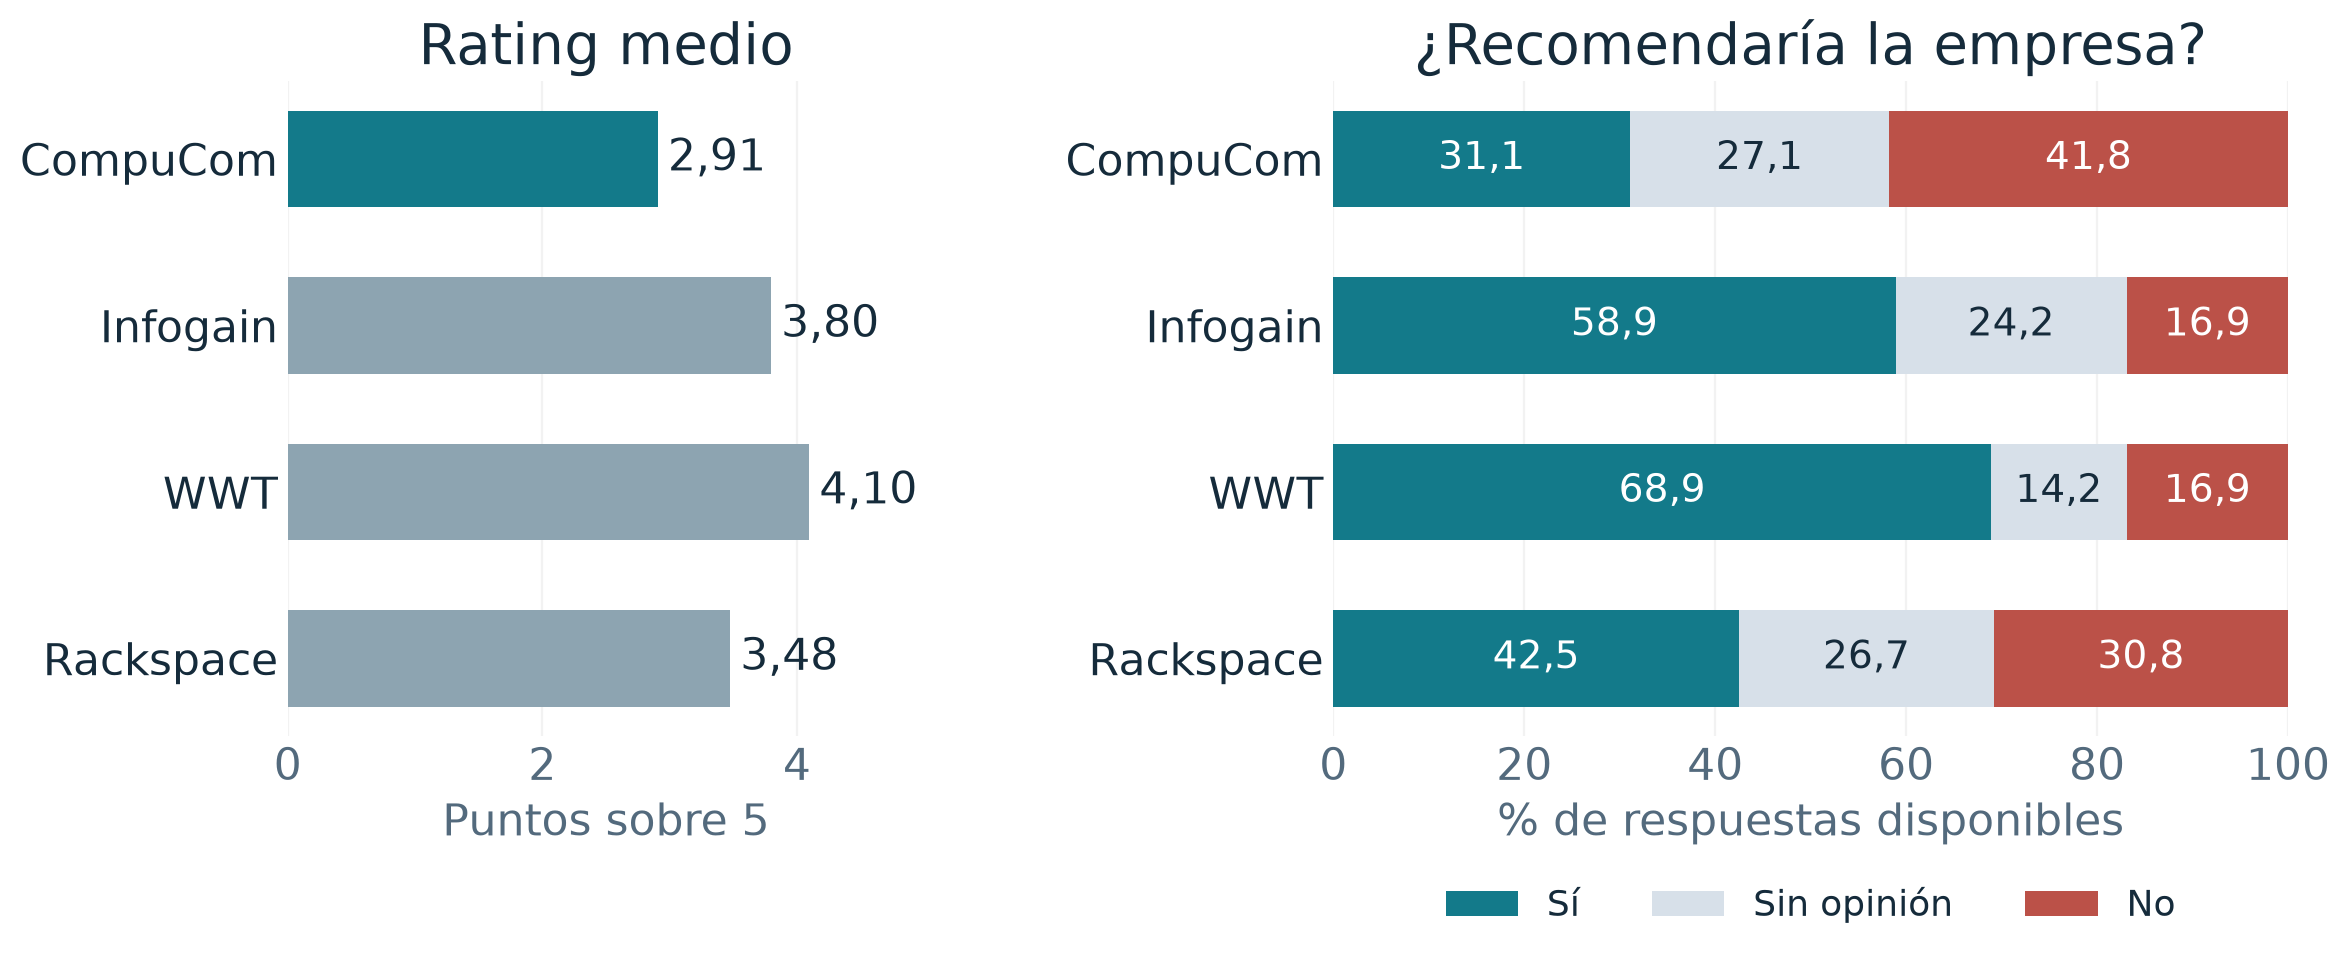

In [4]:
# Reputación: rating y recomendación
firms, target, peers = FIRMS, TARGET, PEERS
labels = [NAMES[x] for x in firms]
summary = resumen
y = np.arange(len(firms))
firms, target, peers = (FIRMS, TARGET, PEERS)
labels = [NAMES[x] for x in firms]
summary = resumen
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), gridspec_kw={'width_ratios': [0.8, 1.2]})
y = np.arange(4)
values = summary.loc[firms, 'rating_medio'].to_numpy()
axes[0].barh(y, values, color=[TEAL, GREY, GREY, GREY], height=0.58)
for i, v in enumerate(values):
    axes[0].text(v + 0.08, i, f(v), va='center', fontsize=16)
axes[0].set(yticks=y, yticklabels=labels, xlim=(0, 5), title='Rating medio')
axes[0].invert_yaxis()
polish(axes[0], 'Puntos sobre 5')
left = np.zeros(4)
for col, color, name in [('pct_recomienda', TEAL, 'Sí'), ('pct_sin_opinion', '#D7E0E9', 'Sin opinión'), ('pct_no_recomienda', RED, 'No')]:
    vals = summary.loc[firms, col].to_numpy()
    axes[1].barh(y, vals, left=left, color=color, height=0.58, label=name)
    for i, v in enumerate(vals):
        if v >= 9:
            axes[1].text(left[i] + v / 2, i, f(v, 1), ha='center', va='center', fontsize=14, color='white' if color != '#D7E0E9' else NAVY)
    left += vals
axes[1].set(yticks=y, yticklabels=labels, xlim=(0, 100), title='¿Recomendaría la empresa?')
axes[1].invert_yaxis()
polish(axes[1], '% de respuestas disponibles')
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False, fontsize=13)
fig.tight_layout(w_pad=3)
guardar_grafica(fig, '01_rating_recomendacion')


In [5]:
situaciones = ["Actual", "Antiguo"]
df_rating = df[df["situacion"].isin(situaciones)]

tabla_rating = (
    df_rating.groupby(["firm", "situacion"])
    .agg(
        n_resenas=("overall_rating", "count"),
        rating_medio=("overall_rating", "mean"),
    )
    .unstack("situacion")
    .reindex(FIRMS)
    .round(2)
    .sort_index(axis=1)
    .copy()
)

tabla_rating.columns = [f"{metrica}_{situacion.lower()}" for metrica, situacion in tabla_rating.columns]

for columna in [
    "n_resenas_actual",
    "n_resenas_antiguo",
    "rating_medio_actual",
    "rating_medio_antiguo",
]:
    if columna not in tabla_rating.columns:
        tabla_rating[columna] = np.nan

tabla_rating["diferencia_antiguo_menos_actual"] = tabla_rating["rating_medio_antiguo"] - tabla_rating["rating_medio_actual"]

display(tabla_rating.round(2))

# La figura compartida se genera en la celda de gráfica inmediatamente después.
mostrar(
    f"**Conclusión accionable — situación:** CompuCom aporta **{int(tabla_rating.loc[TARGET,'n_resenas_actual'])}** actuales "
    f"y **{int(tabla_rating.loc[TARGET,'n_resenas_antiguo'])}** antiguos, con ratings "
    f"**{fmt(tabla_rating.loc[TARGET,'rating_medio_actual'])}** y **{fmt(tabla_rating.loc[TARGET,'rating_medio_antiguo'])}**. "
    "Contrastar temas con entrevistas de salida y pulsos de actuales; el menor rating de antiguos puede reflejar selección "
    "y no demuestra por qué se marcharon."
)

,n_resenas_actual,n_resenas_antiguo,rating_medio_actual,rating_medio_antiguo,diferencia_antiguo_menos_actual
firm,,,,,
CompuCom,538,462,3.18,2.59,-0.59
Infogain,766,234,4.02,3.05,-0.97
World-Wide-Technology,844,156,4.24,3.32,-0.92
Rackspace-Technology,653,347,3.80,2.86,-0.94


**Conclusión accionable — situación:** CompuCom aporta **538** actuales y **462** antiguos, con ratings **3,18** y **2,59**. Contrastar temas con entrevistas de salida y pulsos de actuales; el menor rating de antiguos puede reflejar selección y no demuestra por qué se marcharon.

### Gráfica 02 · Quién opina: actuales y antiguos

**Origen:** `resumen`, `tabla_rating`, calculadas en el apartado 1. EDA.

El reparto usa todas las reseñas por empresa; el rating utiliza puntuaciones disponibles dentro de cada situación. Los denominadores se muestran en tabla_rating. El menor rating de antiguos es contexto de selección, no una causa de salida.



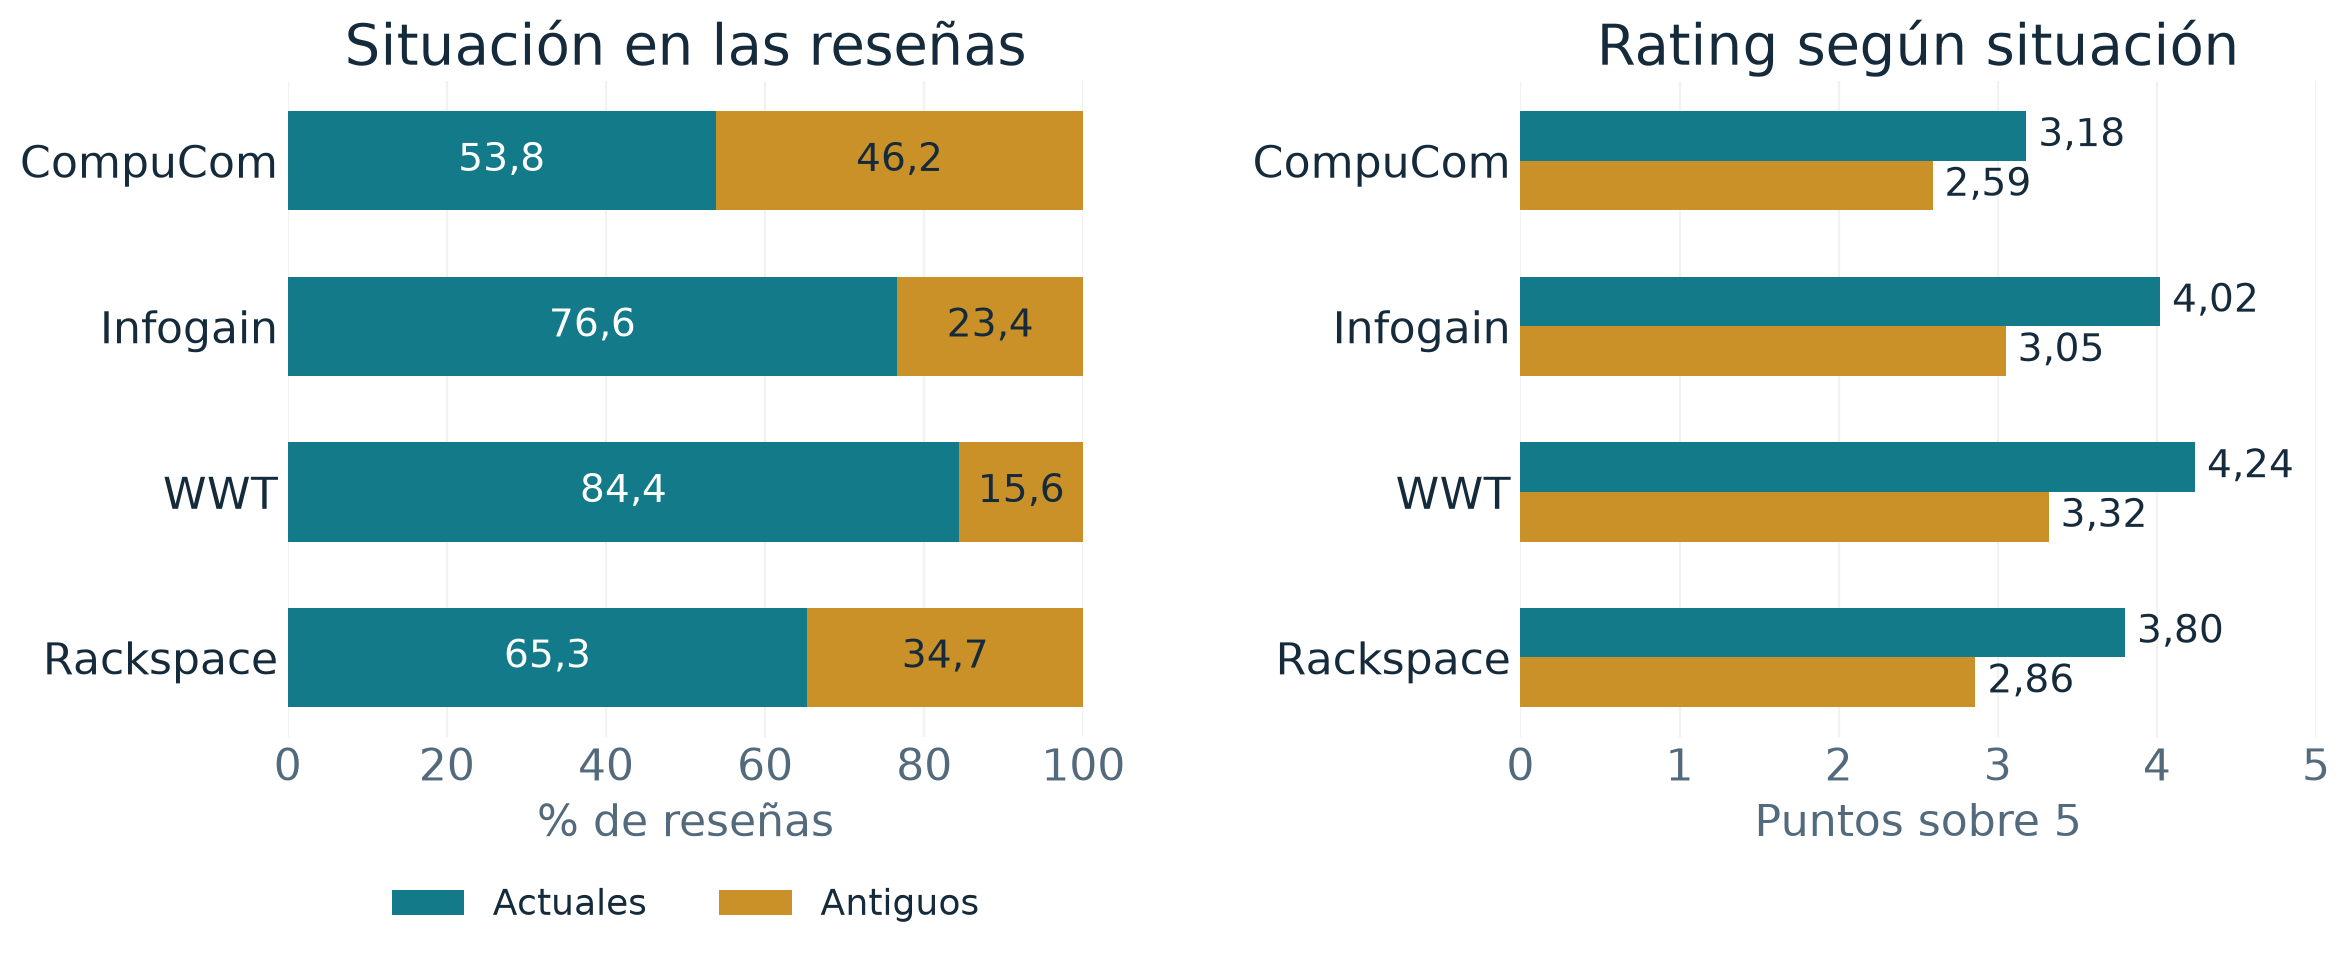

In [6]:
# Quién opina: actuales y antiguos
firms, target, peers = FIRMS, TARGET, PEERS
labels = [NAMES[x] for x in firms]
summary = resumen
y = np.arange(len(firms))
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
current = summary.loc[firms, 'pct_actuales'].to_numpy()
former = summary.loc[firms, 'pct_antiguos'].to_numpy()
axes[0].barh(y, current, color=TEAL, height=0.6, label='Actuales')
axes[0].barh(y, former, left=current, color=GOLD, height=0.6, label='Antiguos')
for i, (a, b) in enumerate(zip(current, former)):
    axes[0].text(a / 2, i, f(a, 1), ha='center', va='center', color='white', fontsize=14)
    axes[0].text(a + b / 2, i, f(b, 1), ha='center', va='center', color=NAVY, fontsize=14)
axes[0].set(yticks=y, yticklabels=labels, xlim=(0, 100), title='Situación en las reseñas')
axes[0].invert_yaxis()
polish(axes[0], '% de reseñas')
rating = tabla_rating
pairbars(axes[1], rating.loc[firms, 'rating_medio_actual'], rating.loc[firms, 'rating_medio_antiguo'], labels, 5, 'Rating según situación', 'Puntos sobre 5', 2, (TEAL, GOLD), ('Actuales', 'Antiguos'))
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False, fontsize=13)
fig.tight_layout(w_pad=3)
guardar_grafica(fig, '02_situacion_rating')


In [7]:
MIN_RESENAS_ANIO = 20

evolucion_rating = (
    df.dropna(subset=["anio", "overall_rating"])
    .groupby(["anio", "firm"])
    .agg(
        n_resenas=("overall_rating", "count"),
        rating_medio=("overall_rating", "mean"),
    )
    .reset_index()
    .sort_values(["anio", "firm"])
)

conteos_anuales = evolucion_rating.pivot(index="anio", columns="firm", values="n_resenas").reindex(columns=FIRMS).fillna(0).astype(int)
display(conteos_anuales)

medias_anuales = evolucion_rating.pivot(index="anio", columns="firm", values="rating_medio").reindex(columns=FIRMS)

# La figura compartida se genera en la celda de gráfica inmediatamente después.
print(f"En el gráfico se omiten los años con menos de {MIN_RESENAS_ANIO} reseñas por empresa; la tabla muestra todos los recuentos.")
display(medias_anuales.round(2))
anios_validos = conteos_anuales.index[conteos_anuales[TARGET].ge(MIN_RESENAS_ANIO)]
primero, ultimo = int(anios_validos.min()), int(anios_validos.max())
mostrar(
    f"**Conclusión accionable — evolución:** CompuCom pasa de **{fmt(medias_anuales.loc[primero,TARGET])}** "
    f"en {primero} (n={conteos_anuales.loc[primero,TARGET]}) a **{fmt(medias_anuales.loc[ultimo,TARGET])}** "
    f"en {ultimo} (n={conteos_anuales.loc[ultimo,TARGET]}). Revisar cambios de gestión o composición de reseñas "
    "que coincidan con la evolución y sostener seguimiento. No se atribuye causalidad; 2018/2023 son años parciales."
)

firm,CompuCom,Infogain,World-Wide-Technology,Rackspace-Technology
anio,,,,
2018,64,72,59,27
2019,158,187,150,112
2020,192,154,145,155
2021,301,298,267,347
2022,238,243,306,255
2023,47,46,73,104


En el gráfico se omiten los años con menos de 20 reseñas por empresa; la tabla muestra todos los recuentos.


firm,CompuCom,Infogain,World-Wide-Technology,Rackspace-Technology
anio,,,,
2018,2.44,3.36,4.17,3.67
2019,2.46,3.63,3.65,3.12
2020,2.64,3.65,4.53,3.65
2021,3.04,3.90,4.09,3.41
2022,3.27,4.02,4.12,3.61
2023,3.47,3.74,4.03,3.43


**Conclusión accionable — evolución:** CompuCom pasa de **2,44** en 2018 (n=64) a **3,47** en 2023 (n=47). Revisar cambios de gestión o composición de reseñas que coincidan con la evolución y sostener seguimiento. No se atribuye causalidad; 2018/2023 son años parciales.

### Gráfica 03 · Evolución del rating en el período observado

**Origen:** `medias_anuales`, `conteos_anuales`, calculadas en el apartado 1. EDA.

Rating medio por año y empresa. Los recuentos están en conteos_anuales. 2018 y 2023 son parciales; la evolución no demuestra efectos de políticas internas.



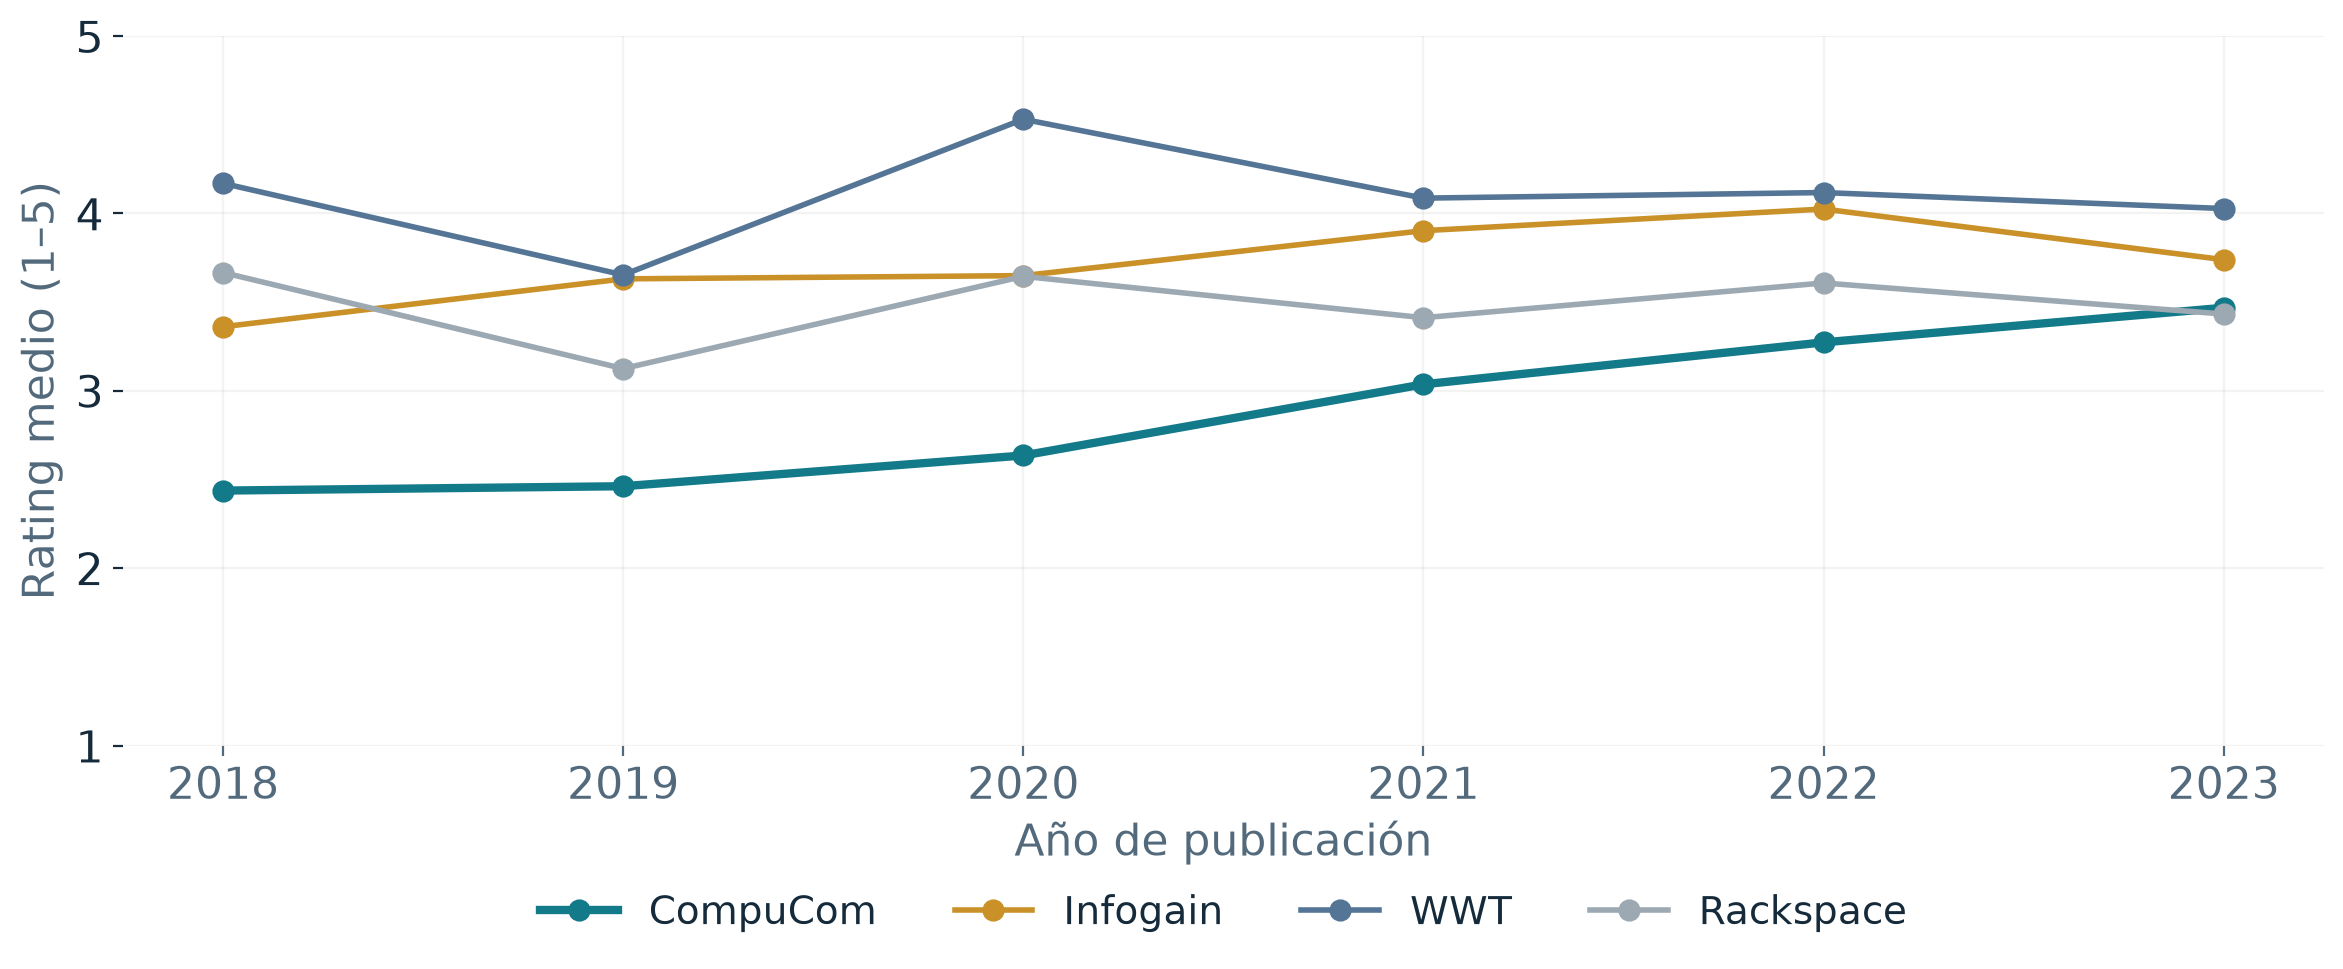

In [8]:
# Evolución del rating en el período observado
firms, target, peers = FIRMS, TARGET, PEERS
labels = [NAMES[x] for x in firms]
summary = resumen
y = np.arange(len(firms))
fig, ax = plt.subplots(figsize=(12, 5.2))
linecolors = [TEAL, GOLD, '#547595', '#9CA9B3']
for firm, color in zip(firms, linecolors):
    vals = medias_anuales[firm].where(conteos_anuales[firm] >= MIN_RESENAS_ANIO)
    ax.plot(vals.index, vals, marker='o', markersize=7, linewidth=3 if firm == target else 2, label=NAMES[firm], color=color)
ax.set(ylim=(1, 5), yticks=[1, 2, 3, 4, 5], xticks=medias_anuales.index, xlabel='Año de publicación', ylabel='Rating medio (1–5)')
ax.grid(alpha=0.15)
ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.16), frameon=False, fontsize=14)
fig.tight_layout()
guardar_grafica(fig, '03_evolucion_rating')


## 2. Sentimiento en pros y cons (control de calidad)
Se aplica el transformer binario en inglés `distilbert-base-uncased-finetuned-sst-2-english` a pros y cons por separado. Es una comprobación aproximada de polaridad; su entrenamiento general no equivale a validación en reseñas laborales y no tiene clase neutral.

Se usan lotes de 16, `truncation=True` y máximo 512 tokens. Los vacíos se excluyen del denominador y se informa cuánto texto se trunca. Se revisan por separado hasta dos pros negativos y dos cons positivos por empresa; no se exige discordancia doble en la misma reseña.

In [9]:
clasificador_sentimiento = tokenizador = None
if REENTRENAR_MODELOS:
    import torch
    from transformers import AutoTokenizer, pipeline
    torch.manual_seed(SEED)
    torch.set_num_threads(4)
    tokenizador = AutoTokenizer.from_pretrained(MODELO_SENTIMIENTO, revision=REVISION_SENTIMIENTO)
    clasificador_sentimiento = pipeline("text-classification", model=MODELO_SENTIMIENTO,
        revision=REVISION_SENTIMIENTO, device=0 if torch.cuda.is_available() else -1)
for columna in ["pros", "cons"]:
    validos = df[columna].ne("")
    ids = df.index[validos].tolist()
    textos = df.loc[validos,columna].tolist()
    if REENTRENAR_MODELOS:
        predicciones = clasificador_sentimiento(textos, batch_size=16, truncation=True, max_length=512) if textos else []
        etiquetas = [p["label"] for p in predicciones]
        confianzas = [float(p["score"]) for p in predicciones]
        longitudes = tokenizador(textos,truncation=False,add_special_tokens=True,return_length=True,verbose=False)["length"] if textos else []
    else:
        guardado = resultados_guardados["sentimiento"][columna]
        if guardado["review_id"] != ids: raise ValueError("IDs de sentimiento inconsistentes.")
        etiquetas, confianzas, longitudes = guardado["etiquetas"], guardado["confianzas"], guardado["longitudes_tokens"]
    if not (len(ids)==len(etiquetas)==len(confianzas)==len(longitudes)):
        raise ValueError("Predicciones incompletas.")
    if not set(etiquetas).issubset({"POSITIVE","NEGATIVE"}):
        raise ValueError("Etiqueta inesperada.")
    df[f"{columna}_sentimiento"] = pd.Series(pd.NA,index=df.index,dtype="object")
    df[f"{columna}_confianza"] = np.nan
    df[f"{columna}_truncado"] = False
    df.loc[validos,f"{columna}_sentimiento"] = etiquetas
    df.loc[validos,f"{columna}_confianza"] = confianzas
    df.loc[validos,f"{columna}_truncado"] = np.array(longitudes)>512

def porcentaje_etiqueta(s, etiqueta):
    return s.dropna().eq(etiqueta).mean()*100 if s.notna().any() else np.nan
resumen_sentimiento = df.groupby("firm").agg(
    n_pros_validos=("pros_sentimiento","count"),
    pct_pros_positivos=("pros_sentimiento",lambda s: porcentaje_etiqueta(s,"POSITIVE")),
    n_cons_validos=("cons_sentimiento","count"),
    pct_cons_negativos=("cons_sentimiento",lambda s: porcentaje_etiqueta(s,"NEGATIVE")),
    n_pros_truncados=("pros_truncado","sum"), n_cons_truncados=("cons_truncado","sum"),
).reindex(FIRMS)
display(resumen_sentimiento.round(2))
muestras=[]
for columna, etiqueta in [("pros","NEGATIVE"),("cons","POSITIVE")]:
    for firma,grupo in df.loc[df[f"{columna}_sentimiento"].eq(etiqueta)].groupby("firm"):
        for review_id,fila in grupo.sample(n=min(2,len(grupo)),random_state=SEED).iterrows():
            muestras.append({"review_id":review_id,"firm":firma,"tipo":f"{columna} discordante",
                "texto":fila[columna],"etiqueta":etiqueta,"confianza":fila[f"{columna}_confianza"]})
discordantes=pd.DataFrame(muestras)
with pd.option_context("display.max_colwidth",600,"display.max_rows",30): display(discordantes)
mostrar(
    f"**Control:** pros positivos {fmt(resumen_sentimiento['pct_pros_positivos'].min(),1)}–{fmt(resumen_sentimiento['pct_pros_positivos'].max(),1)} %; "
    f"cons negativos {fmt(resumen_sentimiento['pct_cons_negativos'].min(),1)}–{fmt(resumen_sentimiento['pct_cons_negativos'].max(),1)} %. "
    f"Truncados: {int(resumen_sentimiento['n_pros_truncados'].sum())} pros y {int(resumen_sentimiento['n_cons_truncados'].sum())} cons. "
    "La mayoría coincide con el campo; la muestra de errores no permite estimar precisión."
)

,n_pros_validos,pct_pros_positivos,n_cons_validos,pct_cons_negativos,n_pros_truncados,n_cons_truncados
firm,,,,,,
CompuCom,1000,81.8,1000,89.3,0,0
Infogain,1000,91.4,1000,77.5,0,1
World-Wide-Technology,1000,95.3,1000,76.9,0,5
Rackspace-Technology,1000,90.9,1000,79.4,0,7


,review_id,firm,tipo,texto,etiqueta,confianza
0,139,CompuCom,pros discordante,"There no pros to working for this company,",NEGATIVE,0.996258
1,245,CompuCom,pros discordante,Nothing to really say good things,NEGATIVE,0.999708
2,1890,Infogain,pros discordante,If Package is less then the company will drag you sitting on a bench for 4-6 months. Less work pressure and flexible timings when working at Infogain office (This will change based on Client),NEGATIVE,0.998711
3,1014,Infogain,pros discordante,Wok life balanced Salary last working day of the month. Annual/Team/DU parties PSI Celebration and Team/employee recognition. Organize event regularly on festival or other Free launch/Dinner and snacks,NEGATIVE,0.948478
4,2447,Rackspace-Technology,pros discordante,"You don't have to perform at all, only pretend you do something and you win, or better be backed up by management.",NEGATIVE,0.961643
5,2283,Rackspace-Technology,pros discordante,No Pros only Cons. Manager is worst.,NEGATIVE,0.999816
6,3569,World-Wide-Technology,pros discordante,"The teams u work with every day, make for a fast day. The opportunity’s with the company can be endless",NEGATIVE,0.934512
7,3840,World-Wide-Technology,pros discordante,Cost of Health Benefits 401K Match Amount is great but only paid once a year,NEGATIVE,0.959516
8,676,CompuCom,cons discordante,I would say no cons,POSITIVE,0.852629
9,103,CompuCom,cons discordante,They paid their employees bare minimum and were quick to let you go if you question them.,POSITIVE,0.850040


**Control:** pros positivos 81,8–95,3 %; cons negativos 76,9–89,3 %. Truncados: 0 pros y 13 cons. La mayoría coincide con el campo; la muestra de errores no permite estimar precisión.

### Gráfica 04 · Control de polaridad de pros y cons

**Origen:** `resumen_sentimiento`, calculadas en el apartado 2. Sentimiento.

Porcentaje de pros positivos y cons negativos sobre textos válidos de cada empresa, calculado con las predicciones verificadas del transformer. No es precisión del modelo: faltan etiquetas humanas de referencia. La lectura cualitativa de discordancias explica las excepciones.


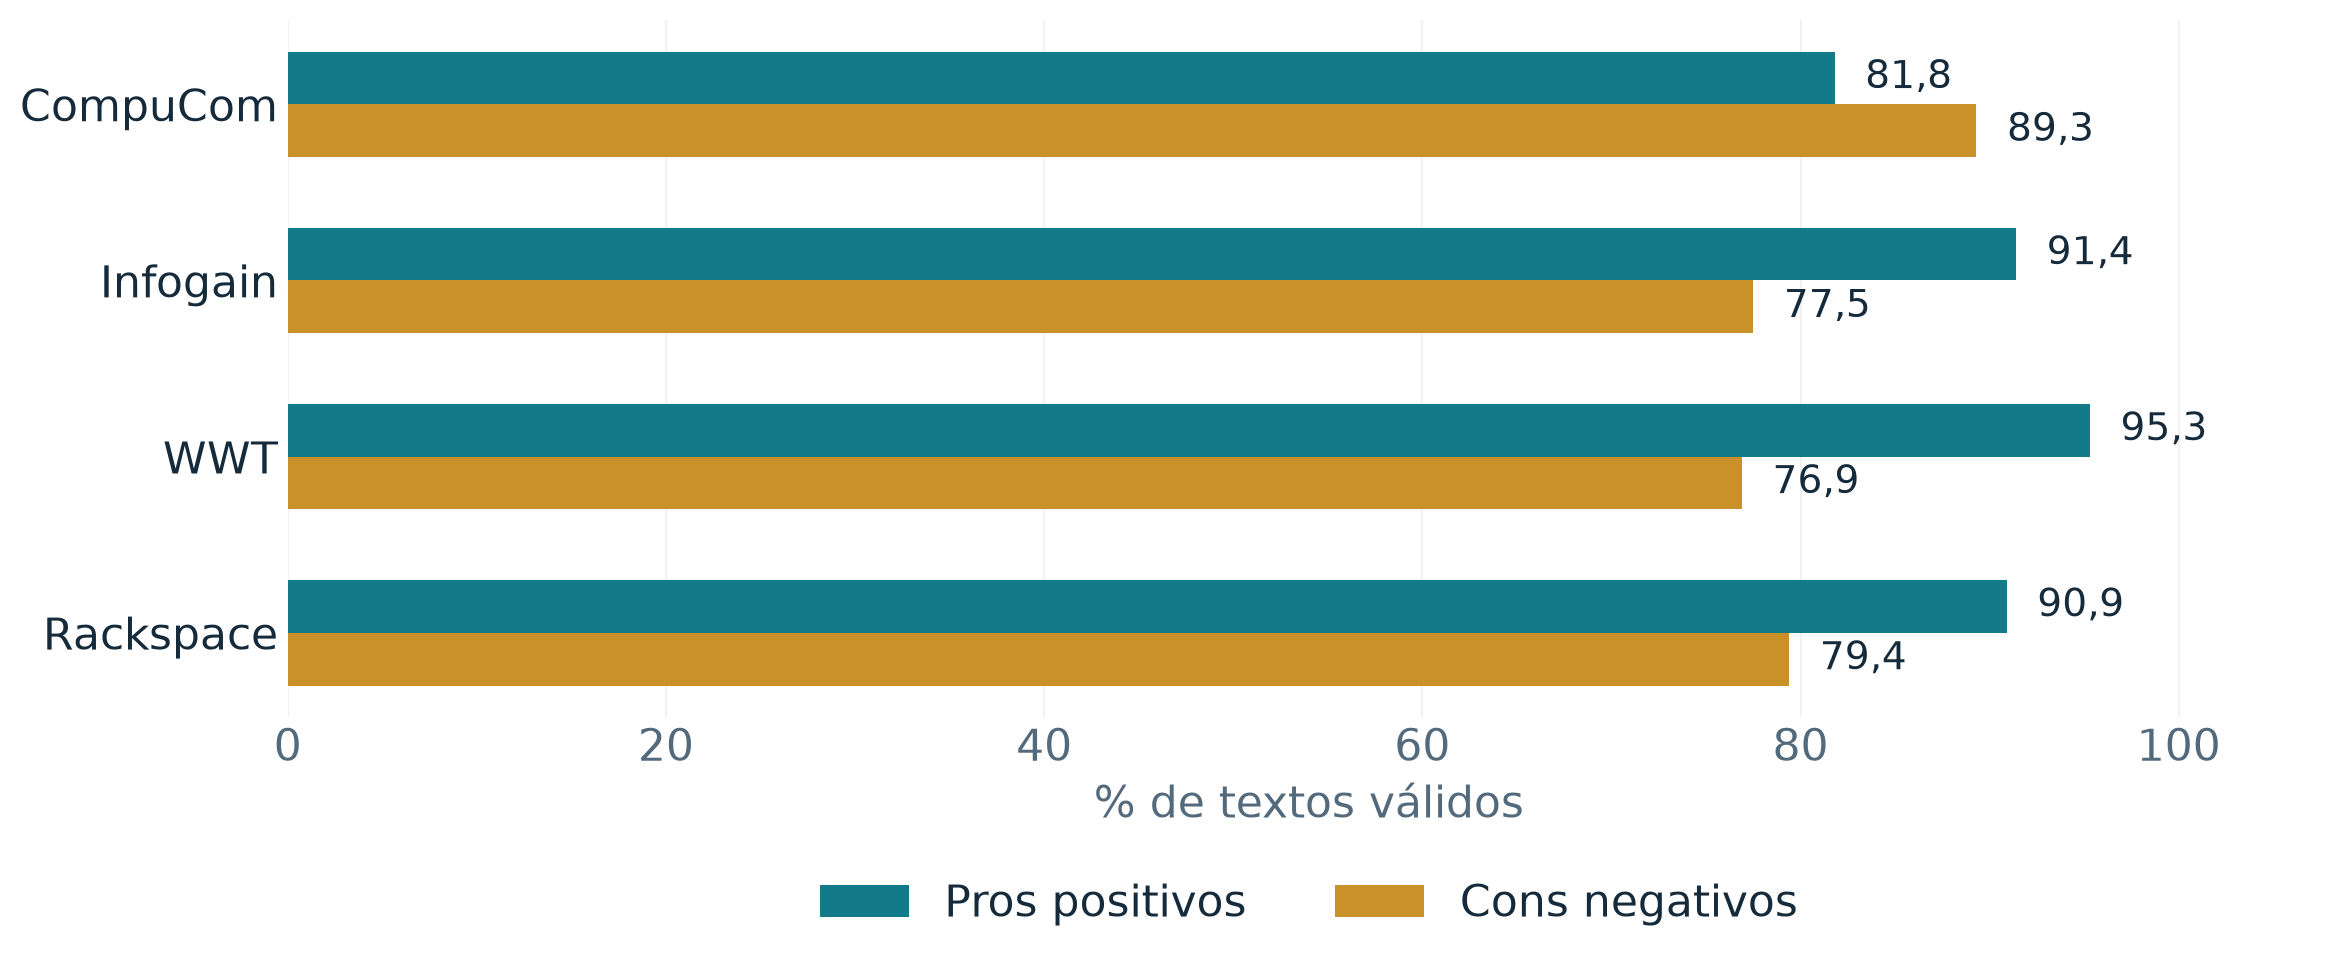

In [10]:
# Control de polaridad de pros y cons
firms, target, peers = FIRMS, TARGET, PEERS
labels = [NAMES[x] for x in firms]
summary = resumen
y = np.arange(len(firms))
sent = resumen_sentimiento
fig, ax = plt.subplots(figsize=(12, 5.2))
pairbars(ax, sent.loc[firms, 'pct_pros_positivos'], sent.loc[firms, 'pct_cons_negativos'], labels, 108, '', '% de textos válidos', 1, (TEAL, GOLD), ('Pros positivos', 'Cons negativos'))
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, -0.18), frameon=False)
fig.tight_layout()
guardar_grafica(fig, '04_control_sentimiento')


### Lectura cualitativa de las discordancias
La revisión de los 16 ejemplos distingue:
- **Ausencia de aspectos:** los pros 139/245 de CompuCom dicen que no hay nada positivo; su etiqueta negativa es razonable. Los cons 676 (CompuCom), 1749 (Infogain) y 2093 (Rackspace) no identifican quejas; su etiqueta positiva es razonable.
- **Ironía o mezcla:** el pro 2447 de Rackspace critica que se premie aparentar trabajo. El pro 1890 de Infogain mezcla flexibilidad y críticas sobre no tener proyecto. El cons 3925 de WWT combina elogios y dificultades de liderazgo.
- **Errores o ambigüedad:** el pro 3569 de WWT describe oportunidades pero recibe negativo; el 1014 de Infogain enumera reconocimiento y celebraciones con errores de escritura. El cons 103 de CompuCom critica sueldo/trato y el 2074 de Rackspace critica micromanagement, pero reciben positivo.

La confianza no es probabilidad de acierto calibrada. Los topics usan todos los textos válidos, sin filtrar por sentimiento, para conservar quejas mal clasificadas.

## 3. Topic modeling 
Se entrena **un BERTopic conjunto para las cuatro empresas en pros y otro independiente en cons**. Los IDs son independientes, pero comparten taxonomía de negocio.

| Decisión | Configuración | Justificación para RR. HH. |
|---|---|---|
| Embeddings | all-MiniLM-L6-v2; revisión fijada | Agrupa expresiones equivalentes; acota coste para 4.000 textos/corpus. |
| Representación | Stopwords inglesas, unigramas/bigramas, min_df=5 | Facilita conceptos como work life y job security; reduce ruido escaso, con riesgo de ocultar asuntos minoritarios. |
| UMAP | 15 vecinos, 5 dimensiones, min_dist=0, coseno; semilla 42 | Explora vecindades semánticas sin imponer categorías de RR. HH.; no es óptimo demostrado. |
| HDBSCAN | Pros: eom, min_samples=30. Cons: leaf, min_samples=10. Ambos min_cluster_size=30 y euclídea | 30 casos son el 0,75 % del corpus; evita priorizar frases aisladas. En cons, leaf separa grupos más finos y menor min_samples reduce exigencia de densidad. |
| Outliers | Conservar -1 y el denominador completo | Hace visible cobertura y evita inflar categorías. No equivale a neutralidad. |
| Etiquetas | Keywords, ejemplos y taxonomía común | Traduce grupos a asuntos contrastables por RR. HH.; las decisiones mixtas se documentan y se prueban alternativas. |

**Diagnóstico del ajuste:** cons con eom/min_samples=30 produjo seis topics, con 3.033 de 4.000 textos (75,83 %) en uno genérico. Se cambió a leaf/min_samples=10 para obtener grupos revisables. El criterio fue granularidad semántica, sin optimizar el ranking empresarial. Se informa cobertura; no se demuestra optimalidad global ni se ignoran las minorías.

In [11]:
def preparar_textos_topic(columna):
    documentos = df.loc[df[columna].ne(""),["firm","situacion"]].copy()
    documentos["review_id"] = documentos.index
    documentos["texto"] = df.loc[documentos.index,columna]
    return documentos.reset_index(drop=True)
modelo_embeddings = None
if REENTRENAR_MODELOS:
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer
    from sklearn.feature_extraction.text import CountVectorizer
    from umap import UMAP
    from hdbscan import HDBSCAN
    modelo_embeddings = SentenceTransformer(MODELO_EMBEDDINGS,revision=REVISION_EMBEDDINGS)
def obtener_topics(columna):
    documentos = preparar_textos_topic(columna)
    modelo = None
    if REENTRENAR_MODELOS:
        configuracion = CONFIGURACION_TOPICS[columna]
        modelo = BERTopic(embedding_model=modelo_embeddings,
            vectorizer_model=CountVectorizer(stop_words="english",ngram_range=(1,2),min_df=5),
            umap_model=UMAP(**CONFIGURACION_TOPICS["umap"]),
            hdbscan_model=HDBSCAN(**configuracion,metric="euclidean",prediction_data=True),
            min_topic_size=30,calculate_probabilities=False,verbose=True)
        topics,_ = modelo.fit_transform(documentos["texto"].tolist())
        informacion = modelo.get_topic_info()[["Topic","Count","Representation"]].copy()
        informacion["palabras_clave"] = informacion["Representation"].map(lambda p:", ".join(p[:10]))
    else:
        guardado = resultados_guardados["topics"][columna]
        if guardado["review_id"] != documentos["review_id"].tolist(): raise ValueError("IDs de topics inconsistentes.")
        topics = guardado["topic_id"]
        informacion = pd.DataFrame(guardado["informacion"])
    if len(topics)!=len(documentos): raise ValueError("Asignaciones incompletas.")
    documentos["topic_id"]=topics
    observados = documentos.groupby("topic_id").size().sort_index()
    esperados = informacion.set_index("Topic")["Count"].sort_index()
    if not observados.equals(esperados): raise ValueError("Recuentos de topics inconsistentes.")
    print(f"{columna}: {len(documentos)} textos, {informacion['Topic'].ne(-1).sum()} topics y {documentos['topic_id'].eq(-1).sum()} outliers.")
    display(informacion[["Topic","Count","palabras_clave"]])
    ejemplos=[]
    for topic_id,grupo in documentos.groupby("topic_id"):
        for firma,g in grupo.groupby("firm"):
            for fila in g.sample(n=min(2,len(g)),random_state=SEED).itertuples():
                ejemplos.append({"topic_id":topic_id,"firm":firma,"review_id":fila.review_id,"texto":fila.texto})
    ejemplos=pd.DataFrame(ejemplos)
    with pd.option_context("display.max_colwidth",400,"display.max_rows",12): display(ejemplos)
    return modelo,documentos,informacion,ejemplos
modelo_pros,asignaciones_pros,info_pros,ejemplos_pros=obtener_topics("pros")
modelo_cons,asignaciones_cons,info_cons,ejemplos_cons=obtener_topics("cons")

pros: 4000 textos, 28 topics y 1112 outliers.


,Topic,Count,palabras_clave
0,-1,1112,"good, great, work, company, culture, managemen..."
1,0,354,"benefits, pay, insurance, good, health, good b..."
2,1,195,"food, good food, food good, good, lunch, train..."
3,2,190,"company, company work, good company, great com..."
4,3,174,"place, place work, great place, good place, wo..."
5,4,173,"wwt, employees, leadership, team, people, comp..."
6,5,161,"balance, life balance, work life, life, balanc..."
7,6,154,"cloud, support, day, people, lot, work, best, ..."
8,7,145,"technologies, learn, learning, exposure, new, ..."
9,8,114,"flexible, hours, schedule, flexibility, flexib..."


,topic_id,firm,review_id,texto
0,-1,CompuCom,959,"Available overtime, nice break room"
1,-1,CompuCom,895,Great company to get started in IT People are great
2,-1,Infogain,1124,good employee support and nice environment
3,-1,Infogain,1364,Nothing at all good about this.. purely service based one
4,-1,Rackspace-Technology,2117,"People, Culture, Opportunity, Support, Ability to Suceed"
...,...,...,...,...
200,27,Infogain,1937,1) understanding management 2) great culture
201,27,Rackspace-Technology,2036,Mnc Great culture Employee focused too
202,27,Rackspace-Technology,2558,"Dynamic Culture, growing company with loads of opportunity"
203,27,World-Wide-Technology,3175,"Great culture, empathetic and competent leaders, amazing benefits and health insurance, the business is always changing and growing and as long you embrace that change you will always feel challenged and like you are learning and improving"


cons: 4000 textos, 33 topics y 1745 outliers.


,Topic,Count,palabras_clave
0,-1,1745,"management, company, work, people, good, pay, ..."
1,0,133,"leadership, culture, changes, senior, teams, c..."
2,1,132,"low, pay, salary, salaries, low pay, market, c..."
3,2,113,"sales, growing, business, company, growth, foc..."
4,3,108,"management, pay, upper, poor, employees, upper..."
5,4,99,"support, company, customers, people, just, tec..."
6,5,97,"raises, raise, promotion, pay, years, increase..."
7,6,95,"changes, management, change, communication, la..."
8,7,90,"training, period, months, learning, notice, 00..."
9,8,89,"cons, company, organisation, organization, wor..."


,topic_id,firm,review_id,texto
0,-1,CompuCom,627,Uncompetitive pay and Compucom doesn't seem committed to providing competitive raises Sometimes micromanagement emails can seem incessant Sometimes workloads are quite high and expectations from management and customers are quite stressful Long commutes
1,-1,CompuCom,437,HR department has the office in shambles
2,-1,Infogain,1990,"Nothing bad at all, the compensation is not good"
3,-1,Infogain,1196,U need to followup with HR and finance team untill you start crying😀 even for small things. They never response on time.
4,-1,Rackspace-Technology,2178,Pay Company direction Sr Leadership lots of teams doing the same work and no collab
...,...,...,...,...
243,32,Infogain,1651,On board process is slow
244,32,Rackspace-Technology,2474,Sometimes are not easy to find the resource to resolve the issue.
245,32,Rackspace-Technology,2855,"Some changes in processes required, can be a little immature in some areas."
246,32,World-Wide-Technology,3007,it is an unstable production flow


### Taxonomía común y criterios de revisión
Se distingue **carrera** (promoción y progresión) de **aprendizaje** (formación y habilidades) y **proyectos/clientes** (asignación y contenido del servicio). Los períodos sin proyecto no se interpretan automáticamente como falta de formación. Las evaluaciones o appraisals centradas en subida salarial se incluyen en compensación.

Los grupos dominados por nombres de empresas o que mezclan asuntos sin uno claramente defendible quedan en **Otros/mixto**. Los textos genéricos que no identifican pros o cons quedan en **Sin aspecto concreto**; esta etiqueta no implica neutralidad. Ambos grupos y los outliers se excluyen de las prioridades.

Se revisaron keywords y ejemplos, incluyendo CompuCom cuando tiene asignaciones. La tabla de auditoría conserva cada ID, categoría y criterio. Algunos topics tienen predominio de un asunto pero incluyen otros: se documentan y se comprueba el efecto de una etiqueta alternativa. No se fuerza una interpretación única en los grupos claramente heterogéneos.

**Cons topic 7:** la revisión de sus 90 textos muestra formación junto a cláusulas de permanencia, preaviso, vacaciones y gestión. Se conserva en Otros/mixto; se prueban aprendizaje y políticas como alternativas. Así no se convierten obligaciones contractuales en quejas de capacitación.


In [12]:
# Asignaciones revisadas para esta muestra y este ajuste; los IDs no son
# transferibles a otro entrenamiento sin comprobar su firma semántica.
CATEGORIAS_NEGOCIO = [
    "Compensación y beneficios", "Conciliación y carga de trabajo",
    "Carrera y desarrollo", "Management y liderazgo", "Cultura y ambiente",
    "Instalaciones y servicios", "Aprendizaje y formación",
    "Proyectos y clientes", "Procesos y políticas internas",
    "Ubicación y movilidad", "Estabilidad laboral",
    "Sin aspecto concreto", "Otros/mixto", "Sin tema asignado (outlier)",
]
NO_ACCIONABLES = ["Sin aspecto concreto", "Otros/mixto", "Sin tema asignado (outlier)"]
CATEGORIAS_ACCIONABLES = [c for c in CATEGORIAS_NEGOCIO if c not in NO_ACCIONABLES]

CATEGORIAS_PROS = {
    -1: "Sin tema asignado (outlier)",
    0: "Compensación y beneficios", 1: "Instalaciones y servicios",
    2: "Sin aspecto concreto", 3: "Sin aspecto concreto", 4: "Otros/mixto",
    5: "Conciliación y carga de trabajo", 6: "Otros/mixto",
    7: "Aprendizaje y formación", 8: "Conciliación y carga de trabajo",
    9: "Conciliación y carga de trabajo", 10: "Cultura y ambiente",
    11: "Cultura y ambiente", 12: "Management y liderazgo",
    13: "Cultura y ambiente", 14: "Cultura y ambiente",
    15: "Compensación y beneficios", 16: "Cultura y ambiente",
    17: "Conciliación y carga de trabajo", 18: "Sin aspecto concreto",
    19: "Carrera y desarrollo", 20: "Sin aspecto concreto", 21: "Otros/mixto",
    22: "Otros/mixto", 23: "Procesos y políticas internas",
    24: "Procesos y políticas internas", 25: "Management y liderazgo",
    26: "Cultura y ambiente", 27: "Cultura y ambiente",
}
CATEGORIAS_CONS = {
    -1: "Sin tema asignado (outlier)",
    0: "Management y liderazgo", 1: "Compensación y beneficios", 2: "Otros/mixto",
    3: "Management y liderazgo", 4: "Otros/mixto", 5: "Compensación y beneficios",
    6: "Management y liderazgo", 7: "Otros/mixto",
    8: "Sin aspecto concreto", 9: "Sin aspecto concreto", 10: "Otros/mixto",
    11: "Sin aspecto concreto", 12: "Proyectos y clientes", 13: "Sin aspecto concreto",
    14: "Sin aspecto concreto", 15: "Compensación y beneficios", 16: "Sin aspecto concreto",
    17: "Carrera y desarrollo", 18: "Otros/mixto", 19: "Sin aspecto concreto",
    20: "Compensación y beneficios", 21: "Conciliación y carga de trabajo",
    22: "Conciliación y carga de trabajo", 23: "Sin aspecto concreto",
    24: "Conciliación y carga de trabajo", 25: "Otros/mixto",
    26: "Estabilidad laboral", 27: "Conciliación y carga de trabajo",
    28: "Compensación y beneficios", 29: "Estabilidad laboral",
    30: "Sin aspecto concreto", 31: "Management y liderazgo", 32: "Procesos y políticas internas",
}
CRITERIOS_ESPECIFICOS = {
    ("pros", 1): "Predomina comida/servicios; también formación y balance. Sensibilidad: conciliación.",
    ("pros", 4): "WWT: cultura, beneficios, desarrollo y liderazgo mezclados; no asignar por nombre de firma.",
    ("pros", 6): "Rackspace: cloud, formación, cultura y condiciones mezcladas; sin predominio seguro.",
    ("pros", 11): "Equipo y compañeros; algunas menciones a managers. Sensibilidad: liderazgo.",
    ("pros", 12): "Liderazgo y apoyo de responsables; valores/cultura también presentes.",
    ("pros", 21): "Infogain aparece con cultura, formación y condiciones; topic dominado por marca.",
    ("pros", 22): "CompuCom aparece con movilidad, remoto y compensación; topic dominado por marca.",
    ("pros", 23): "Accesibilidad de HR y sistemas; comentarios también elogian liderazgo.",
    ("pros", 24): "Proceso de incorporación y onboarding; formación como componente secundario.",
    ("pros", 26): "Cuidado del empleado y pertenencia; sensibilidad: liderazgo.",
    ("cons", 0): "Cambios y dirección de senior leadership; contiene cultura y comunicación.",
    ("cons", 2): "Estrategia comercial, crecimiento organizativo, integración y estabilidad; heterogéneo.",
    ("cons", 3): "Predomina mala gestión; mezcla pay/compensación. Sensibilidad: compensación.",
    ("cons", 4): "Textos largos Rackspace con outsourcing, cultura, carrera y liderazgo; mezcla.",
    ("cons", 7): "Los 90 textos mezclan capacitación, permanencia/preaviso, vacaciones y gestión; no atribuir todo a formación. Sensibilidad: aprendizaje y políticas.",
    ("cons", 10): "WWT: despidos, servicios, políticas y liderazgo; grupo heterogéneo.",
    ("cons", 12): "Asignación, clientes, alcance y progreso de proyectos; no confundir con formación.",
    ("cons", 15): "Hikes y salario predominan; permisos y notice period también aparecen.",
    ("cons", 18): "CompuCom/Office Depot, salarios y PTO mezclados con otros asuntos.",
    ("cons", 20): "Appraisal y subidas salariales; sensibilidad: carrera y desarrollo.",
    ("cons", 25): "Mezcla crecimiento de empresa con desarrollo individual; no equiparar ambos.",
    ("cons", 26): "Outsourcing y sustitución de puestos; incluye dirección/costes. Sensibilidad: procesos.",
}
# Se inserta una firma de tres keywords para cada ID del entrenamiento auditado.
FIRMAS_ESPERADAS = {'pros': {0: ['benefits', 'pay', 'insurance'], 1: ['food', 'good food', 'food good'], 2: ['company', 'company work', 'good company'], 3: ['place', 'place work', 'great place'], 4: ['wwt', 'employees', 'leadership'], 5: ['balance', 'life balance', 'work life'], 6: ['cloud', 'support', 'day'], 7: ['technologies', 'learn', 'learning'], 8: ['flexible', 'hours', 'schedule'], 9: ['home', 'work home', 'work'], 10: ['environment', 'work environment', 'working environment'], 11: ['team', 'great team', 'good team'], 12: ['leadership', 'values', 'core values'], 13: ['culture', 'great culture', 'culture great'], 14: ['people', 'people work', 'great people'], 15: ['pto', '401k', 'benefits'], 16: ['work culture', 'culture', 'culture good'], 17: ['remote', 'remote work', 'work'], 18: ['pros', 'pro', 'company'], 19: ['growth', 'opportunities', 'growth opportunities'], 20: ['think', 'mention', 'speak'], 21: ['infogain', 'provides', 'working'], 22: ['compucom', 'depot', 'office depot'], 23: ['hr', 'joining', 'employee'], 24: ['onboarding', 'smooth', 'process'], 25: ['management', 'management good', 'good management'], 26: ['employees', 'cares', 'cares employees'], 27: ['culture', 'company culture', 'company']}, 'cons': {0: ['leadership', 'culture', 'changes'], 1: ['low', 'pay', 'salary'], 2: ['sales', 'growing', 'business'], 3: ['management', 'pay', 'upper'], 4: ['support', 'company', 'customers'], 5: ['raises', 'raise', 'promotion'], 6: ['changes', 'management', 'change'], 7: ['training', 'period', 'months'], 8: ['cons', 'company', 'organisation'], 9: ['think', 'moment', 'point'], 10: ['wwt', 'services', 'team'], 11: ['cons', 'think', 'say'], 12: ['project', 'projects', 'client'], 13: ['place work', 'place', 'best place'], 14: ['cons', 'cons till', 'don cons'], 15: ['hike', 'salary', 'leaves'], 16: ['far', 'good', 'till'], 17: ['career', 'career growth', 'opportunities'], 18: ['compucom', 'pto', 'office'], 19: ['cons', 'cons till', 'cons far'], 20: ['appraisal', 'good', 'project'], 21: ['balance', 'work life', 'life balance'], 22: ['hours', 'working hours', 'long'], 23: ['till', 'didn', 'far'], 24: ['shift', 'shifts', 'allowances'], 25: ['growth', 'fast', 'growth opportunities'], 26: ['offshoring', 'outsourcing', 'india'], 27: ['pressure', 'work pressure', 'workload'], 28: ['benefits', 'expensive', 'low'], 29: ['layoffs', 'year', 'lay'], 30: ['say', 'mention', 'mentioned'], 31: ['micro', 'management', 'managed'], 32: ['processes', 'tools', 'process']}}

def validar_taxonomia(informacion, categorias, corpus):
    if set(informacion["Topic"]) != set(categorias):
        raise ValueError(f"Cambiaron IDs de {corpus}; revisar categorías manuales.")
    observadas = informacion.set_index("Topic")["Representation"]
    cambios = [
        topic_id for topic_id, firma in FIRMAS_ESPERADAS[corpus].items()
        if list(observadas.loc[topic_id])[:3] != firma
    ]
    if cambios:
        raise ValueError(f"Cambiaron keywords en {corpus}, topics {cambios}; revisar etiquetas antes de comparar.")

def resumir_categorias(asignaciones, informacion, categorias, corpus):
    validar_taxonomia(informacion, categorias, corpus)
    asignaciones = asignaciones.copy()
    asignaciones["categoria"] = asignaciones["topic_id"].map(categorias)
    assert asignaciones["categoria"].notna().all()
    auditoria = informacion[["Topic", "Count", "palabras_clave"]].copy()
    auditoria["categoria"] = auditoria["Topic"].map(categorias)
    auditoria["criterio"] = [
        CRITERIOS_ESPECIFICOS.get((corpus, topic_id),
            "Sin agrupación densa; mantener cobertura visible." if topic_id == -1
            else "Sin asunto específico interpretable." if categorias[topic_id] in NO_ACCIONABLES
            else "Keywords y ejemplos coherentes con la categoría dominante.")
        for topic_id in auditoria["Topic"]
    ]
    with pd.option_context("display.max_rows", None, "display.max_colwidth", 130):
        display(auditoria)
    conteos = (
        asignaciones.groupby(["firm", "categoria"]).size().unstack(fill_value=0)
        .reindex(index=FIRMS, columns=CATEGORIAS_NEGOCIO, fill_value=0)
    )
    denominadores = asignaciones.groupby("firm").size().reindex(FIRMS, fill_value=0)
    porcentajes = conteos.div(denominadores.replace(0, np.nan), axis=0).mul(100)
    assert np.allclose(porcentajes.loc[denominadores.gt(0)].sum(axis=1), 100)
    display(conteos)
    display(porcentajes.round(2))
    return asignaciones, auditoria, conteos, porcentajes

asignaciones_pros, auditoria_pros, conteos_pros, porcentajes_pros = resumir_categorias(
    asignaciones_pros, info_pros, CATEGORIAS_PROS, "pros")
asignaciones_cons, auditoria_cons, conteos_cons, porcentajes_cons = resumir_categorias(
    asignaciones_cons, info_cons, CATEGORIAS_CONS, "cons")

,Topic,Count,palabras_clave,categoria,criterio
0,-1,1112,"good, great, work, company, culture, management, people, environment, friendly, learning",Sin tema asignado (outlier),Sin agrupación densa; mantener cobertura visible.
1,0,354,"benefits, pay, insurance, good, health, good benefits, salary, benefits good, great benefits, great",Compensación y beneficios,Keywords y ejemplos coherentes con la categoría dominante.
2,1,195,"food, good food, food good, good, lunch, training, work life, life balance, environment, balance",Instalaciones y servicios,Predomina comida/servicios; también formación y balance. Sensibilidad: conciliación.
3,2,190,"company, company work, good company, great company, company good, good, great, work good, work, company great",Sin aspecto concreto,Sin asunto específico interpretable.
4,3,174,"place, place work, great place, good place, work, great, work great, place learn, learn, work good",Sin aspecto concreto,Sin asunto específico interpretable.
5,4,173,"wwt, employees, leadership, team, people, company, values, truly, great, culture",Otros/mixto,"WWT: cultura, beneficios, desarrollo y liderazgo mezclados; no asignar por nombre de firma."
6,5,161,"balance, life balance, work life, life, balance good, work, good work, balance work, good, learning",Conciliación y carga de trabajo,Keywords y ejemplos coherentes con la categoría dominante.
7,6,154,"cloud, support, day, people, lot, work, best, customers, culture, career",Otros/mixto,"Rackspace: cloud, formación, cultura y condiciones mezcladas; sin predominio seguro."
8,7,145,"technologies, learn, learning, exposure, new, technology, experience, lot, good, latest",Aprendizaje y formación,Keywords y ejemplos coherentes con la categoría dominante.
9,8,114,"flexible, hours, schedule, flexibility, flexible working, working hours, flexible work, timings, working, flexible timings",Conciliación y carga de trabajo,Keywords y ejemplos coherentes con la categoría dominante.


categoria,Compensación y beneficios,Conciliación y carga de trabajo,Carrera y desarrollo,Management y liderazgo,Cultura y ambiente,Instalaciones y servicios,Aprendizaje y formación,Proyectos y clientes,Procesos y políticas internas,Ubicación y movilidad,Estabilidad laboral,Sin aspecto concreto,Otros/mixto,Sin tema asignado (outlier)
firm,,,,,,,,,,,,,,
CompuCom,117,146,16,19,108,14,65,0,7,0,0,167,42,299
Infogain,25,127,12,21,115,172,43,0,46,0,0,111,48,280
World-Wide-Technology,190,58,6,76,139,5,12,0,4,0,0,81,173,256
Rackspace-Technology,102,119,15,15,162,4,25,0,15,0,0,114,152,277


categoria,Compensación y beneficios,Conciliación y carga de trabajo,Carrera y desarrollo,Management y liderazgo,Cultura y ambiente,Instalaciones y servicios,Aprendizaje y formación,Proyectos y clientes,Procesos y políticas internas,Ubicación y movilidad,Estabilidad laboral,Sin aspecto concreto,Otros/mixto,Sin tema asignado (outlier)
firm,,,,,,,,,,,,,,
CompuCom,11.7,14.6,1.6,1.9,10.8,1.4,6.5,0.0,0.7,0.0,0.0,16.7,4.2,29.9
Infogain,2.5,12.7,1.2,2.1,11.5,17.2,4.3,0.0,4.6,0.0,0.0,11.1,4.8,28.0
World-Wide-Technology,19.0,5.8,0.6,7.6,13.9,0.5,1.2,0.0,0.4,0.0,0.0,8.1,17.3,25.6
Rackspace-Technology,10.2,11.9,1.5,1.5,16.2,0.4,2.5,0.0,1.5,0.0,0.0,11.4,15.2,27.7


,Topic,Count,palabras_clave,categoria,criterio
0,-1,1745,"management, company, work, people, good, pay, employees, team, don, hr",Sin tema asignado (outlier),Sin agrupación densa; mantener cobertura visible.
1,0,133,"leadership, culture, changes, senior, teams, change, lack, new, people, employees",Management y liderazgo,Cambios y dirección de senior leadership; contiene cultura y comunicación.
2,1,132,"low, pay, salary, salaries, low pay, market, competitive, lower, average, compared",Compensación y beneficios,Keywords y ejemplos coherentes con la categoría dominante.
3,2,113,"sales, growing, business, company, growth, focus, chain, pains, technology, stability",Otros/mixto,"Estrategia comercial, crecimiento organizativo, integración y estabilidad; heterogéneo."
4,3,108,"management, pay, upper, poor, employees, upper management, low, low pay, bad, poor management",Management y liderazgo,Predomina mala gestión; mezcla pay/compensación. Sensibilidad: compensación.
5,4,99,"support, company, customers, people, just, technical, like, gone, year, leadership",Otros/mixto,"Textos largos Rackspace con outsourcing, cultura, carrera y liderazgo; mezcla."
6,5,97,"raises, raise, promotion, pay, years, increases, raise years, promotions, hard, increase",Compensación y beneficios,Keywords y ejemplos coherentes con la categoría dominante.
7,6,95,"changes, management, change, communication, lack communication, lack, frequently, departments, needs, listen",Management y liderazgo,Keywords y ejemplos coherentes con la categoría dominante.
8,7,90,"training, period, months, learning, notice, 000, fresher, salary, projects, long",Otros/mixto,"Los 90 textos mezclan capacitación, permanencia/preaviso, vacaciones y gestión; no atribuir todo a formación. Sensibilidad: ap..."
9,8,89,"cons, company, organisation, organization, working, really, great place, cons far, don, great",Sin aspecto concreto,Sin asunto específico interpretable.


categoria,Compensación y beneficios,Conciliación y carga de trabajo,Carrera y desarrollo,Management y liderazgo,Cultura y ambiente,Instalaciones y servicios,Aprendizaje y formación,Proyectos y clientes,Procesos y políticas internas,Ubicación y movilidad,Estabilidad laboral,Sin aspecto concreto,Otros/mixto,Sin tema asignado (outlier)
firm,,,,,,,,,,,,,,
CompuCom,161,56,22,117,0,0,0,11,6,0,16,74,95,442
Infogain,117,46,13,35,0,0,0,54,3,0,0,231,75,426
World-Wide-Technology,50,37,9,93,0,0,0,8,7,0,0,149,173,474
Rackspace-Technology,49,42,12,121,0,0,0,11,14,0,58,147,143,403


categoria,Compensación y beneficios,Conciliación y carga de trabajo,Carrera y desarrollo,Management y liderazgo,Cultura y ambiente,Instalaciones y servicios,Aprendizaje y formación,Proyectos y clientes,Procesos y políticas internas,Ubicación y movilidad,Estabilidad laboral,Sin aspecto concreto,Otros/mixto,Sin tema asignado (outlier)
firm,,,,,,,,,,,,,,
CompuCom,16.1,5.6,2.2,11.7,0.0,0.0,0.0,1.1,0.6,0.0,1.6,7.4,9.5,44.2
Infogain,11.7,4.6,1.3,3.5,0.0,0.0,0.0,5.4,0.3,0.0,0.0,23.1,7.5,42.6
World-Wide-Technology,5.0,3.7,0.9,9.3,0.0,0.0,0.0,0.8,0.7,0.0,0.0,14.9,17.3,47.4
Rackspace-Technology,4.9,4.2,1.2,12.1,0.0,0.0,0.0,1.1,1.4,0.0,5.8,14.7,14.3,40.3


### Cobertura y revisión estratificada de outliers
Se informa cobertura por empresa/corpus y se revisan **dos outliers por firma y situación** en cada corpus, con semilla fija: 16 pros y 16 cons cuando todos los estratos tienen suficientes casos. La anotación cualitativa se refiere a esos textos, no reasigna el corpus completo.

Esta muestra diagnostica asuntos que quedan fuera y contenidos mixtos. No sirve para estimar su frecuencia poblacional: los estratos pesan igual en la selección aunque tengan tamaños distintos. La cobertura de cada empresa se mantiene en los denominadores de todos los análisis.

In [13]:
cobertura = pd.DataFrame(index=FIRMS)
for corpus, asignaciones, porcentajes in [
    ("pros", asignaciones_pros, porcentajes_pros), ("cons", asignaciones_cons, porcentajes_cons)
]:
    cobertura[f"n_{corpus}_validos"] = asignaciones.groupby("firm").size().reindex(FIRMS)
    cobertura[f"pct_{corpus}_outliers"] = porcentajes["Sin tema asignado (outlier)"]
    cobertura[f"pct_{corpus}_otros_mixtos"] = porcentajes["Otros/mixto"]
    cobertura[f"pct_{corpus}_sin_aspecto"] = porcentajes["Sin aspecto concreto"]
    cobertura[f"pct_{corpus}_accionables"] = porcentajes[CATEGORIAS_ACCIONABLES].sum(axis=1)
display(cobertura.round(2))

REVISION_OUTLIERS = {
    "pros": {
        493: "Liderazgo: expectativa de nuevo CEO", 979: "Conciliación y reembolso: mixto",
        801: "Instalaciones: open concept", 348: "Estabilidad, entorno y gestión: mixto",
        1050: "Carrera inicial y salario: mixto", 1931: "Sin elogio específico / ambiguo",
        1867: "Aprendizaje: bootcamp", 1969: "Ambiente, conciliación y aprendizaje: mixto",
        2246: "Beneficios, oficina y equipos: mixto", 2784: "Contenido del trabajo: conocimiento técnico",
        2953: "Cultura: crítica irónica a la política", 2003: "Autonomía/flexibilidad",
        3032: "Cultura, desarrollo y beneficios: mixto", 3928: "Sin aspecto concreto",
        3651: "Elogio general y salario: mixto", 3308: "Apoyo de supervisores",
    },
    "cons": {
        43: "Formación y gestión: mixto", 589: "Compensación: sueldo inferior a lo esperado",
        937: "Compensación, plazos y clientes: mixto", 983: "Compensación y carrera: mixto",
        1460: "Procesos: inversión para prestar servicio", 1123: "No identifica cons",
        1343: "Elogio general / no queja", 1544: "Compensación y carga: mixto",
        2579: "Cambio organizativo", 2018: "Dinamismo y exigencia: ambiguo",
        2546: "Liderazgo y trato a empleados", 2561: "Cultura, gestión y compensación: mixto",
        3838: "Conciliación: horas y balance", 3420: "Carrera y subida salarial: mixto",
        3899: "Carrera y compensación: mixto", 3014: "Carga, carrera y compensación: mixto",
    },
}
muestras_outliers = []
for corpus, asignaciones in [("pros", asignaciones_pros), ("cons", asignaciones_cons)]:
    grupos = asignaciones.loc[asignaciones["topic_id"].eq(-1)].groupby(["firm", "situacion"])
    for (firma, estado), grupo in grupos:
        for fila in grupo.sample(n=min(2, len(grupo)), random_state=SEED).itertuples():
            lectura = REVISION_OUTLIERS[corpus].get(fila.review_id, "Requiere nueva revisión humana")
            muestras_outliers.append({
                "corpus": corpus, "firm": firma, "situacion": estado,
                "review_id": fila.review_id, "texto": fila.texto, "lectura_manual": lectura,
            })
muestra_outliers = pd.DataFrame(muestras_outliers)
with pd.option_context("display.max_rows", None, "display.max_colwidth", 280):
    display(muestra_outliers)
mostrar(
    f"**Implicación de cobertura:** solo el **{fmt(cobertura.loc[TARGET, 'pct_cons_accionables'])} %** de los cons "
    f"de CompuCom tiene una categoría accionable y el **{fmt(cobertura.loc[TARGET, 'pct_cons_outliers'])} %** es outlier. "
    "La muestra revisada contiene quejas de sueldo, liderazgo, carrera y carga, además de ausencia de queja y textos mixtos. "
    "Por tanto, el modelo no ofrece un inventario exhaustivo. Validar los asuntos no cubiertos antes de generalizar prioridades."
)

,n_pros_validos,pct_pros_outliers,pct_pros_otros_mixtos,pct_pros_sin_aspecto,pct_pros_accionables,n_cons_validos,pct_cons_outliers,pct_cons_otros_mixtos,pct_cons_sin_aspecto,pct_cons_accionables
CompuCom,1000,29.9,4.2,16.7,49.2,1000,44.2,9.5,7.4,38.9
Infogain,1000,28.0,4.8,11.1,56.1,1000,42.6,7.5,23.1,26.8
World-Wide-Technology,1000,25.6,17.3,8.1,49.0,1000,47.4,17.3,14.9,20.4
Rackspace-Technology,1000,27.7,15.2,11.4,45.7,1000,40.3,14.3,14.7,30.7


,corpus,firm,situacion,review_id,texto,lectura_manual
0,pros,CompuCom,Actual,493,"Seemed like there was going to be a fresh start with new, enthusiastic CEO",Liderazgo: expectativa de nuevo CEO
1,pros,CompuCom,Actual,979,-WFH to maintain work life balance -Reimbursment,Conciliación y reembolso: mixto
2,pros,CompuCom,Antiguo,801,"They had the ""open Concept""",Instalaciones: open concept
3,pros,CompuCom,Antiguo,348,Job security. Good working environment. Cooperative management. Stable work environment. Standard police,"Estabilidad, entorno y gestión: mixto"
4,pros,Infogain,Actual,1050,Good Company for freshers with pretty good salary,Carrera inicial y salario: mixto
5,pros,Infogain,Actual,1931,Must focus on the work,Sin elogio específico / ambiguo
6,pros,Infogain,Antiguo,1867,Great training for freshers in bootcamp.,Aprendizaje: bootcamp
7,pros,Infogain,Antiguo,1969,1.Good work environment 2.A great work life balance. 3. Oppurtunites to learn new technologies,"Ambiente, conciliación y aprendizaje: mixto"
8,pros,Rackspace-Technology,Actual,2246,"Good benefits, Nice office, Global teams","Beneficios, oficina y equipos: mixto"
9,pros,Rackspace-Technology,Actual,2784,Product knowledge and expertise in respective vertical is extremely high.,Contenido del trabajo: conocimiento técnico


**Implicación de cobertura:** solo el **38,90 %** de los cons de CompuCom tiene una categoría accionable y el **44,20 %** es outlier. La muestra revisada contiene quejas de sueldo, liderazgo, carrera y carga, además de ausencia de queja y textos mixtos. Por tanto, el modelo no ofrece un inventario exhaustivo. Validar los asuntos no cubiertos antes de generalizar prioridades.

### Gráfica 05 · Qué parte del texto tiene un tema interpretable

**Origen:** `cobertura`, calculadas en el apartado 3. Topic modeling.

Todos los textos válidos permanecen en el denominador. La suma de categorías concretas, sin aspecto, mixtas y sin tema asignado es 100 %. Un texto sin tema asignado no implica que carezca de problemas; la revisión estratificada está en este apartado.


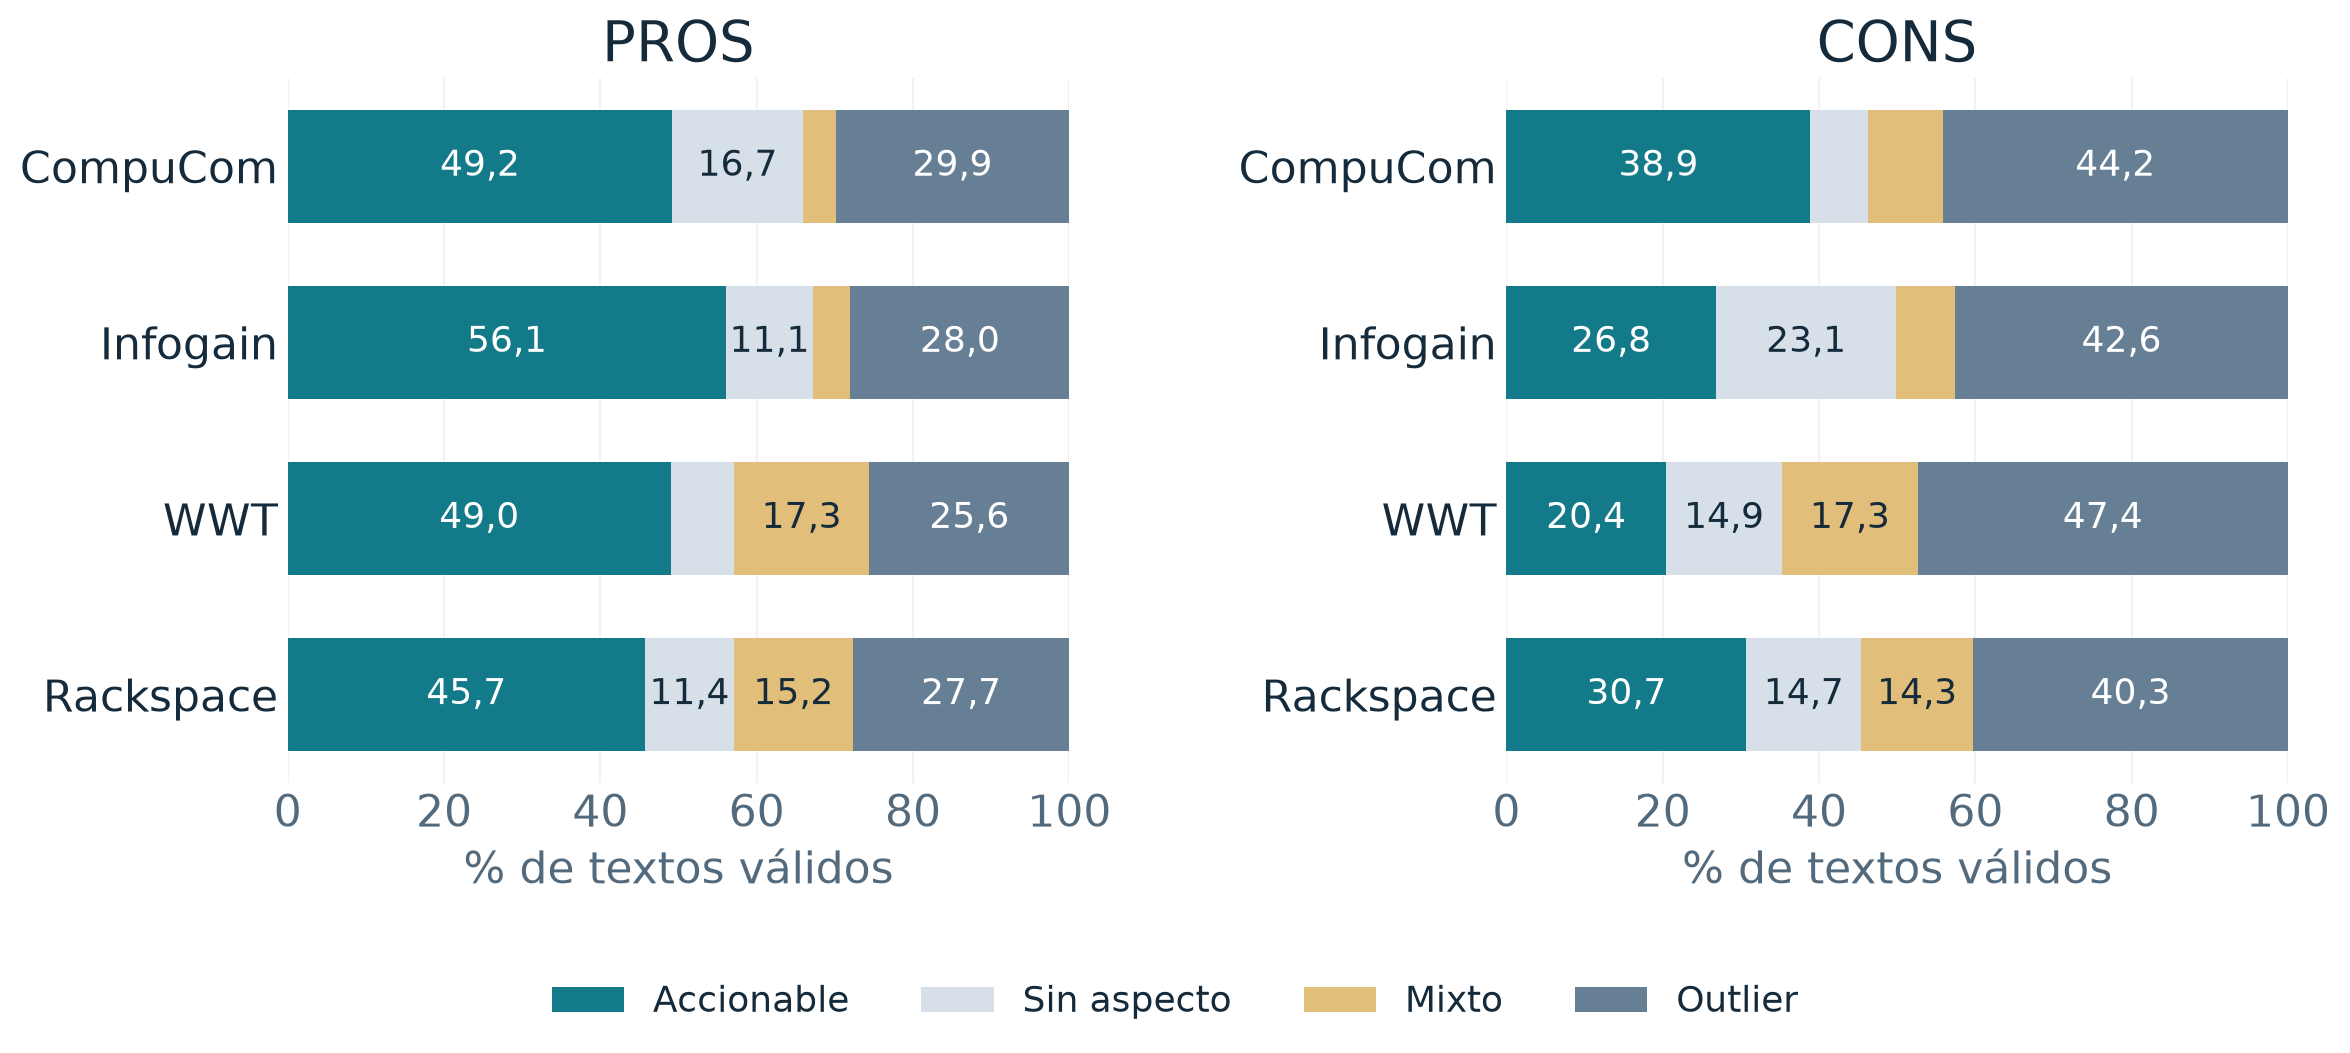

In [14]:
# Qué parte del texto tiene un tema interpretable
firms, target, peers = FIRMS, TARGET, PEERS
labels = [NAMES[x] for x in firms]
summary = resumen
y = np.arange(len(firms))
coverage = cobertura
fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
for corpus, ax in zip(['pros', 'cons'], axes):
    left = np.zeros(4)
    for suffix, color, name in [('accionables', TEAL, 'Accionable'), ('sin_aspecto', '#D7E0E9', 'Sin aspecto'), ('otros_mixtos', '#E1BE7A', 'Mixto'), ('outliers', '#677F94', 'Outlier')]:
        vals = coverage.loc[firms, f'pct_{corpus}_{suffix}'].to_numpy()
        ax.barh(y, vals, left=left, color=color, height=0.64, label=name)
        for i, v in enumerate(vals):
            if v >= 10:
                ax.text(left[i] + v / 2, i, f(v, 1), ha='center', va='center', fontsize=13, color='white' if suffix in ['accionables', 'outliers'] else NAVY)
        left += vals
    ax.set(yticks=y, yticklabels=labels, xlim=(0, 100), title=corpus.upper())
    ax.invert_yaxis()
    polish(ax, '% de textos válidos')
handles, names = axes[0].get_legend_handles_labels()
fig.legend(handles, names, ncol=4, loc='lower center', frameon=False, fontsize=13)
fig.tight_layout(rect=(0, 0.1, 1, 1), w_pad=3)
guardar_grafica(fig, '05_cobertura_topics')


## 4. Comparación con peers
El denominador es **todos los textos válidos de cada empresa/corpus**, incluidos outliers y categorías no accionables. Cada texto tiene un grupo dominante; las proporciones suman 100 % y son composicionales.

**Balance neto = % pros − % cons. Gap = balance de CompuCom − media aritmética de los tres peers.** Negativo significa posición relativa desfavorable; cada peer pesa igual.

Por empresa y categoría de cons se compara rating y no recomendación con el resto de sus textos válidos, incluidos outliers. «Sin opinión» permanece en el denominador de recomendación; se excluyen ausentes. Se muestran casos y cuántos peers tienen esa categoría: una media con categorías inexistentes no representa necesariamente a los tres. Las asociaciones no prueban causalidad.

In [15]:
# Las matrices anteriores usan todos los textos válidos, incluidos los outliers,
# por lo que cada porcentaje se calcula sobre el mismo tipo de denominador.
print("Porcentaje de reseñas por categoría en pros, por empresa:")
display(porcentajes_pros)
print("Porcentaje de reseñas por categoría en cons, por empresa:")
display(porcentajes_cons)

media_pros_peers = porcentajes_pros.loc[PEERS].mean(axis=0)
media_cons_peers = porcentajes_cons.loc[PEERS].mean(axis=0)
balance_por_empresa = porcentajes_pros.subtract(porcentajes_cons)
media_balance_peers = balance_por_empresa.loc[PEERS].mean(axis=0)

comparacion_peers = pd.DataFrame(index=CATEGORIAS_NEGOCIO)
comparacion_peers["pros_compucom_pct"] = porcentajes_pros.loc[TARGET]
comparacion_peers["pros_media_peers_pct"] = media_pros_peers
comparacion_peers["gap_pros_pp"] = comparacion_peers["pros_compucom_pct"] - comparacion_peers["pros_media_peers_pct"]
comparacion_peers["cons_compucom_pct"] = porcentajes_cons.loc[TARGET]
comparacion_peers["cons_media_peers_pct"] = media_cons_peers
comparacion_peers["gap_cons_pp"] = comparacion_peers["cons_compucom_pct"] - comparacion_peers["cons_media_peers_pct"]
comparacion_peers["balance_compucom_pp"] = balance_por_empresa.loc[TARGET]
comparacion_peers["balance_medio_peers_pp"] = media_balance_peers
comparacion_peers["gap_balance_pp"] = comparacion_peers["balance_compucom_pp"] - comparacion_peers["balance_medio_peers_pp"]

print("CompuCom frente a la media aritmética de los tres peers (diferencias en puntos porcentuales):")
display(comparacion_peers.round(2).sort_values("gap_balance_pp"))

# El ID de reseña permite asociar cada categoría de cons con su rating y recomendación originales.
metadatos_resenas = df[["overall_rating", "recommend"]].copy().reset_index(drop=True)
metadatos_resenas["review_id"] = df.index.to_numpy()
cons_con_metricas = asignaciones_cons[["review_id", "firm", "categoria"]].merge(
    metadatos_resenas,
    on="review_id",
    how="left",
    validate="one_to_one",
)

filas_contraste = []
for firma in FIRMS:
    resenas_firma = cons_con_metricas.loc[cons_con_metricas["firm"].eq(firma)]
    for categoria in CATEGORIAS_NEGOCIO:
        quejas_categoria = resenas_firma.loc[resenas_firma["categoria"].eq(categoria)]
        resto_resenas = resenas_firma.loc[~resenas_firma["categoria"].eq(categoria)]
        recomendaciones_categoria = quejas_categoria["recommend"].dropna()
        recomendaciones_resto = resto_resenas["recommend"].dropna()
        rating_categoria = quejas_categoria["overall_rating"].mean()
        rating_resto = resto_resenas["overall_rating"].mean()
        pct_no_categoria = recomendaciones_categoria.eq("x").mean() * 100 if len(recomendaciones_categoria) else np.nan
        pct_no_resto = recomendaciones_resto.eq("x").mean() * 100 if len(recomendaciones_resto) else np.nan
        filas_contraste.append({
            "firm": firma,
            "categoria": categoria,
            "n_cons_categoria": len(quejas_categoria),
            "n_rating_categoria": quejas_categoria["overall_rating"].count(),
            "n_recommend_categoria": len(recomendaciones_categoria),
            "rating_categoria": rating_categoria,
            "rating_resto": rating_resto,
            "delta_rating": rating_categoria - rating_resto,
            "pct_no_recomienda_categoria": pct_no_categoria,
            "pct_no_recomienda_resto": pct_no_resto,
            "delta_no_recomienda_pp": pct_no_categoria - pct_no_resto,
        })

contraste_rating_recommend = pd.DataFrame(filas_contraste)
metricas_contraste = ["delta_rating", "delta_no_recomienda_pp"]
media_deltas_peers = (
    contraste_rating_recommend.loc[contraste_rating_recommend["firm"].isin(PEERS)]
    .groupby("categoria")[metricas_contraste]
    .mean()
    .rename(columns={
        "delta_rating": "delta_rating_medio_peers",
        "delta_no_recomienda_pp": "delta_no_recomienda_medio_peers_pp",
    })
)
contraste_compucom = (
    contraste_rating_recommend.loc[contraste_rating_recommend["firm"].eq(TARGET)]
    .drop(columns="firm")
    .set_index("categoria")
    .join(media_deltas_peers)
)
contraste_compucom["n_peers_con_categoria"] = (
    contraste_rating_recommend.loc[contraste_rating_recommend["firm"].isin(PEERS)]
    .groupby("categoria")["n_cons_categoria"].agg(lambda s: s.gt(0).sum())
)
contraste_compucom["senal_coherente_con_problema"] = (
    contraste_compucom["delta_rating"].lt(0)
    & contraste_compucom["delta_no_recomienda_pp"].gt(0)
)

print("Validación por categoría: quejas de CompuCom frente al resto de sus reseñas con cons clasificable;")
print("las dos últimas métricas comparan el cambio dentro de cada peer y promedian esas diferencias.")
display(contraste_compucom.round(2).sort_values("delta_rating"))
mostrar("**Lectura para RR. HH.:** un asunto con menor rating y más no recomendación tiene una señal coherente. Resultados mixtos requieren diagnóstico. Valorar peso, gap y recuentos juntos; la celda final interpreta los hallazgos calculados.")

Porcentaje de reseñas por categoría en pros, por empresa:


categoria,Compensación y beneficios,Conciliación y carga de trabajo,Carrera y desarrollo,Management y liderazgo,Cultura y ambiente,Instalaciones y servicios,Aprendizaje y formación,Proyectos y clientes,Procesos y políticas internas,Ubicación y movilidad,Estabilidad laboral,Sin aspecto concreto,Otros/mixto,Sin tema asignado (outlier)
firm,,,,,,,,,,,,,,
CompuCom,11.7,14.6,1.6,1.9,10.8,1.4,6.5,0.0,0.7,0.0,0.0,16.7,4.2,29.9
Infogain,2.5,12.7,1.2,2.1,11.5,17.2,4.3,0.0,4.6,0.0,0.0,11.1,4.8,28.0
World-Wide-Technology,19.0,5.8,0.6,7.6,13.9,0.5,1.2,0.0,0.4,0.0,0.0,8.1,17.3,25.6
Rackspace-Technology,10.2,11.9,1.5,1.5,16.2,0.4,2.5,0.0,1.5,0.0,0.0,11.4,15.2,27.7


Porcentaje de reseñas por categoría en cons, por empresa:


categoria,Compensación y beneficios,Conciliación y carga de trabajo,Carrera y desarrollo,Management y liderazgo,Cultura y ambiente,Instalaciones y servicios,Aprendizaje y formación,Proyectos y clientes,Procesos y políticas internas,Ubicación y movilidad,Estabilidad laboral,Sin aspecto concreto,Otros/mixto,Sin tema asignado (outlier)
firm,,,,,,,,,,,,,,
CompuCom,16.1,5.6,2.2,11.7,0.0,0.0,0.0,1.1,0.6,0.0,1.6,7.4,9.5,44.2
Infogain,11.7,4.6,1.3,3.5,0.0,0.0,0.0,5.4,0.3,0.0,0.0,23.1,7.5,42.6
World-Wide-Technology,5.0,3.7,0.9,9.3,0.0,0.0,0.0,0.8,0.7,0.0,0.0,14.9,17.3,47.4
Rackspace-Technology,4.9,4.2,1.2,12.1,0.0,0.0,0.0,1.1,1.4,0.0,5.8,14.7,14.3,40.3


CompuCom frente a la media aritmética de los tres peers (diferencias en puntos porcentuales):


,pros_compucom_pct,pros_media_peers_pct,gap_pros_pp,cons_compucom_pct,cons_media_peers_pct,gap_cons_pp,balance_compucom_pp,balance_medio_peers_pp,gap_balance_pp
Compensación y beneficios,11.7,10.57,1.13,16.1,7.20,8.90,-4.4,3.37,-7.77
Management y liderazgo,1.9,3.73,-1.83,11.7,8.30,3.40,-9.8,-4.57,-5.23
Otros/mixto,4.2,12.43,-8.23,9.5,13.03,-3.53,-5.3,-0.60,-4.70
Instalaciones y servicios,1.4,6.03,-4.63,0.0,0.00,0.00,1.4,6.03,-4.63
Cultura y ambiente,10.8,13.87,-3.07,0.0,0.00,0.00,10.8,13.87,-3.07
Procesos y políticas internas,0.7,2.17,-1.47,0.6,0.80,-0.20,0.1,1.37,-1.27
Carrera y desarrollo,1.6,1.10,0.50,2.2,1.13,1.07,-0.6,-0.03,-0.57
Ubicación y movilidad,0.0,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.00
Estabilidad laboral,0.0,0.00,0.00,1.6,1.93,-0.33,-1.6,-1.93,0.33
Proyectos y clientes,0.0,0.00,0.00,1.1,2.43,-1.33,-1.1,-2.43,1.33


Validación por categoría: quejas de CompuCom frente al resto de sus reseñas con cons clasificable;
las dos últimas métricas comparan el cambio dentro de cada peer y promedian esas diferencias.


,n_cons_categoria,n_rating_categoria,n_recommend_categoria,rating_categoria,rating_resto,delta_rating,pct_no_recomienda_categoria,pct_no_recomienda_resto,delta_no_recomienda_pp,delta_rating_medio_peers,delta_no_recomienda_medio_peers_pp,n_peers_con_categoria,senal_coherente_con_problema
categoria,,,,,,,,,,,,,
Management y liderazgo,117,117,117,2.27,2.99,-0.72,64.10,38.84,25.26,-0.60,20.88,3,True
Estabilidad laboral,16,16,16,2.31,2.92,-0.60,62.50,41.46,21.04,-0.83,33.19,1,True
Sin tema asignado (outlier),442,442,442,2.74,3.04,-0.30,45.93,38.53,7.40,-0.20,2.25,3,True
Otros/mixto,95,95,95,2.85,2.91,-0.06,48.42,41.10,7.32,-0.36,14.35,3,True
Compensación y beneficios,161,161,161,2.99,2.89,0.10,36.65,42.79,-6.14,-0.02,-4.52,3,False
Carrera y desarrollo,22,22,22,3.05,2.90,0.14,22.73,42.23,-19.50,0.43,-21.78,3,False
Procesos y políticas internas,6,6,6,3.50,2.90,0.60,16.67,41.95,-25.29,0.55,-21.74,3,False
Conciliación y carga de trabajo,56,56,56,3.66,2.86,0.80,17.86,43.22,-25.36,0.17,-5.61,3,False
Proyectos y clientes,11,11,11,4.00,2.89,1.11,9.09,42.16,-33.07,0.36,-12.43,3,False


**Lectura para RR. HH.:** un asunto con menor rating y más no recomendación tiene una señal coherente. Resultados mixtos requieren diagnóstico. Valorar peso, gap y recuentos juntos; la celda final interpreta los hallazgos calculados.

### Gráfica 06 · Fortalezas y quejas por categoría de negocio

**Origen:** `comparacion_peers`, calculadas en el apartado 4. Comparación con peers.

Se muestran siete categorías de negocio en pros y cons; el resto sigue en el denominador. Porcentajes sobre todos los textos válidos del corpus de cada empresa. Media peer aritmética de Infogain, WWT y Rackspace. Un 0 % de formación en cons corresponde a la etiqueta principal, no prueba ausencia de quejas.


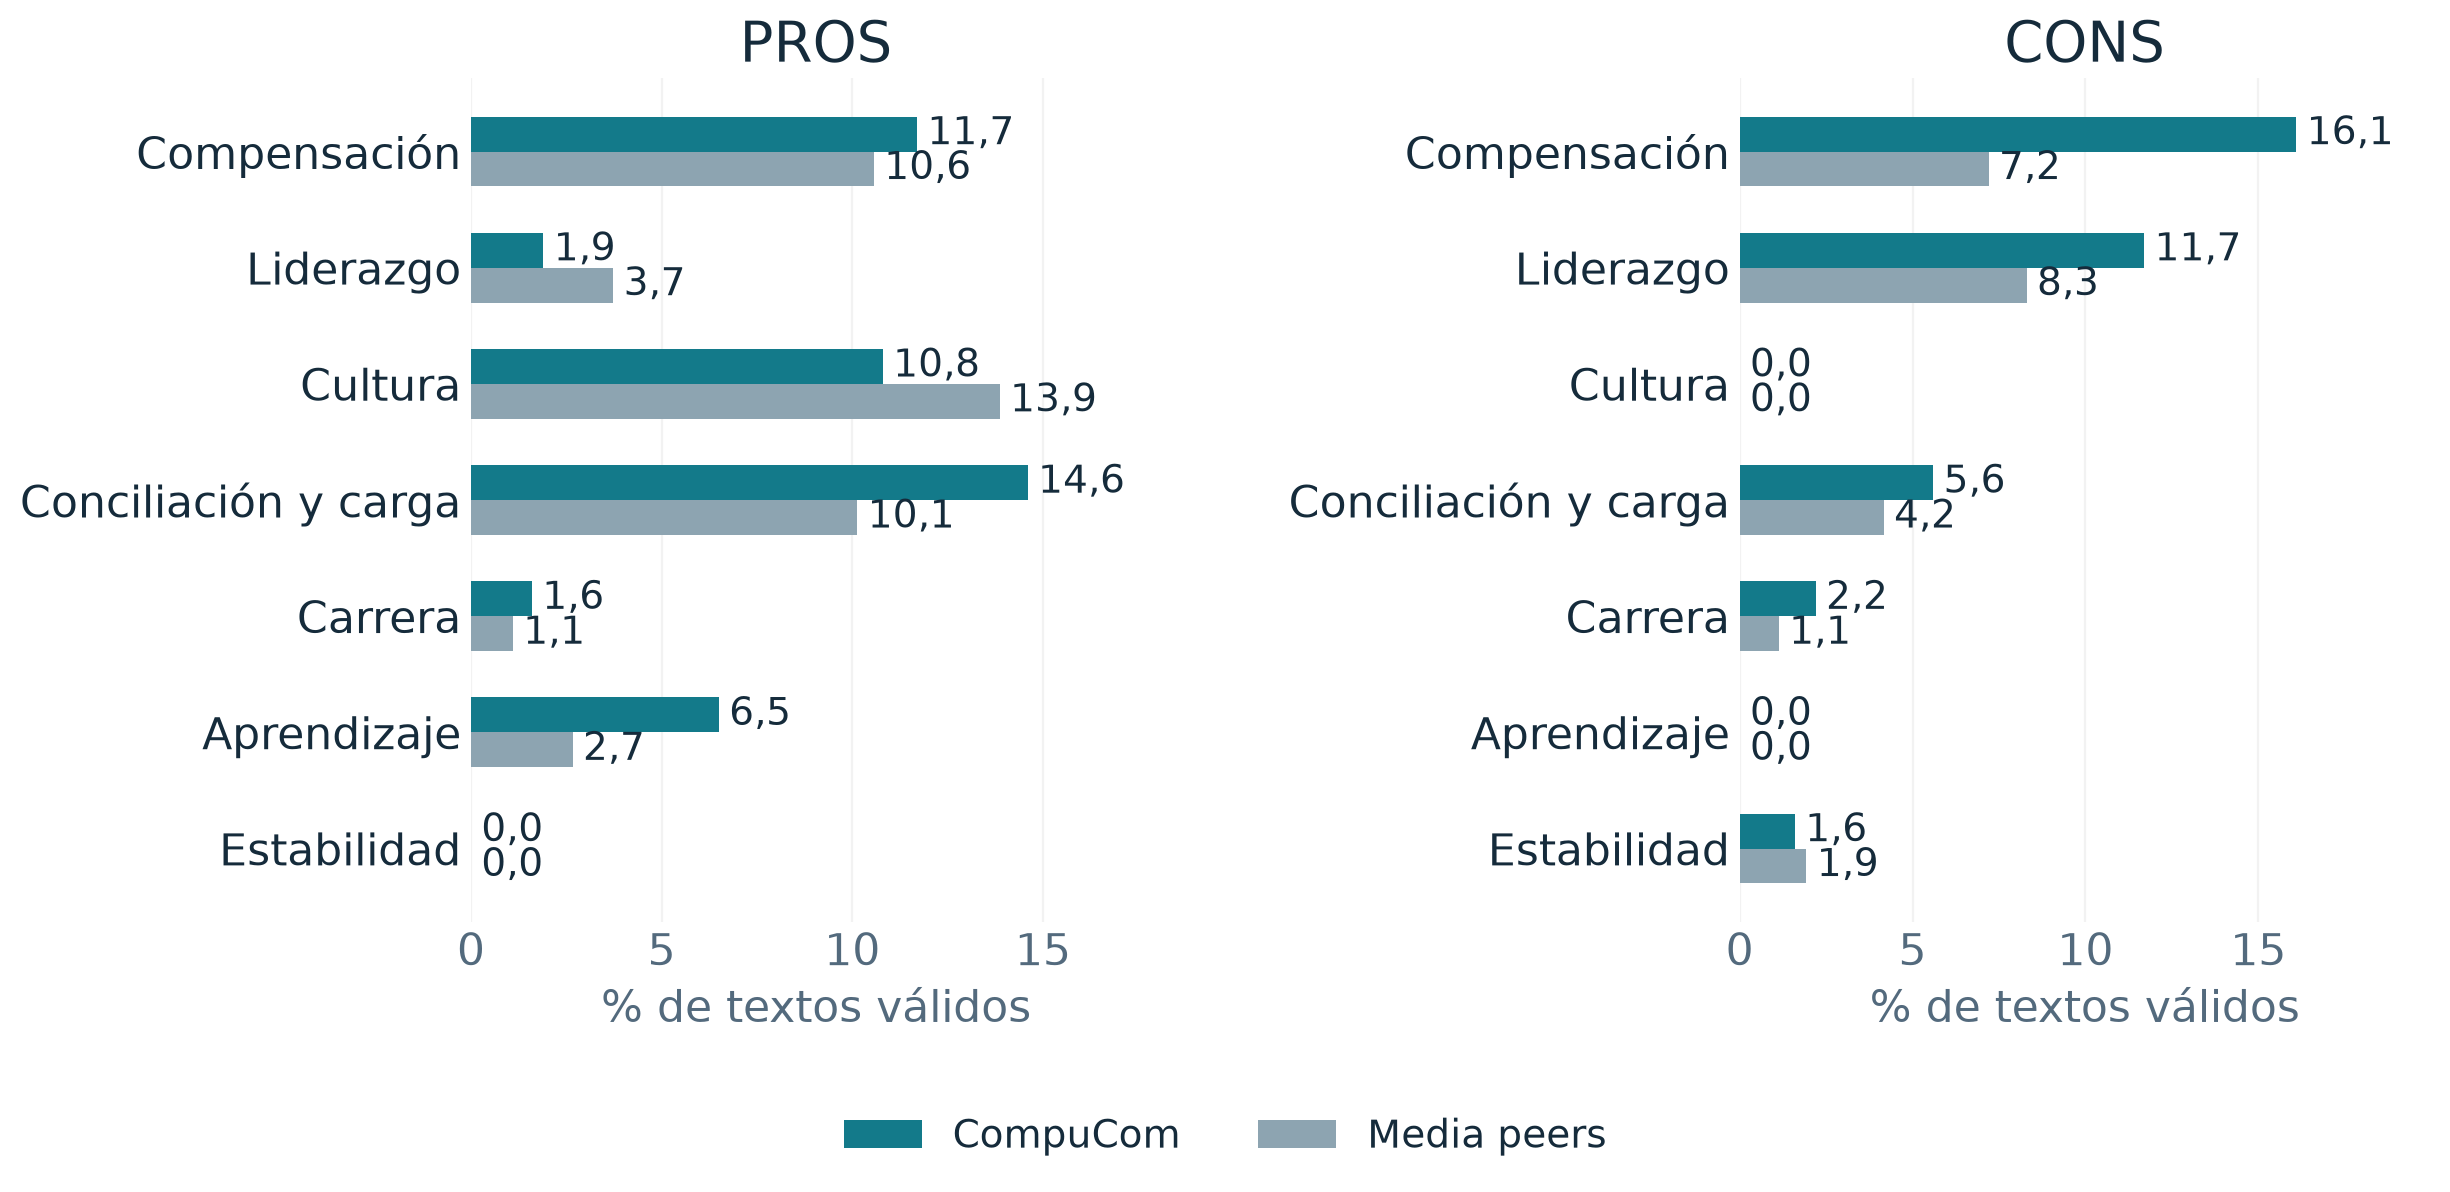

In [16]:
# Fortalezas y quejas por categoría de negocio
firms, target, peers = FIRMS, TARGET, PEERS
labels = [NAMES[x] for x in firms]
summary = resumen
y = np.arange(len(firms))
categories = ['Compensación y beneficios', 'Management y liderazgo', 'Cultura y ambiente', 'Conciliación y carga de trabajo', 'Carrera y desarrollo', 'Aprendizaje y formación', 'Estabilidad laboral']
comp = comparacion_peers
fig, axes = plt.subplots(1, 2, figsize=(12.5, 6.1))
for corpus, ax in zip(['pros', 'cons'], axes):
    a = comp.loc[categories, f'{corpus}_compucom_pct'].to_numpy()
    b = comp.loc[categories, f'{corpus}_media_peers_pct'].to_numpy()
    pairbars(ax, a, b, [SHORT[c] for c in categories], max(a.max(), b.max()) * 1.24, corpus.upper(), '% de textos válidos')
handles, names = axes[0].get_legend_handles_labels()
fig.legend(handles, names, ncol=2, loc='lower center', frameon=False, fontsize=14)
fig.tight_layout(rect=(0, 0.09, 1, 1), w_pad=3)
guardar_grafica(fig, '06_categorias_pros_cons')


### Gráfica 07 · Ventaja o desventaja frente al mercado

**Origen:** `comparacion_peers`, calculadas en el apartado 4. Comparación con peers.

Balance neto = % pros − % cons. Gap = balance de CompuCom − media aritmética del balance de los tres peers. Unidad: puntos porcentuales (pp). Negativo significa desventaja relativa dentro de esta muestra; se requiere contrastar con rating y recomendación.


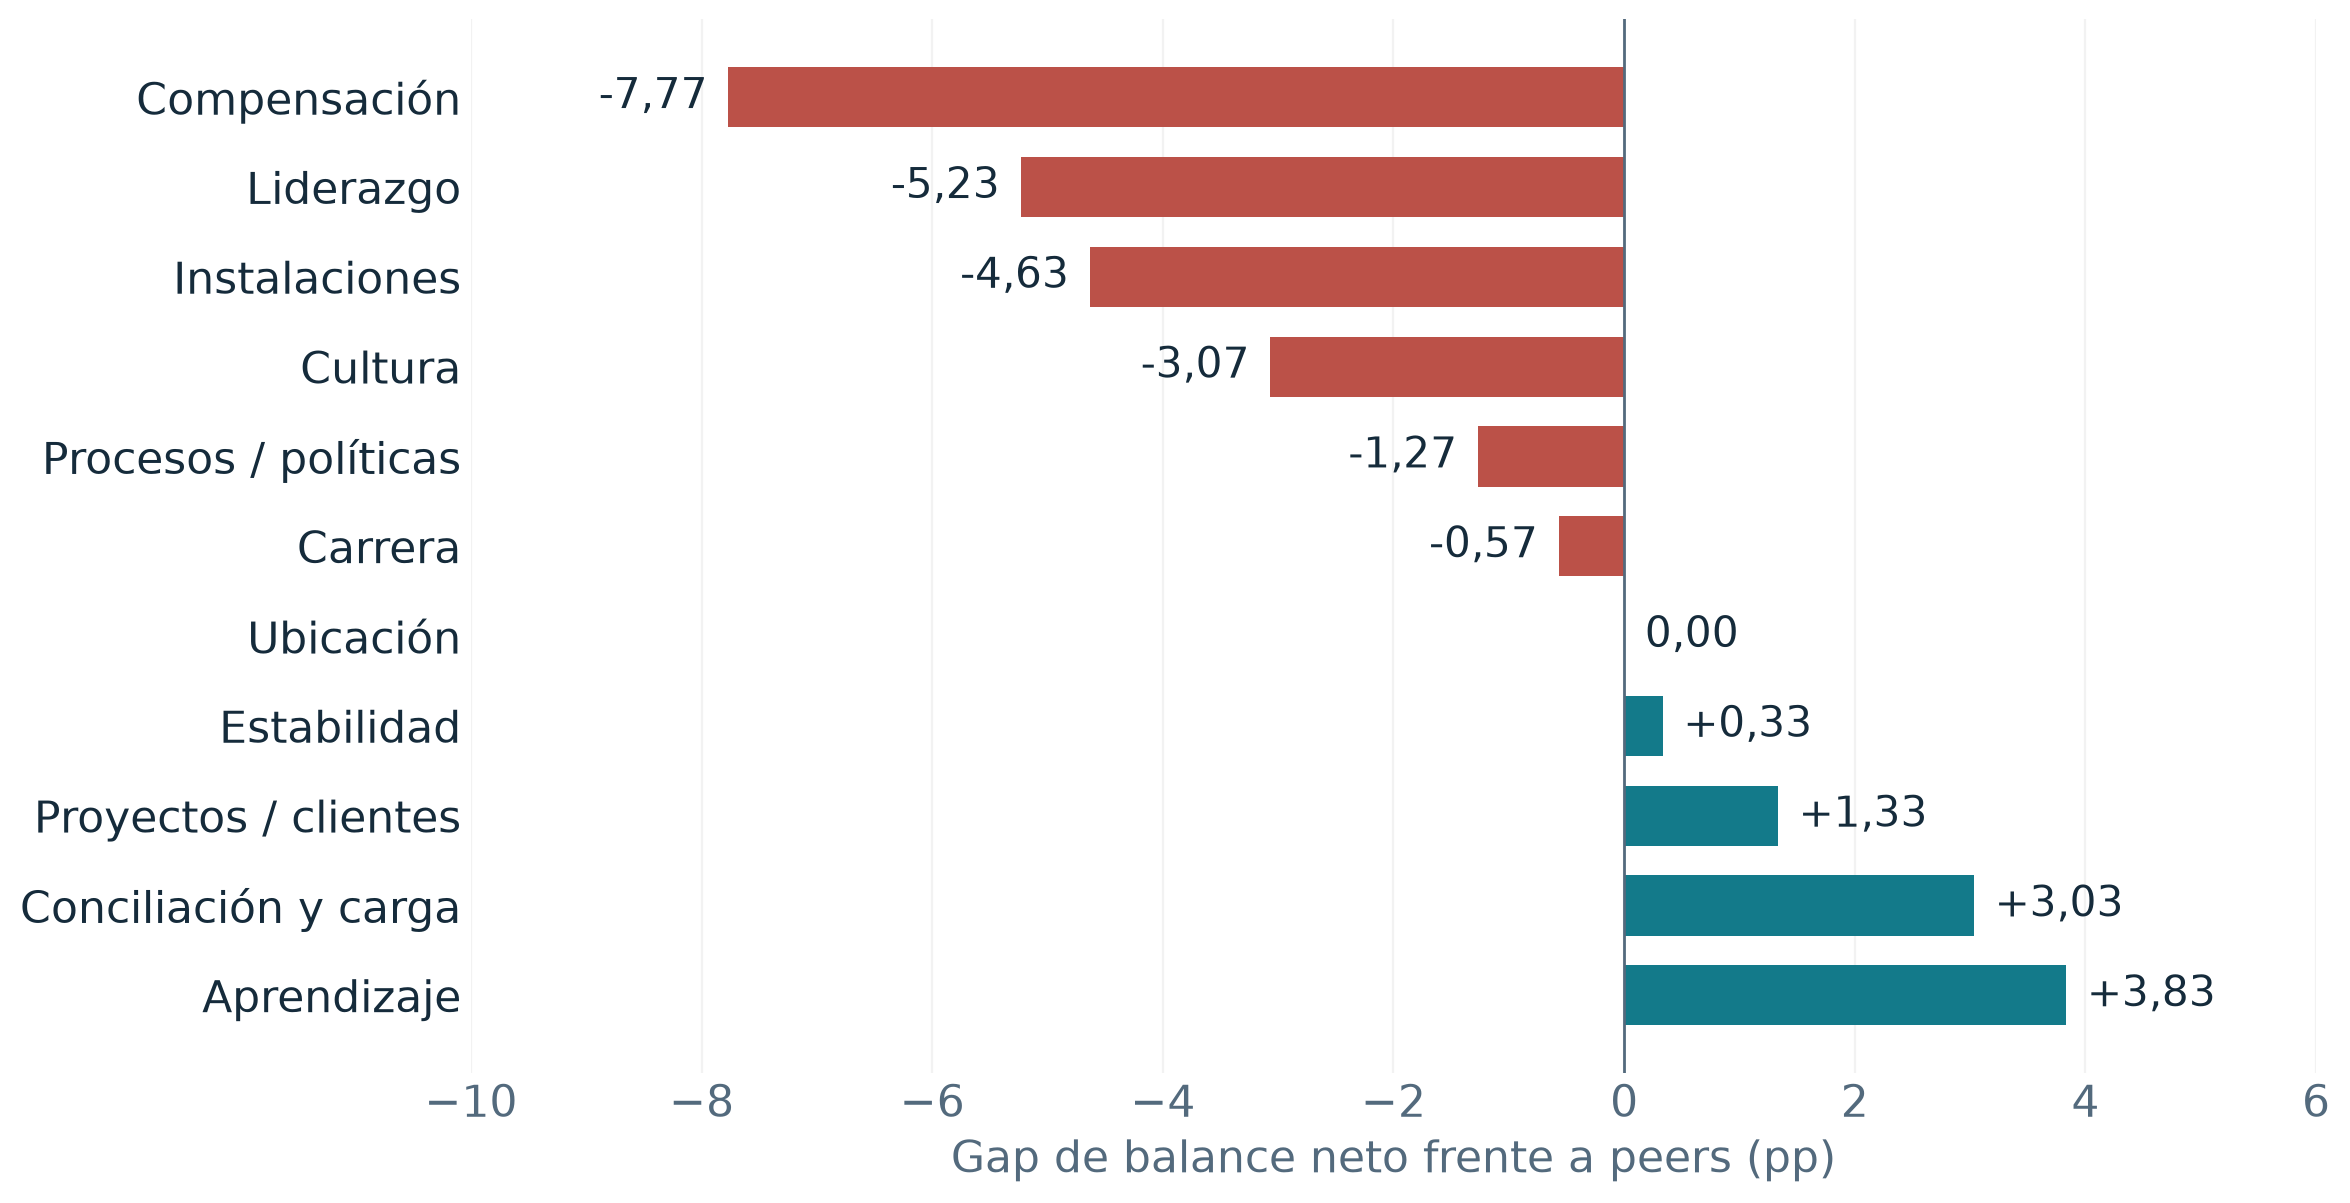

In [17]:
# Ventaja o desventaja frente al mercado
firms, target, peers = FIRMS, TARGET, PEERS
labels = [NAMES[x] for x in firms]
summary = resumen
y = np.arange(len(firms))
comp = comparacion_peers
gaps = comp.loc[CATEGORIAS_ACCIONABLES, 'gap_balance_pp'].sort_values()
fig, ax = plt.subplots(figsize=(12, 6.3))
ax.barh([SHORT[c] for c in gaps.index], gaps.values, color=[RED if v < 0 else TEAL for v in gaps], height=0.67)
for i, v in enumerate(gaps):
    ax.text(v + (0.18 if v >= 0 else -0.18), i, ('+' if v > 0 else '') + f(v), va='center', ha='left' if v >= 0 else 'right', fontsize=15)
ax.axvline(0, color=MUTED, lw=1)
ax.set_xlim(min(-10, gaps.min() - 2), max(6, gaps.max() + 2))
ax.invert_yaxis()
polish(ax, 'Gap de balance neto frente a peers (pp)')
fig.tight_layout()
guardar_grafica(fig, '07_gap_balance')


### Gráfica 08 · Contraste de liderazgo y compensación con valoración

**Origen:** `contraste_compucom`, calculadas en el apartado 4. Comparación con peers.

En CompuCom se comparan reseñas cuyos cons se asignan a cada categoría con el resto de cons válidos. Rating sobre puntuaciones disponibles; no recomendaría sobre respuestas disponibles, incluyendo «Sin opinión». Los recuentos por indicador están en contraste_compucom. «Resto» significa sin asignación a esa categoría, no ausencia verificada del problema. Asociación descriptiva, sin causalidad.


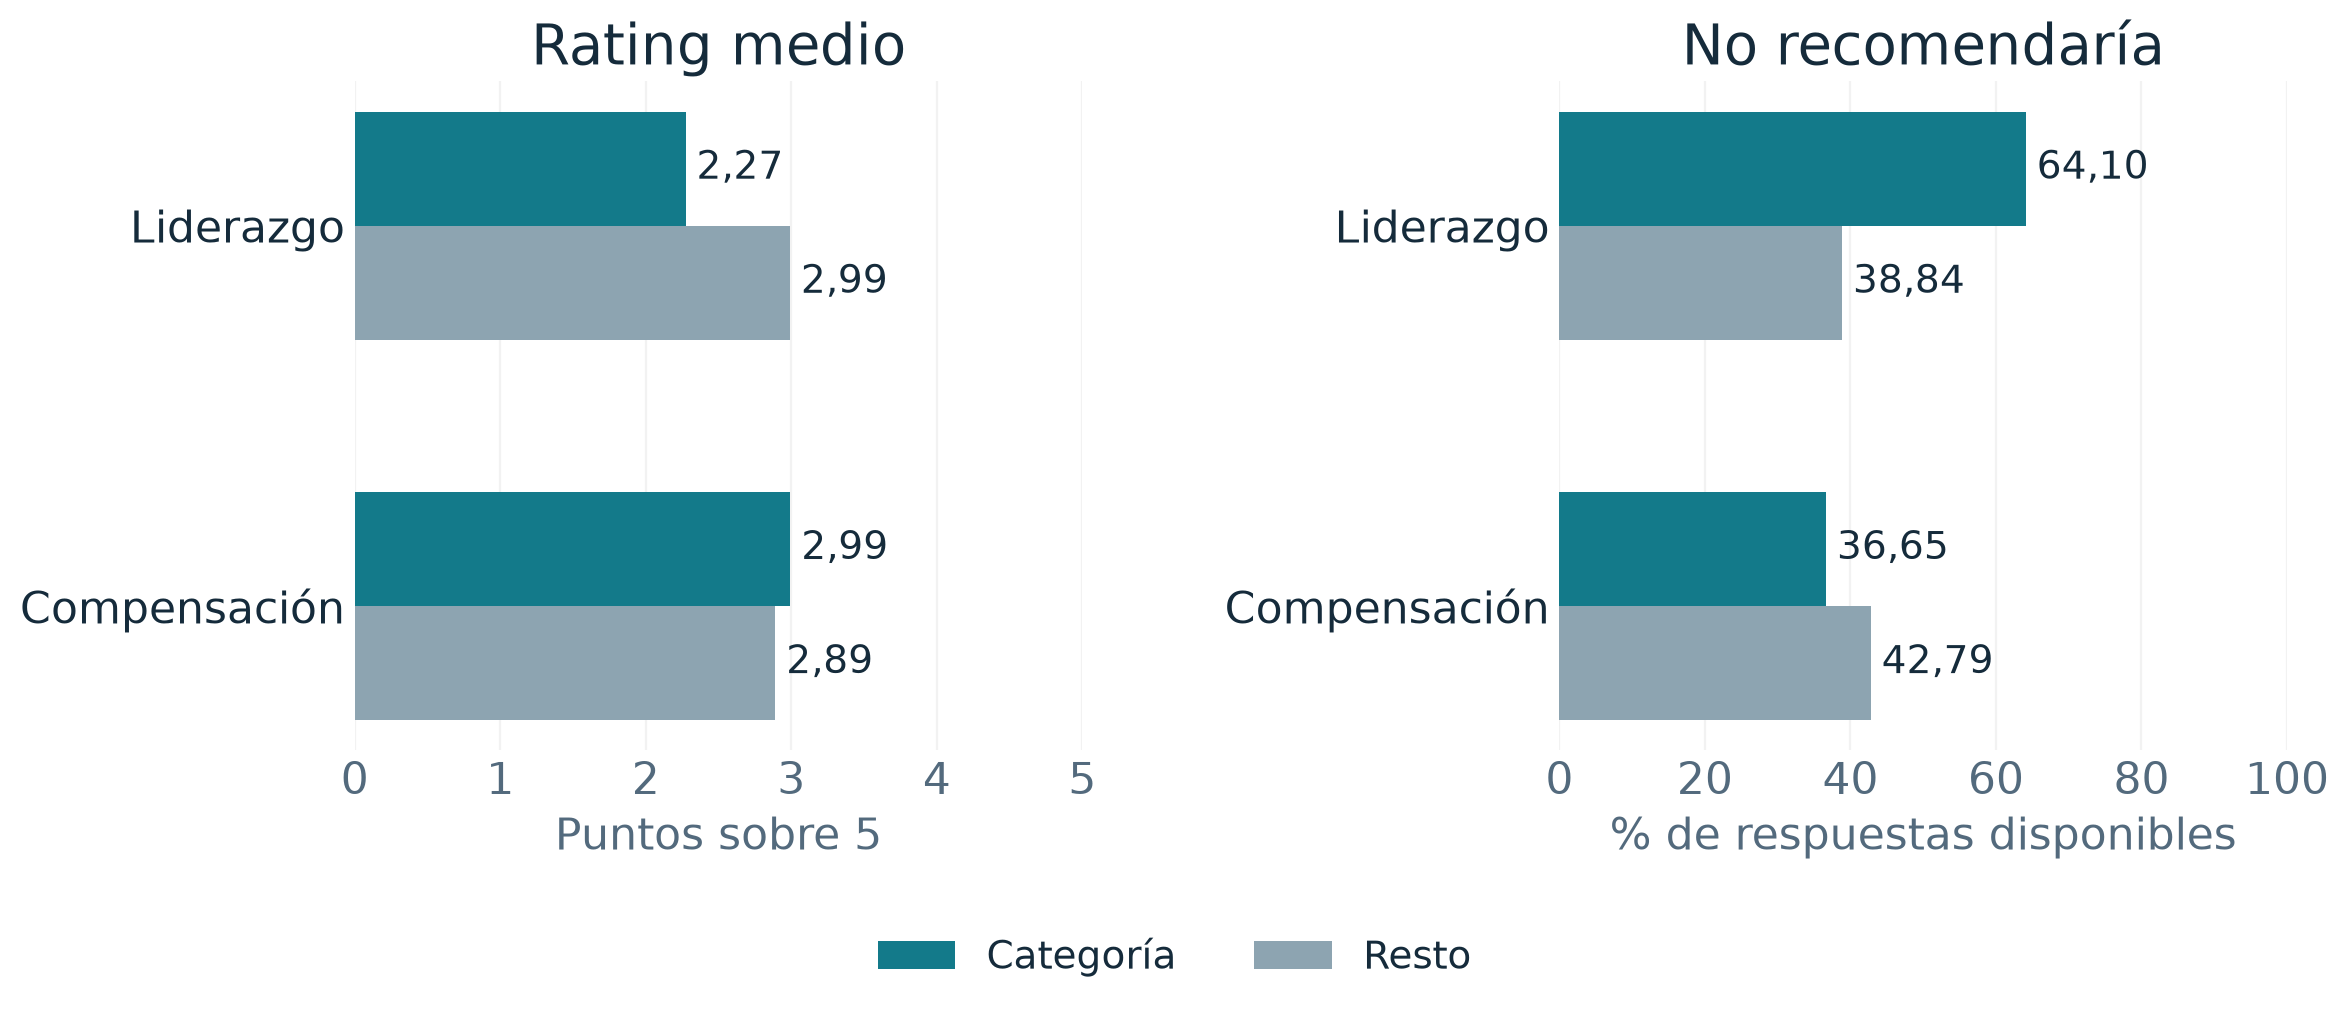

In [18]:
# Contraste de liderazgo y compensación con valoración
firms, target, peers = FIRMS, TARGET, PEERS
labels = [NAMES[x] for x in firms]
summary = resumen
y = np.arange(len(firms))
themes = ['Management y liderazgo', 'Compensación y beneficios']
contrast = contraste_compucom
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
pairbars(axes[0], contrast.loc[themes, 'rating_categoria'], contrast.loc[themes, 'rating_resto'], [SHORT[c] for c in themes], 5, 'Rating medio', 'Puntos sobre 5', 2, (TEAL, GREY), ('Categoría', 'Resto'))
pairbars(axes[1], contrast.loc[themes, 'pct_no_recomienda_categoria'], contrast.loc[themes, 'pct_no_recomienda_resto'], [SHORT[c] for c in themes], 100, 'No recomendaría', '% de respuestas disponibles', 2, (TEAL, GREY), ('Categoría', 'Resto'))
handles, names = axes[0].get_legend_handles_labels()
fig.legend(handles, names, ncol=2, loc='lower center', frameon=False, fontsize=14)
fig.tight_layout(rect=(0, 0.1, 1, 1), w_pad=3)
guardar_grafica(fig, '08_contraste_rating_recommend')


### Sensibilidad a las etiquetas de topics mixtos
Se cambia **una etiqueta cada vez** manteniendo las asignaciones automáticas y todos los denominadores. Las alternativas son interpretaciones plausibles, no etiquetas verificadas. Se comprueba cuánto cambian los gaps de liderazgo, compensación, conciliación, carrera y aprendizaje.

Esta comprobación permite identificar conclusiones que dependen de una decisión humana. No sustituye el análisis de estabilidad de BERTopic ante otras muestras o parámetros.

In [19]:
ALTERNATIVAS_TAXONOMIA = [
    ("pros", 1, "Conciliación y carga de trabajo"),
    ("pros", 4, "Cultura y ambiente"),
    ("pros", 6, "Aprendizaje y formación"),
    ("pros", 11, "Management y liderazgo"),
    ("pros", 21, "Cultura y ambiente"),
    ("pros", 22, "Carrera y desarrollo"),
    ("pros", 26, "Management y liderazgo"),
    ("cons", 2, "Procesos y políticas internas"),
    ("cons", 3, "Compensación y beneficios"),
    ("cons", 4, "Management y liderazgo"),
    ("cons", 7, "Aprendizaje y formación"),
    ("cons", 7, "Procesos y políticas internas"),
    ("cons", 10, "Management y liderazgo"),
    ("cons", 18, "Compensación y beneficios"),
    ("cons", 20, "Carrera y desarrollo"),
    ("cons", 25, "Carrera y desarrollo"),
    ("cons", 26, "Procesos y políticas internas"),
]
TEMAS_SENSIBILIDAD = ["Management y liderazgo", "Compensación y beneficios",
                     "Conciliación y carga de trabajo", "Carrera y desarrollo", "Aprendizaje y formación"]
filas_sensibilidad = []
for corpus, topic_id, alternativa in ALTERNATIVAS_TAXONOMIA:
    documentos = asignaciones_pros if corpus == "pros" else asignaciones_cons
    mapa = (CATEGORIAS_PROS if corpus == "pros" else CATEGORIAS_CONS).copy()
    mapa[topic_id] = alternativa
    cambios = documentos.assign(categoria=documentos["topic_id"].map(mapa))
    conteos = cambios.groupby(["firm", "categoria"]).size().unstack(fill_value=0).reindex(index=FIRMS, columns=CATEGORIAS_NEGOCIO, fill_value=0)
    pct = conteos.div(cambios.groupby("firm").size().reindex(FIRMS), axis=0).mul(100)
    nuevo_balance = pct.subtract(porcentajes_cons) if corpus == "pros" else porcentajes_pros.subtract(pct)
    gap = nuevo_balance.loc[TARGET] - nuevo_balance.loc[PEERS].mean()
    fila = {"escenario": f"{corpus} {topic_id} → {alternativa}"}
    fila.update({tema: gap[tema] for tema in TEMAS_SENSIBILIDAD})
    filas_sensibilidad.append(fila)
sensibilidad_etiquetas = pd.DataFrame(filas_sensibilidad).set_index("escenario")
sensibilidad_etiquetas.loc["Taxonomía principal"] = comparacion_peers.loc[TEMAS_SENSIBILIDAD, "gap_balance_pp"]
display(sensibilidad_etiquetas.round(2))
for tema in TEMAS_SENSIBILIDAD:
    valores = sensibilidad_etiquetas[tema]
    mostrar(
        f"**{tema}:** gap principal {fmt(comparacion_peers.loc[tema, 'gap_balance_pp'])} pp; "
        f"rango de escenarios individuales **{fmt(valores.min())} a {fmt(valores.max())} pp**. "
        + ("El signo se mantiene en estos escenarios." if valores.lt(0).all() or valores.ge(0).all()
           else "El signo cambia: esta lectura depende de la etiqueta y requiere revisión adicional.")
    )

,Management y liderazgo,Compensación y beneficios,Conciliación y carga de trabajo,Carrera y desarrollo,Aprendizaje y formación
escenario,,,,,
pros 1 → Conciliación y carga de trabajo,-5.23,-7.77,-1.60,-0.57,3.83
pros 4 → Cultura y ambiente,-5.23,-7.77,3.03,-0.57,3.83
pros 6 → Aprendizaje y formación,-5.23,-7.77,3.03,-0.57,-1.30
pros 11 → Management y liderazgo,-4.77,-7.77,3.03,-0.57,3.83
pros 21 → Cultura y ambiente,-5.23,-7.77,3.03,-0.57,3.83
pros 22 → Carrera y desarrollo,-5.23,-7.77,3.03,3.63,3.83
pros 26 → Management y liderazgo,-5.50,-7.77,3.03,-0.57,3.83
cons 2 → Procesos y políticas internas,-5.23,-7.77,3.03,-0.57,3.83
cons 3 → Compensación y beneficios,-1.90,-11.10,3.03,-0.57,3.83


**Management y liderazgo:** gap principal -5,23 pp; rango de escenarios individuales **-5,50 a -1,90 pp**. El signo se mantiene en estos escenarios.

**Compensación y beneficios:** gap principal -7,77 pp; rango de escenarios individuales **-12,33 a -7,77 pp**. El signo se mantiene en estos escenarios.

**Conciliación y carga de trabajo:** gap principal 3,03 pp; rango de escenarios individuales **-1,60 a 3,03 pp**. El signo cambia: esta lectura depende de la etiqueta y requiere revisión adicional.

**Carrera y desarrollo:** gap principal -0,57 pp; rango de escenarios individuales **-0,57 a 3,63 pp**. El signo cambia: esta lectura depende de la etiqueta y requiere revisión adicional.

**Aprendizaje y formación:** gap principal 3,83 pp; rango de escenarios individuales **-1,30 a 4,83 pp**. El signo cambia: esta lectura depende de la etiqueta y requiere revisión adicional.

### Gráfica 11 · Cómo cambia la lectura con etiquetas alternativas

**Origen:** `sensibilidad_etiquetas`, `comparacion_peers`, calculadas en el apartado 4. Sensibilidad.

Se cambia una etiqueta de topic cada vez y se conservan documentos y denominadores. La barra une el mínimo y el máximo de esos escenarios; el punto muestra la taxonomía principal. Son rangos de recodificación, no intervalos de confianza. Aprendizaje cambia de signo y exige validación antes de comunicarlo en selección.


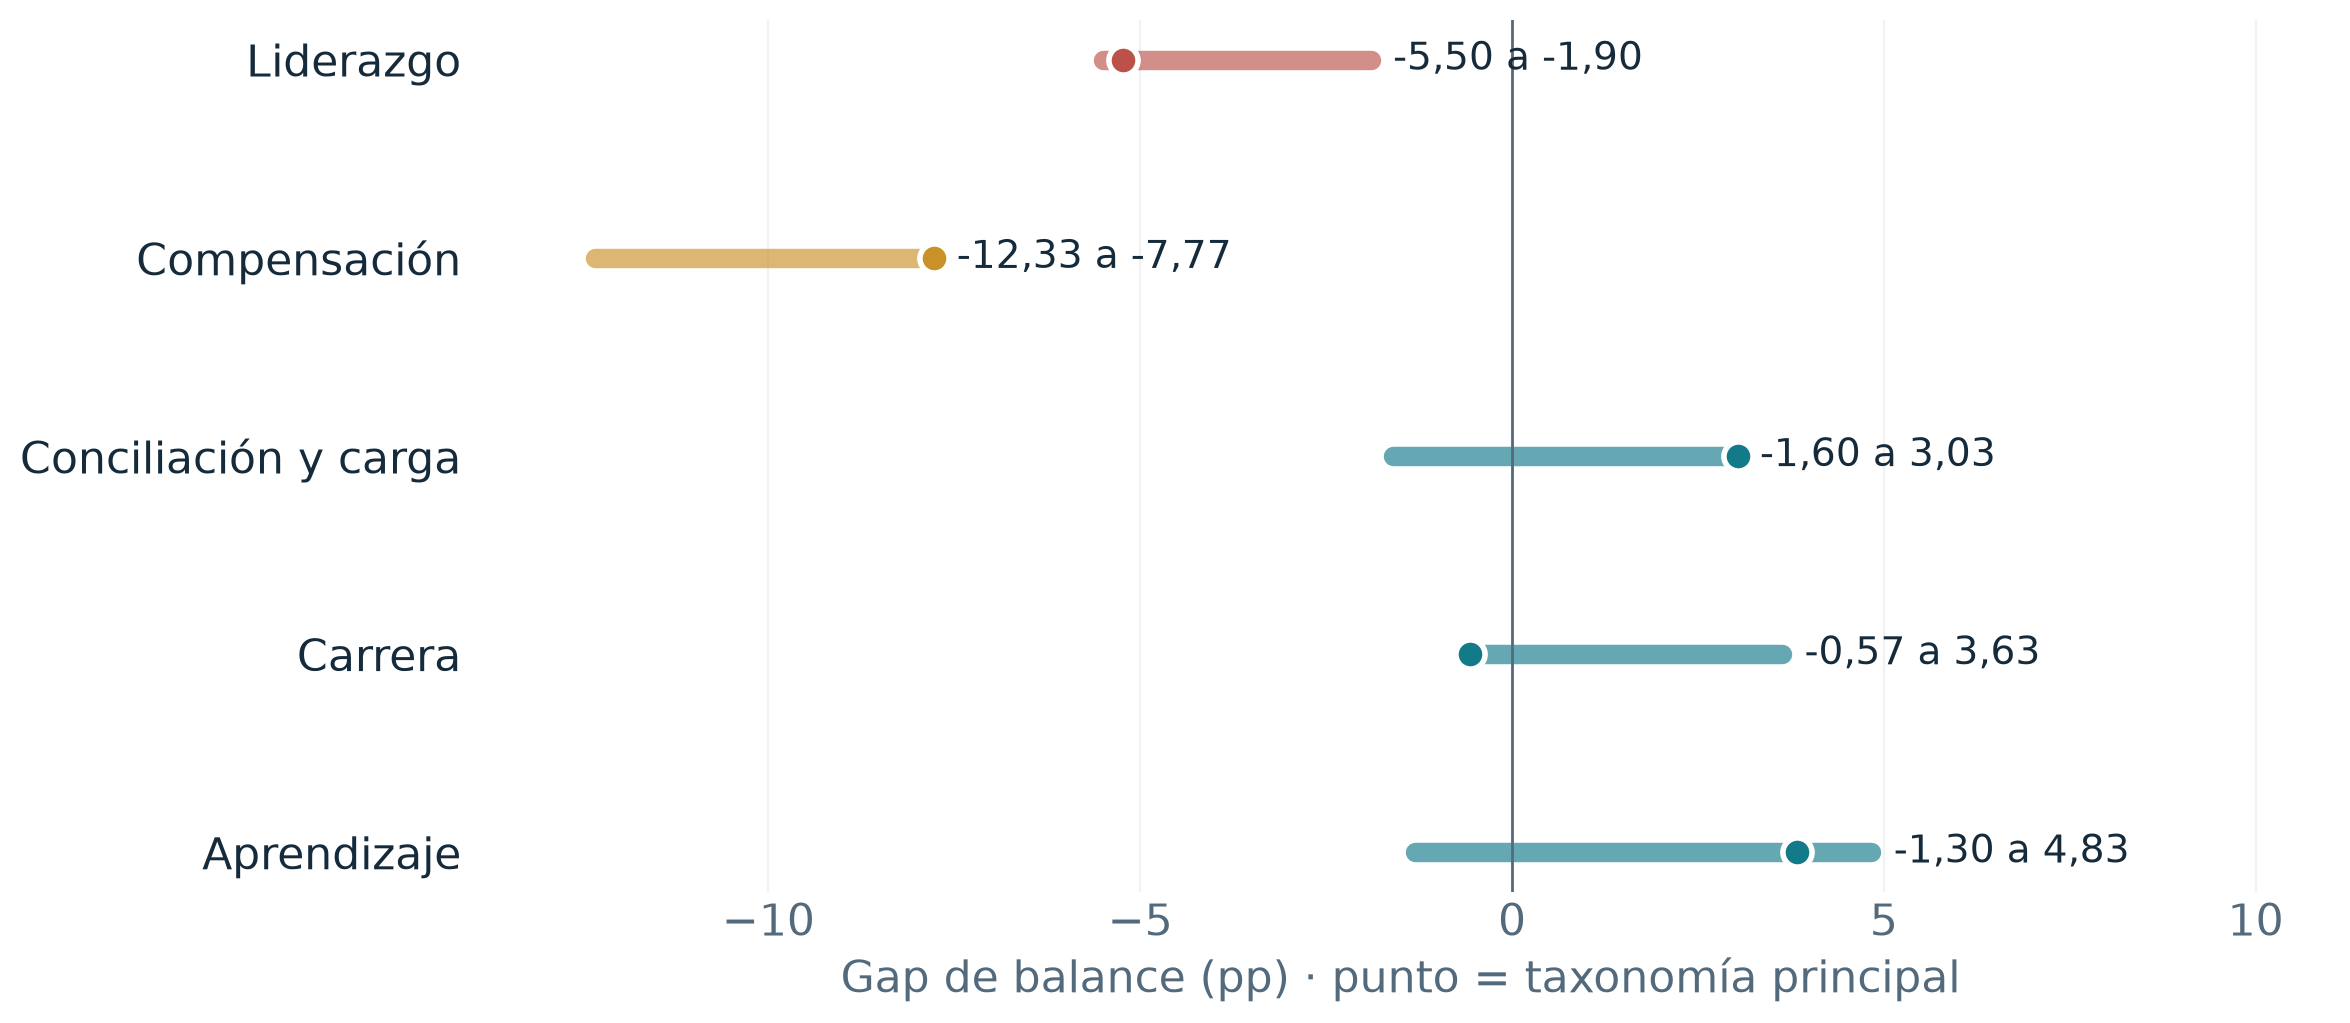

In [20]:
# Cómo cambia la lectura con etiquetas alternativas
firms, target, peers = FIRMS, TARGET, PEERS
labels = [NAMES[x] for x in firms]
summary = resumen
y = np.arange(len(firms))
comp = comparacion_peers
sensitivity = sensibilidad_etiquetas
themes = list(TEMAS_SENSIBILIDAD)
fig, ax = plt.subplots(figsize=(12, 5.4))
for i, category in enumerate(themes):
    vals = sensitivity[category]
    main = comp.loc[category, 'gap_balance_pp']
    color = RED if category == 'Management y liderazgo' else GOLD if category == 'Compensación y beneficios' else TEAL
    ax.plot([vals.min(), vals.max()], [i, i], lw=7, color=color, alpha=0.65, solid_capstyle='round')
    ax.scatter([main], [i], s=110, color=color, edgecolor='white', linewidth=2, zorder=3)
    ax.text(vals.max() + 0.3, i, f'{f(vals.min())} a {f(vals.max())}', va='center', fontsize=14)
ax.axvline(0, color=MUTED, lw=1)
ax.set(yticks=np.arange(len(themes)), yticklabels=[SHORT[c] for c in themes], xlim=(-14, 11))
ax.invert_yaxis()
polish(ax, 'Gap de balance (pp) · punto = taxonomía principal')
fig.tight_layout()
guardar_grafica(fig, '11_sensibilidad_etiquetas')


## 5. Empleados actuales frente a antiguos
Se comparan categorías de cons de CompuCom por situación y antiguos de CompuCom frente a antiguos de peers, con recuentos y media no ponderada. El denominador incluye **todos los cons válidos**, aunque sean outliers.

Los comentarios de antiguos orientan hipótesis, pero no son registros verificados de motivos de salida. El menor rating se muestra como contexto de selección; la comparación principal aquí es temática.

In [21]:
# Reutilizamos las categorías de los cons ya modeladas; solo añadimos la situación original.
metadatos_situacion = df[["situacion"]].copy().reset_index(drop=True)
metadatos_situacion["review_id"] = df.index.to_numpy()
cons_con_situacion = asignaciones_cons[["review_id", "firm", "categoria"]].merge(
    metadatos_situacion,
    on="review_id",
    how="left",
    validate="one_to_one",
)
cons_con_situacion = cons_con_situacion.loc[
    cons_con_situacion["situacion"].isin(["Actual", "Antiguo"])
].copy()

# En CompuCom, comparar el peso relativo de cada categoría entre actuales y antiguos.
cons_compucom_por_situacion = cons_con_situacion.loc[
    cons_con_situacion["firm"].eq(TARGET)
]
conteos_compucom_situacion = (
    cons_compucom_por_situacion.groupby(["situacion", "categoria"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["Actual", "Antiguo"], columns=CATEGORIAS_NEGOCIO, fill_value=0)
)
n_compucom_situacion = (
    cons_compucom_por_situacion.groupby("situacion").size()
    .reindex(["Actual", "Antiguo"], fill_value=0)
)
porcentajes_compucom_situacion = conteos_compucom_situacion.div(
    n_compucom_situacion.replace(0, np.nan), axis=0
).mul(100)
if not np.allclose(porcentajes_compucom_situacion.sum(axis=1), 100):
    raise AssertionError("Los porcentajes por situación de CompuCom no suman 100 %.")

tabla_actuales_vs_antiguos = pd.DataFrame(index=CATEGORIAS_NEGOCIO)
tabla_actuales_vs_antiguos["n_actuales"] = conteos_compucom_situacion.loc["Actual"]
tabla_actuales_vs_antiguos["pct_actuales"] = porcentajes_compucom_situacion.loc["Actual"]
tabla_actuales_vs_antiguos["n_antiguos"] = conteos_compucom_situacion.loc["Antiguo"]
tabla_actuales_vs_antiguos["pct_antiguos"] = porcentajes_compucom_situacion.loc["Antiguo"]
tabla_actuales_vs_antiguos["diferencia_antiguos_menos_actuales_pp"] = (
    tabla_actuales_vs_antiguos["pct_antiguos"] - tabla_actuales_vs_antiguos["pct_actuales"]
)

print("CompuCom: categorías de cons por situación; porcentajes sobre los cons válidos (incluidos outliers) de cada grupo.")
print(f"Denominadores: {n_compucom_situacion['Actual']} actuales y {n_compucom_situacion['Antiguo']} antiguos.")
display(tabla_actuales_vs_antiguos.round(2).sort_values("diferencia_antiguos_menos_actuales_pp", ascending=False))

# Para los antiguos, comparar a CompuCom con la media no ponderada de las proporciones por peer.
cons_antiguos = cons_con_situacion.loc[cons_con_situacion["situacion"].eq("Antiguo")]
conteos_antiguos_por_empresa = (
    cons_antiguos.groupby(["firm", "categoria"]).size().unstack(fill_value=0)
    .reindex(index=FIRMS, columns=CATEGORIAS_NEGOCIO, fill_value=0)
)
n_antiguos_por_empresa = cons_antiguos.groupby("firm").size().reindex(FIRMS, fill_value=0)
porcentajes_antiguos_por_empresa = conteos_antiguos_por_empresa.div(
    n_antiguos_por_empresa.replace(0, np.nan), axis=0
).mul(100)
if not np.allclose(porcentajes_antiguos_por_empresa.sum(axis=1), 100):
    raise AssertionError("Los porcentajes de cons de antiguos no suman 100 % por empresa.")

comparacion_cons_antiguos_peers = pd.DataFrame(index=CATEGORIAS_NEGOCIO)
comparacion_cons_antiguos_peers["n_antiguos_compucom"] = conteos_antiguos_por_empresa.loc[TARGET]
comparacion_cons_antiguos_peers["pct_compucom"] = porcentajes_antiguos_por_empresa.loc[TARGET]
comparacion_cons_antiguos_peers["pct_media_peers"] = porcentajes_antiguos_por_empresa.loc[PEERS].mean(axis=0)
comparacion_cons_antiguos_peers["gap_compucom_vs_peers_pp"] = (
    comparacion_cons_antiguos_peers["pct_compucom"]
    - comparacion_cons_antiguos_peers["pct_media_peers"]
)

print("Cons de antiguos: CompuCom frente a la media no ponderada de los tres peers.")
print("Denominadores de antiguos por empresa:")
display(n_antiguos_por_empresa.rename("n_antiguos").to_frame())
display(comparacion_cons_antiguos_peers.round(2).sort_values("gap_compucom_vs_peers_pp", ascending=False))

# Los ratings se muestran solo para comprobar el sesgo de selección, no para priorizar temas.
ratings_por_situacion = (
    df.loc[df["situacion"].isin(["Actual", "Antiguo"])]
    .pivot_table(index="firm", columns="situacion", values="overall_rating", aggfunc="mean")
    .reindex(index=FIRMS, columns=["Actual", "Antiguo"])
)
ratings_por_situacion["diferencia_antiguo_menos_actual"] = (
    ratings_por_situacion["Antiguo"] - ratings_por_situacion["Actual"]
)
print("Control de contexto: rating medio por situación; no se usa como medida de motivos de salida.")
display(ratings_por_situacion.round(2))
tema_antiguos = comparacion_cons_antiguos_peers.loc[CATEGORIAS_ACCIONABLES,"gap_compucom_vs_peers_pp"].idxmax()
a=tabla_actuales_vs_antiguos.loc[tema_antiguos]
p=comparacion_cons_antiguos_peers.loc[tema_antiguos]
mostrar(
    f"**Conclusión accionable — antiguos:** {tema_antiguos} tiene la mayor diferencia desfavorable entre temas accionables "
    f"frente a antiguos de peers: **{fmt(p['pct_compucom'])} %** frente a **{fmt(p['pct_media_peers'])} %** "
    f"(gap **{fmt(p['gap_compucom_vs_peers_pp'])} pp**; n={int(p['n_antiguos_compucom'])}). "
    f"En CompuCom pesa **{fmt(a['pct_antiguos'])} %** en antiguos y **{fmt(a['pct_actuales'])} %** en actuales. "
    "Revisar ejemplos con entrevistas de salida y escucha de actuales; no concluir que causó rotación. "
    "La cobertura y los grupos pequeños limitan esta lectura."
)

CompuCom: categorías de cons por situación; porcentajes sobre los cons válidos (incluidos outliers) de cada grupo.
Denominadores: 538 actuales y 462 antiguos.


,n_actuales,pct_actuales,n_antiguos,pct_antiguos,diferencia_antiguos_menos_actuales_pp
Sin tema asignado (outlier),227,42.19,215,46.54,4.34
Management y liderazgo,53,9.85,64,13.85,4.00
Otros/mixto,46,8.55,49,10.61,2.06
Estabilidad laboral,6,1.12,10,2.16,1.05
Procesos y políticas internas,2,0.37,4,0.87,0.49
Cultura y ambiente,0,0.00,0,0.00,0.00
Aprendizaje y formación,0,0.00,0,0.00,0.00
Ubicación y movilidad,0,0.00,0,0.00,0.00
Instalaciones y servicios,0,0.00,0,0.00,0.00
Proyectos y clientes,6,1.12,5,1.08,-0.03


Cons de antiguos: CompuCom frente a la media no ponderada de los tres peers.
Denominadores de antiguos por empresa:


,n_antiguos
firm,
CompuCom,462
Infogain,234
World-Wide-Technology,156
Rackspace-Technology,347


,n_antiguos_compucom,pct_compucom,pct_media_peers,gap_compucom_vs_peers_pp
Compensación y beneficios,57,12.34,6.74,5.60
Management y liderazgo,64,13.85,11.15,2.70
Procesos y políticas internas,4,0.87,0.21,0.65
Carrera y desarrollo,7,1.52,0.98,0.54
Conciliación y carga de trabajo,24,5.19,4.97,0.22
Cultura y ambiente,0,0.00,0.00,0.00
Instalaciones y servicios,0,0.00,0.00,0.00
Aprendizaje y formación,0,0.00,0.00,0.00
Ubicación y movilidad,0,0.00,0.00,0.00
Estabilidad laboral,10,2.16,2.40,-0.24


Control de contexto: rating medio por situación; no se usa como medida de motivos de salida.


situacion,Actual,Antiguo,diferencia_antiguo_menos_actual
firm,,,
CompuCom,3.18,2.59,-0.59
Infogain,4.02,3.05,-0.97
World-Wide-Technology,4.24,3.32,-0.92
Rackspace-Technology,3.80,2.86,-0.93


**Conclusión accionable — antiguos:** Compensación y beneficios tiene la mayor diferencia desfavorable entre temas accionables frente a antiguos de peers: **12,34 %** frente a **6,74 %** (gap **5,60 pp**; n=57). En CompuCom pesa **12,34 %** en antiguos y **19,33 %** en actuales. Revisar ejemplos con entrevistas de salida y escucha de actuales; no concluir que causó rotación. La cobertura y los grupos pequeños limitan esta lectura.

### Gráfica 09 · Qué temas destacan entre empleados y antiguos

**Origen:** `tabla_actuales_vs_antiguos`, `comparacion_cons_antiguos_peers`, `n_compucom_situacion`, `n_antiguos_por_empresa`, calculadas en el apartado 5. Actuales y antiguos.

Porcentajes sobre cons válidos de cada grupo: actuales y antiguos de CompuCom, y media aritmética de antiguos de los tres peers. Los denominadores se muestran en este apartado; los grupos tienen tamaños distintos. Son experiencias asociadas a salidas, no motivos de rotación demostrados.


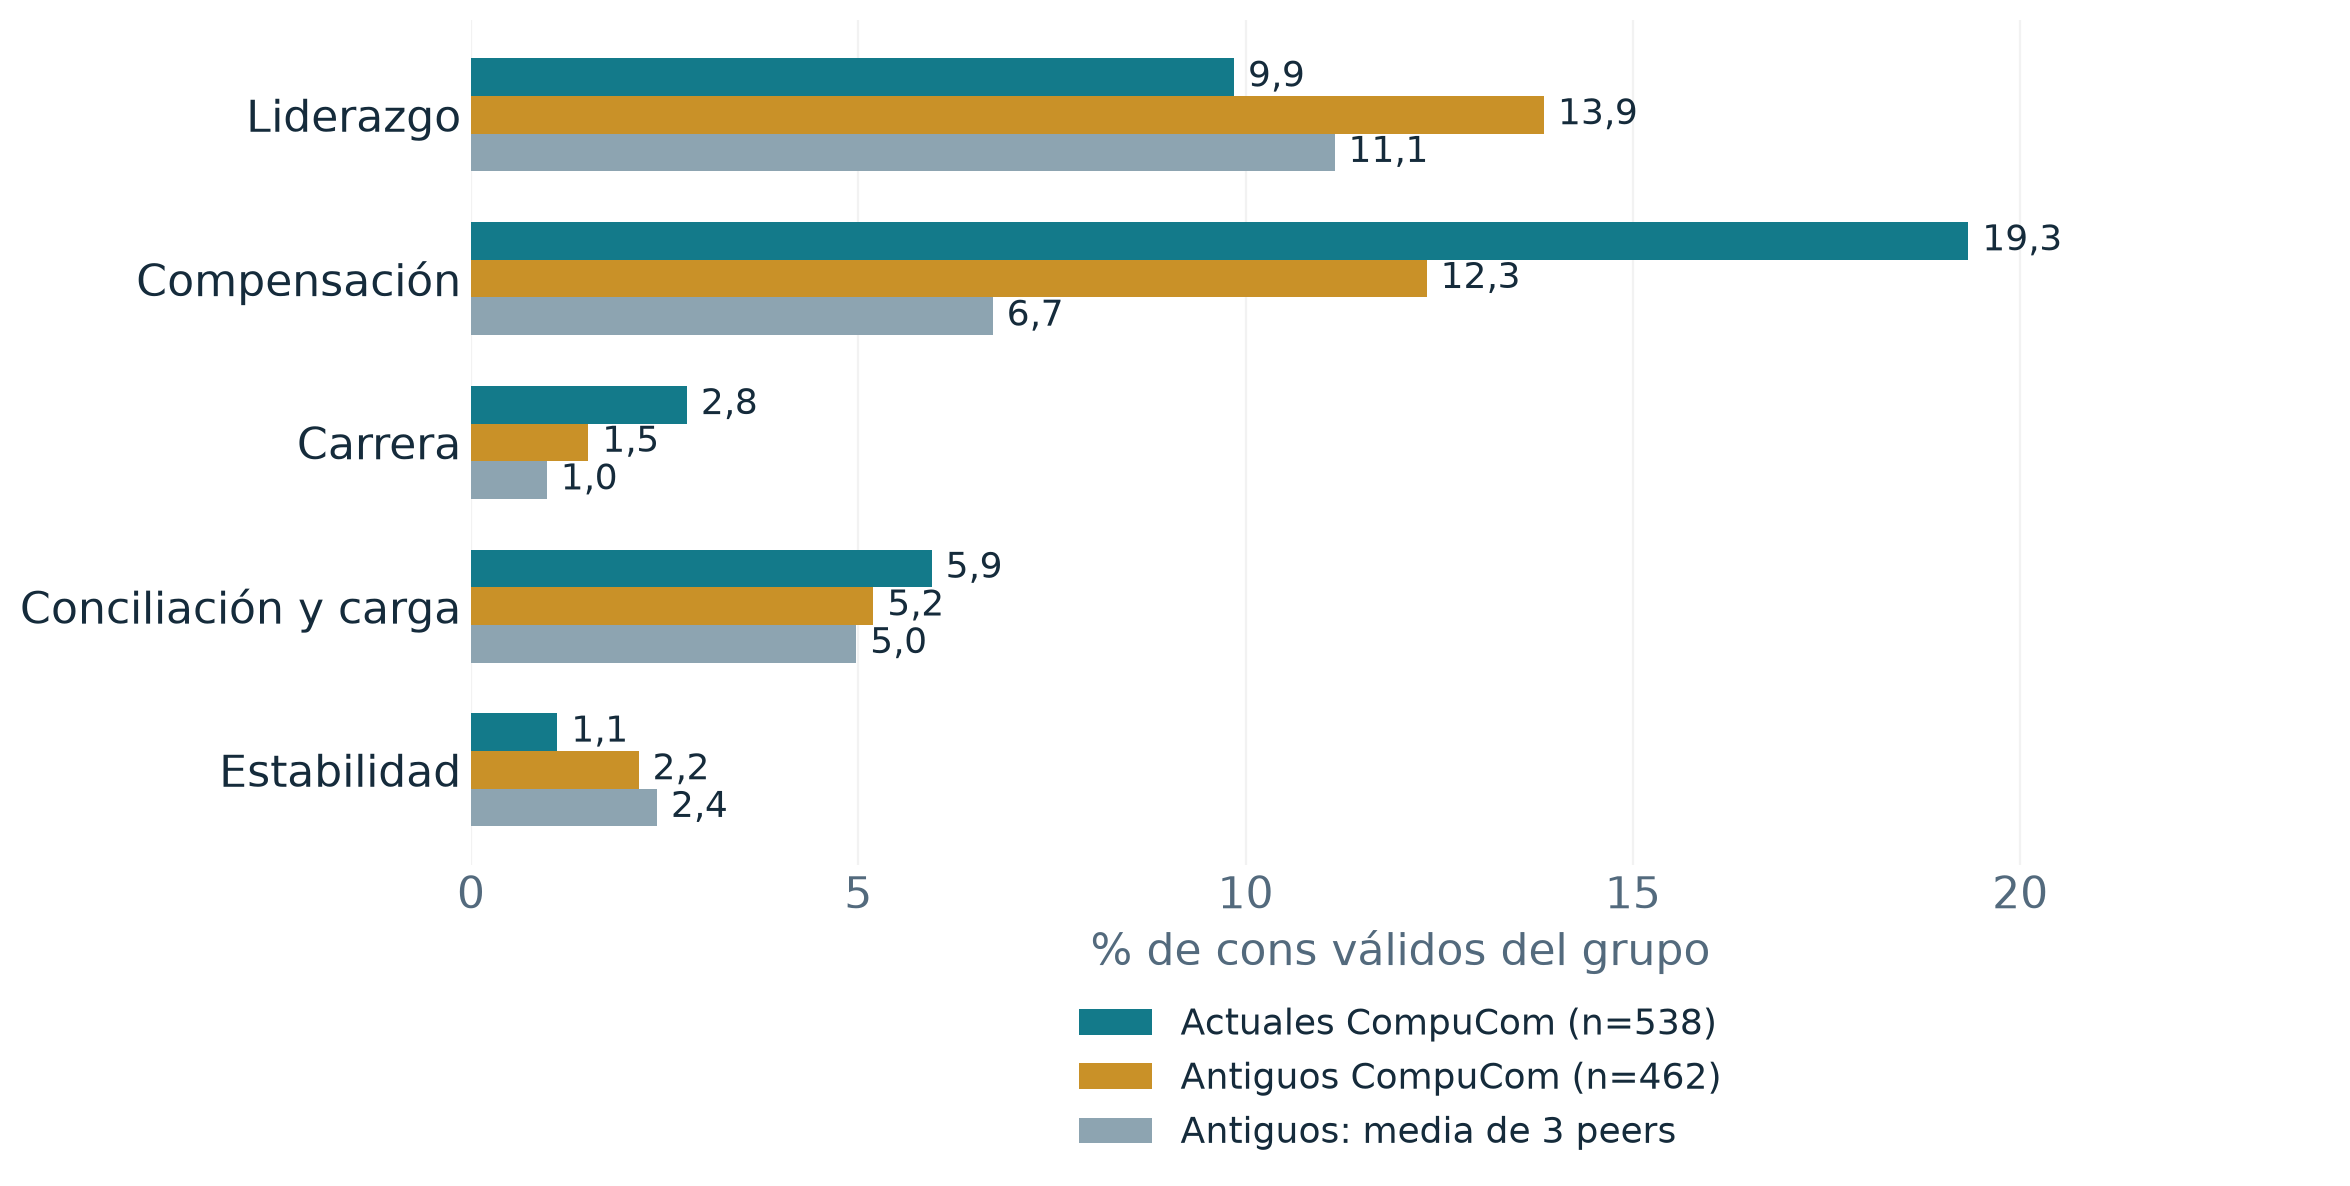

In [22]:
# Qué temas destacan entre empleados y antiguos
firms, target, peers = FIRMS, TARGET, PEERS
labels = [NAMES[x] for x in firms]
summary = resumen
y = np.arange(len(firms))
themes = ['Management y liderazgo', 'Compensación y beneficios', 'Carrera y desarrollo', 'Conciliación y carga de trabajo', 'Estabilidad laboral']
states = tabla_actuales_vs_antiguos
expeers = comparacion_cons_antiguos_peers
fig, ax = plt.subplots(figsize=(12, 6.3))
y2 = np.arange(len(themes))
h = 0.23
for offset, vals, color, name in [(-h, states.loc[themes, 'pct_actuales'], TEAL, f"Actuales CompuCom (n={int(n_compucom_situacion['Actual'])})"), (0, states.loc[themes, 'pct_antiguos'], GOLD, f"Antiguos CompuCom (n={int(n_compucom_situacion['Antiguo'])})"), (h, expeers.loc[themes, 'pct_media_peers'], GREY, 'Antiguos: media de 3 peers')]:
    ax.barh(y2 + offset, vals, height=h, color=color, label=name)
    for i, v in enumerate(vals):
        ax.text(v + 0.18, i + offset, f(v, 1), va='center', fontsize=13)
ax.set(yticks=y2, yticklabels=[SHORT[c] for c in themes], xlim=(0, 24))
ax.invert_yaxis()
polish(ax, '% de cons válidos del grupo')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), frameon=False, ncol=1, fontsize=13)
fig.tight_layout()
guardar_grafica(fig, '09_actuales_antiguos')


## 6. Matriz de priorización
Se cruza **peso en cons de CompuCom** con **desventaja = −gap de balance neto** (positivo = peor). El tamaño muestra casos y el color coherencia con rating/no recomendación. Outliers y categorías sin asunto accionable quedan fuera.

El corte de **5 %** (50 casos en esta muestra) es operativo, no significación estadística. Una desventaja con ambos indicadores coherentes y al menos 20 casos es candidata de mejora; con señal mixta, candidata de diagnóstico. Se prueba sensibilidad a cortes de 2,5/5/10 % y a retirar un peer.

In [23]:
matriz_priorizacion = comparacion_peers.loc[CATEGORIAS_ACCIONABLES,["cons_compucom_pct","gap_balance_pp"]].join(
    contraste_compucom[["n_cons_categoria","delta_rating","delta_no_recomienda_pp","senal_coherente_con_problema"]])
matriz_priorizacion["desventaja_pp"]=-matriz_priorizacion["gap_balance_pp"]
matriz_priorizacion["puntuacion_operativa"]=matriz_priorizacion["cons_compucom_pct"]*matriz_priorizacion["desventaja_pp"].clip(lower=0)
PESO_MINIMO=5.0
def clasificar_prioridad(fila,corte=PESO_MINIMO):
    if fila["desventaja_pp"]<=0: return "Sin desventaja relativa"
    if fila["cons_compucom_pct"]<corte: return "Vigilancia: bajo peso"
    if fila["n_cons_categoria"]>=20 and fila["senal_coherente_con_problema"]: return "Candidata de mejora"
    if fila["delta_rating"] >= 0 and fila["delta_no_recomienda_pp"] <= 0: return "Diagnóstico: contraste no confirma"
    return "Diagnóstico: señal mixta"
matriz_priorizacion["prioridad"]=matriz_priorizacion.apply(clasificar_prioridad,axis=1)
display(matriz_priorizacion.round(2).sort_values("puntuacion_operativa",ascending=False))
# La figura compartida se genera en la celda de gráfica inmediatamente después.
sensibilidad_umbral=pd.DataFrame({
    f"corte_{corte:g}_pct":matriz_priorizacion.apply(lambda fila:clasificar_prioridad(fila,corte),axis=1)
    for corte in [2.5,5.0,10.0]
})
display(sensibilidad_umbral)
sensibilidad_peers=pd.DataFrame({
    f"sin_{peer}":balance_por_empresa.loc[TARGET]-balance_por_empresa.loc[[p for p in PEERS if p!=peer]].mean()
    for peer in PEERS
}).loc[CATEGORIAS_ACCIONABLES]
sensibilidad_peers["gap_tres_peers"]=comparacion_peers.loc[CATEGORIAS_ACCIONABLES,"gap_balance_pp"]
signos=sensibilidad_peers.drop(columns="gap_tres_peers")
sensibilidad_peers["signo_estable"]=signos.lt(0).all(axis=1)|signos.ge(0).all(axis=1)
display(sensibilidad_peers.round(2))
mostrar("**Uso:** la puntuación ordena frecuencia y desventaja; no estima impacto causal ni ahorro. Las lecturas que cambian con etiquetas, umbrales o peers requieren más validación. Las prioridades cubren solo los textos clasificados.")

,cons_compucom_pct,gap_balance_pp,n_cons_categoria,delta_rating,delta_no_recomienda_pp,senal_coherente_con_problema,desventaja_pp,puntuacion_operativa,prioridad
Compensación y beneficios,16.1,-7.77,161,0.10,-6.14,False,7.77,125.04,Diagnóstico: contraste no confirma
Management y liderazgo,11.7,-5.23,117,-0.72,25.26,True,5.23,61.23,Candidata de mejora
Carrera y desarrollo,2.2,-0.57,22,0.14,-19.50,False,0.57,1.25,Vigilancia: bajo peso
Procesos y políticas internas,0.6,-1.27,6,0.60,-25.29,False,1.27,0.76,Vigilancia: bajo peso
Conciliación y carga de trabajo,5.6,3.03,56,0.80,-25.36,False,-3.03,0.00,Sin desventaja relativa
Instalaciones y servicios,0.0,-4.63,0,NaN,NaN,False,4.63,0.00,Vigilancia: bajo peso
Cultura y ambiente,0.0,-3.07,0,NaN,NaN,False,3.07,0.00,Vigilancia: bajo peso
Aprendizaje y formación,0.0,3.83,0,NaN,NaN,False,-3.83,0.00,Sin desventaja relativa
Proyectos y clientes,1.1,1.33,11,1.11,-33.07,False,-1.33,0.00,Sin desventaja relativa
Ubicación y movilidad,0.0,0.00,0,NaN,NaN,False,-0.00,-0.00,Sin desventaja relativa


,corte_2.5_pct,corte_5_pct,corte_10_pct
Compensación y beneficios,Diagnóstico: contraste no confirma,Diagnóstico: contraste no confirma,Diagnóstico: contraste no confirma
Conciliación y carga de trabajo,Sin desventaja relativa,Sin desventaja relativa,Sin desventaja relativa
Carrera y desarrollo,Vigilancia: bajo peso,Vigilancia: bajo peso,Vigilancia: bajo peso
Management y liderazgo,Candidata de mejora,Candidata de mejora,Candidata de mejora
Cultura y ambiente,Vigilancia: bajo peso,Vigilancia: bajo peso,Vigilancia: bajo peso
Instalaciones y servicios,Vigilancia: bajo peso,Vigilancia: bajo peso,Vigilancia: bajo peso
Aprendizaje y formación,Sin desventaja relativa,Sin desventaja relativa,Sin desventaja relativa
Proyectos y clientes,Sin desventaja relativa,Sin desventaja relativa,Sin desventaja relativa
Procesos y políticas internas,Vigilancia: bajo peso,Vigilancia: bajo peso,Vigilancia: bajo peso
Ubicación y movilidad,Sin desventaja relativa,Sin desventaja relativa,Sin desventaja relativa


,sin_Infogain,sin_World-Wide-Technology,sin_Rackspace-Technology,gap_tres_peers,signo_estable
categoria,,,,,
Compensación y beneficios,-14.05,-2.45,-6.80,-7.77,True
Conciliación y carga de trabajo,4.10,1.10,3.90,3.03,True
Carrera y desarrollo,-0.60,-0.70,-0.40,-0.57,True
Management y liderazgo,-3.65,-3.80,-8.25,-5.23,True
Cultura y ambiente,-4.25,-3.05,-1.90,-3.07,True
Instalaciones y servicios,0.95,-7.40,-7.45,-4.63,False
Aprendizaje y formación,4.65,3.10,3.75,3.83,True
Proyectos y clientes,-0.15,2.15,2.00,1.33,False
Procesos y políticas internas,0.20,-2.10,-1.90,-1.27,False


**Uso:** la puntuación ordena frecuencia y desventaja; no estima impacto causal ni ahorro. Las lecturas que cambian con etiquetas, umbrales o peers requieren más validación. Las prioridades cubren solo los textos clasificados.

### Gráfica 10 · Dónde priorizar la investigación de RR. HH.

**Origen:** `matriz_priorizacion`, calculadas en el apartado 6. Priorización.

Eje X: peso de la categoría en cons de CompuCom. Eje Y: desventaja = −gap de balance, en pp; mayor valor indica peor posición relativa. Rojo: menor rating y mayor no recomendación; azul: el contraste no confirma ambos indicadores. El tamaño refleja casos. El corte de 5 % es operativo, no estadístico. No estima impacto causal ni ahorro.


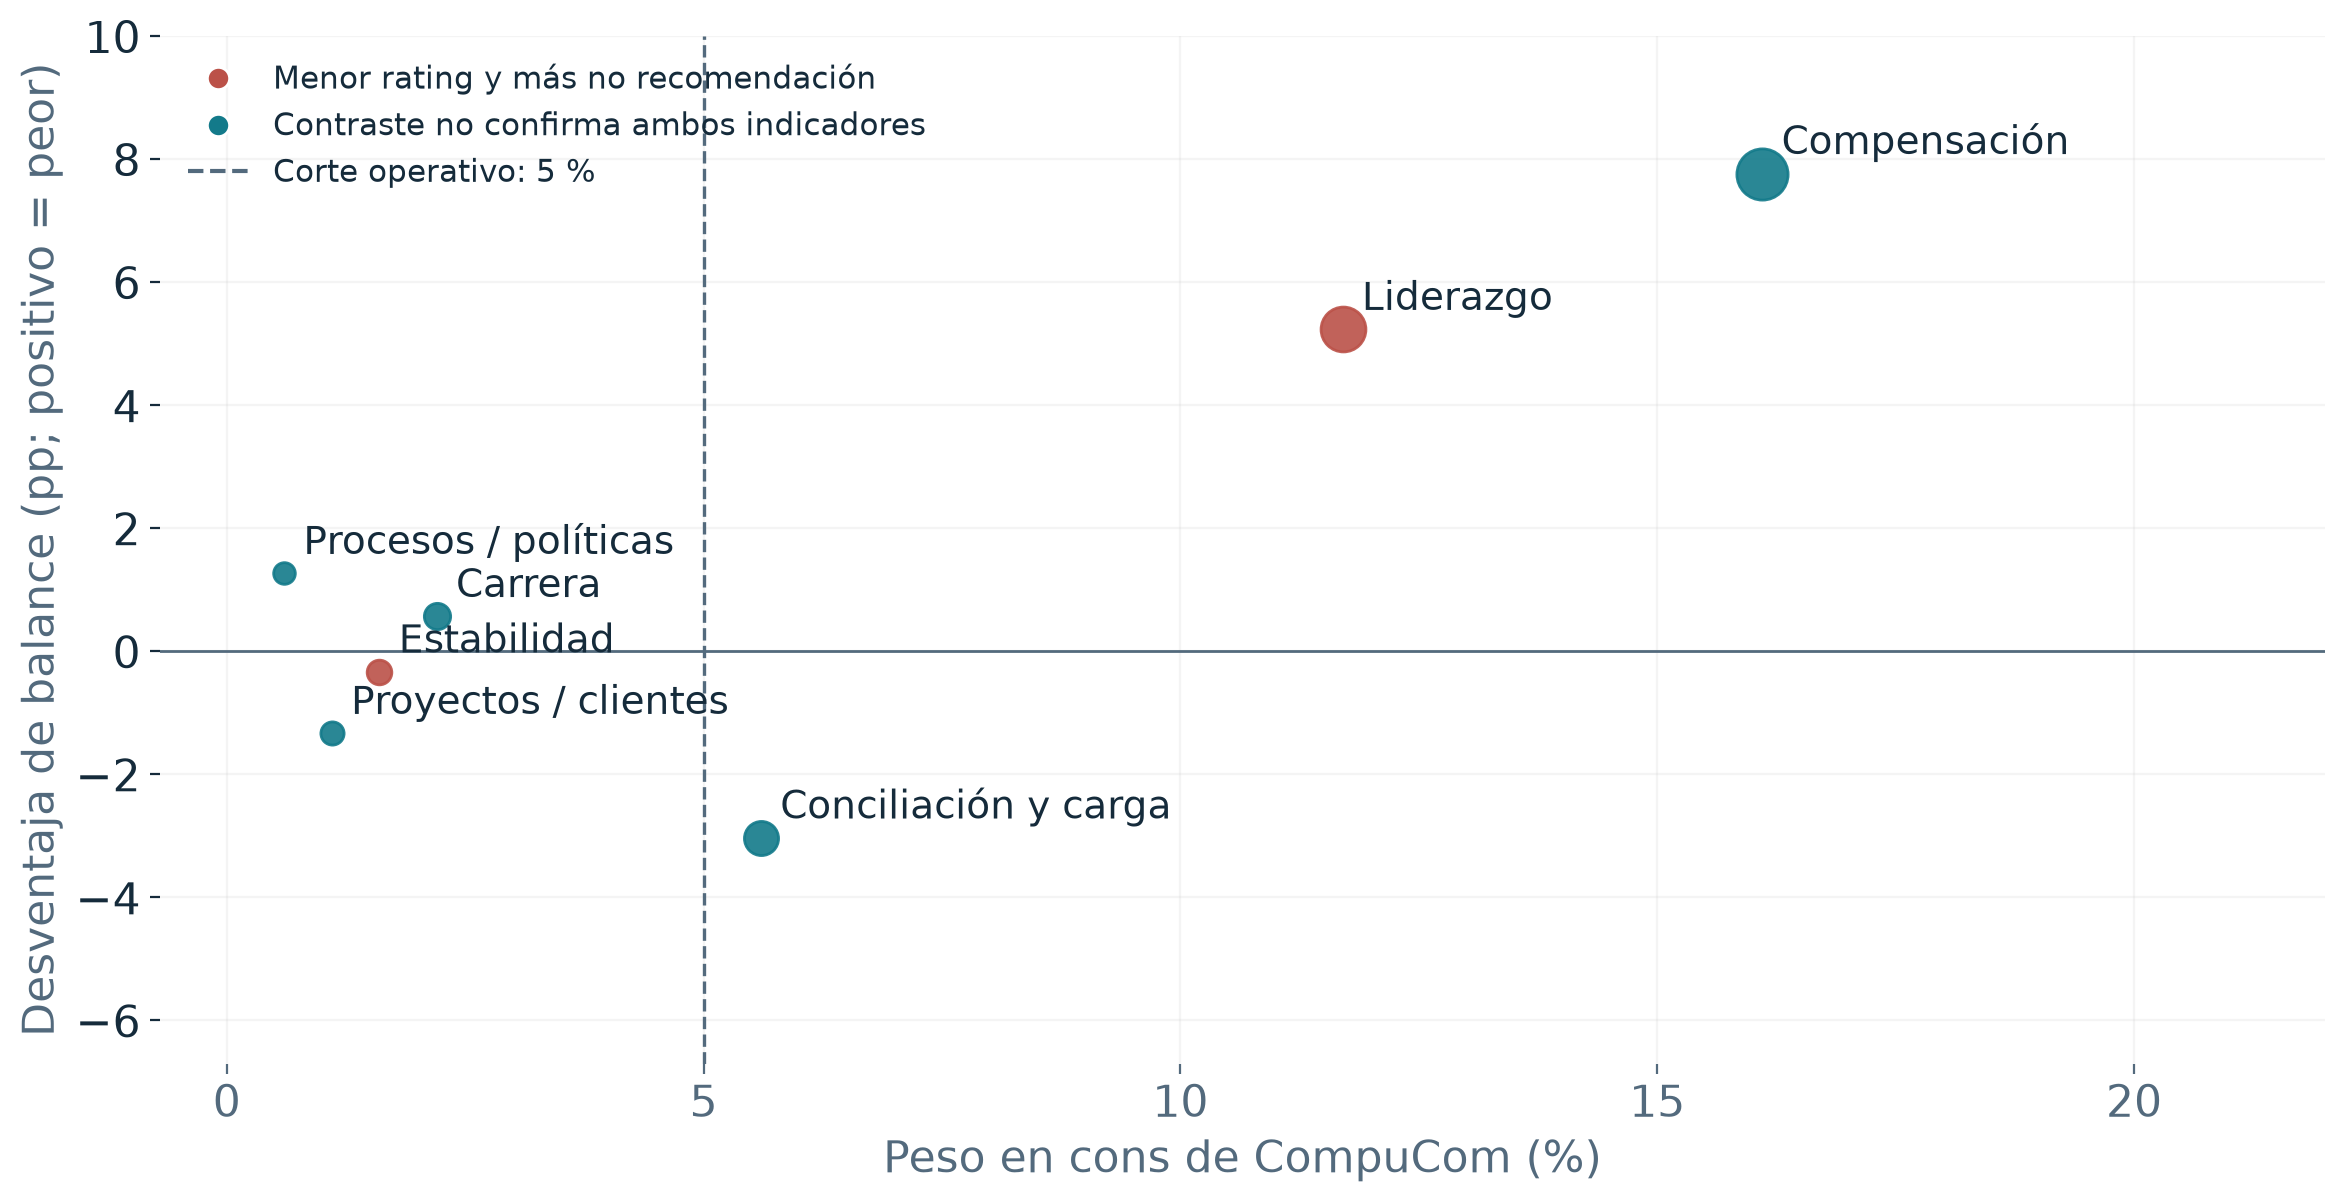

In [24]:
# Dónde priorizar la investigación de RR. HH.
firms, target, peers = FIRMS, TARGET, PEERS
labels = [NAMES[x] for x in firms]
summary = resumen
y = np.arange(len(firms))
matrix = matriz_priorizacion
fig, ax = plt.subplots(figsize=(12, 6.3))
for category, row in matrix.loc[matrix.n_cons_categoria.gt(0)].iterrows():
    color = RED if row.senal_coherente_con_problema else TEAL
    ax.scatter(row.cons_compucom_pct, row.desventaja_pp, s=50 + row.n_cons_categoria * 1.8, color=color, zorder=3, alpha=0.9)
    ax.annotate(SHORT[category], (row.cons_compucom_pct, row.desventaja_pp), xytext=(7, 7), textcoords='offset points', fontsize=14)
ax.axvline(PESO_MINIMO, color=MUTED, ls='--', lw=1.2)
ax.axhline(0, color=MUTED, lw=1)
ax.set(xlim=(-0.7, 22), ylim=(-6.7, 10), xlabel='Peso en cons de CompuCom (%)', ylabel='Desventaja de balance (pp; positivo = peor)')
ax.grid(alpha=0.13)
fig.tight_layout()
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0],marker="o",color="w",markerfacecolor=RED,markersize=8,label="Menor rating y más no recomendación"),
    Line2D([0],[0],marker="o",color="w",markerfacecolor=TEAL,markersize=8,label="Contraste no confirma ambos indicadores"),
    Line2D([0],[0],color=MUTED,linestyle="--",label=f"Corte operativo: {PESO_MINIMO:g} %")],loc="upper left",frameon=False,fontsize=11)
fig.tight_layout()
guardar_grafica(fig, '10_matriz_priorizacion')


## 7. Extra: evolución de los temas
Se compara el peso de cons de CompuCom **antes de 2020** y **desde 2020**, manteniendo todos los textos válidos. Se muestran denominadores. Los períodos tienen distinta duración, con 2018/2023 parciales; no se demuestra un efecto de la pandemia ni de políticas internas.

In [25]:
cons_temporal=asignaciones_cons.merge(df[["date_review"]].rename_axis("review_id").reset_index(),on="review_id",validate="one_to_one")
cons_temporal=cons_temporal.loc[cons_temporal["firm"].eq(TARGET)].copy()
cons_temporal["periodo"]=np.where(cons_temporal["date_review"].dt.year<2020,"Antes de 2020","Desde 2020")
orden_periodos=["Antes de 2020","Desde 2020"]
n_periodos=cons_temporal.groupby("periodo").size().reindex(orden_periodos,fill_value=0)
conteos_temporales=cons_temporal.groupby(["periodo","categoria"]).size().unstack(fill_value=0).reindex(index=orden_periodos,columns=CATEGORIAS_NEGOCIO,fill_value=0)
tabla_temporal_topics=conteos_temporales.div(n_periodos.replace(0,np.nan),axis=0).mul(100).T
tabla_temporal_topics["diferencia_desde_menos_antes_pp"]=tabla_temporal_topics["Desde 2020"]-tabla_temporal_topics["Antes de 2020"]
display(n_periodos.rename("n_cons_validos").to_frame())
display(tabla_temporal_topics.round(2))
tema_cambio=tabla_temporal_topics.loc[CATEGORIAS_ACCIONABLES,"diferencia_desde_menos_antes_pp"].abs().idxmax()
c=tabla_temporal_topics.loc[tema_cambio]
mostrar(
    f"**Lectura del extra:** {tema_cambio} presenta el mayor cambio absoluto: "
    f"**{fmt(c['Antes de 2020'])} %** a **{fmt(c['Desde 2020'])} %** "
    f"({fmt(c['diferencia_desde_menos_antes_pp'])} pp). Contrastar cambios en equipos, clientes o condiciones; no atribuir causalidad."
)

,n_cons_validos
periodo,
Antes de 2020,222
Desde 2020,778


periodo,Antes de 2020,Desde 2020,diferencia_desde_menos_antes_pp
categoria,,,
Compensación y beneficios,14.86,16.45,1.59
Conciliación y carga de trabajo,4.95,5.78,0.83
Carrera y desarrollo,3.15,1.93,-1.23
Management y liderazgo,13.96,11.05,-2.91
Cultura y ambiente,0.00,0.00,0.00
Instalaciones y servicios,0.00,0.00,0.00
Aprendizaje y formación,0.00,0.00,0.00
Proyectos y clientes,0.00,1.41,1.41
Procesos y políticas internas,0.45,0.64,0.19


**Lectura del extra:** Management y liderazgo presenta el mayor cambio absoluto: **13,96 %** a **11,05 %** (-2,91 pp). Contrastar cambios en equipos, clientes o condiciones; no atribuir causalidad.

### Gráfica 12 · Cambios de temas antes y desde 2020

**Origen:** `tabla_temporal_topics`, `n_periodos`, calculadas en el apartado 7. Extra temporal.

Porcentajes sobre todos los cons válidos de CompuCom en cada período; denominadores en n_periodos. Los períodos tienen diferente duración y 2018/2023 son parciales. No se atribuye el cambio a la pandemia ni a una política empresarial.


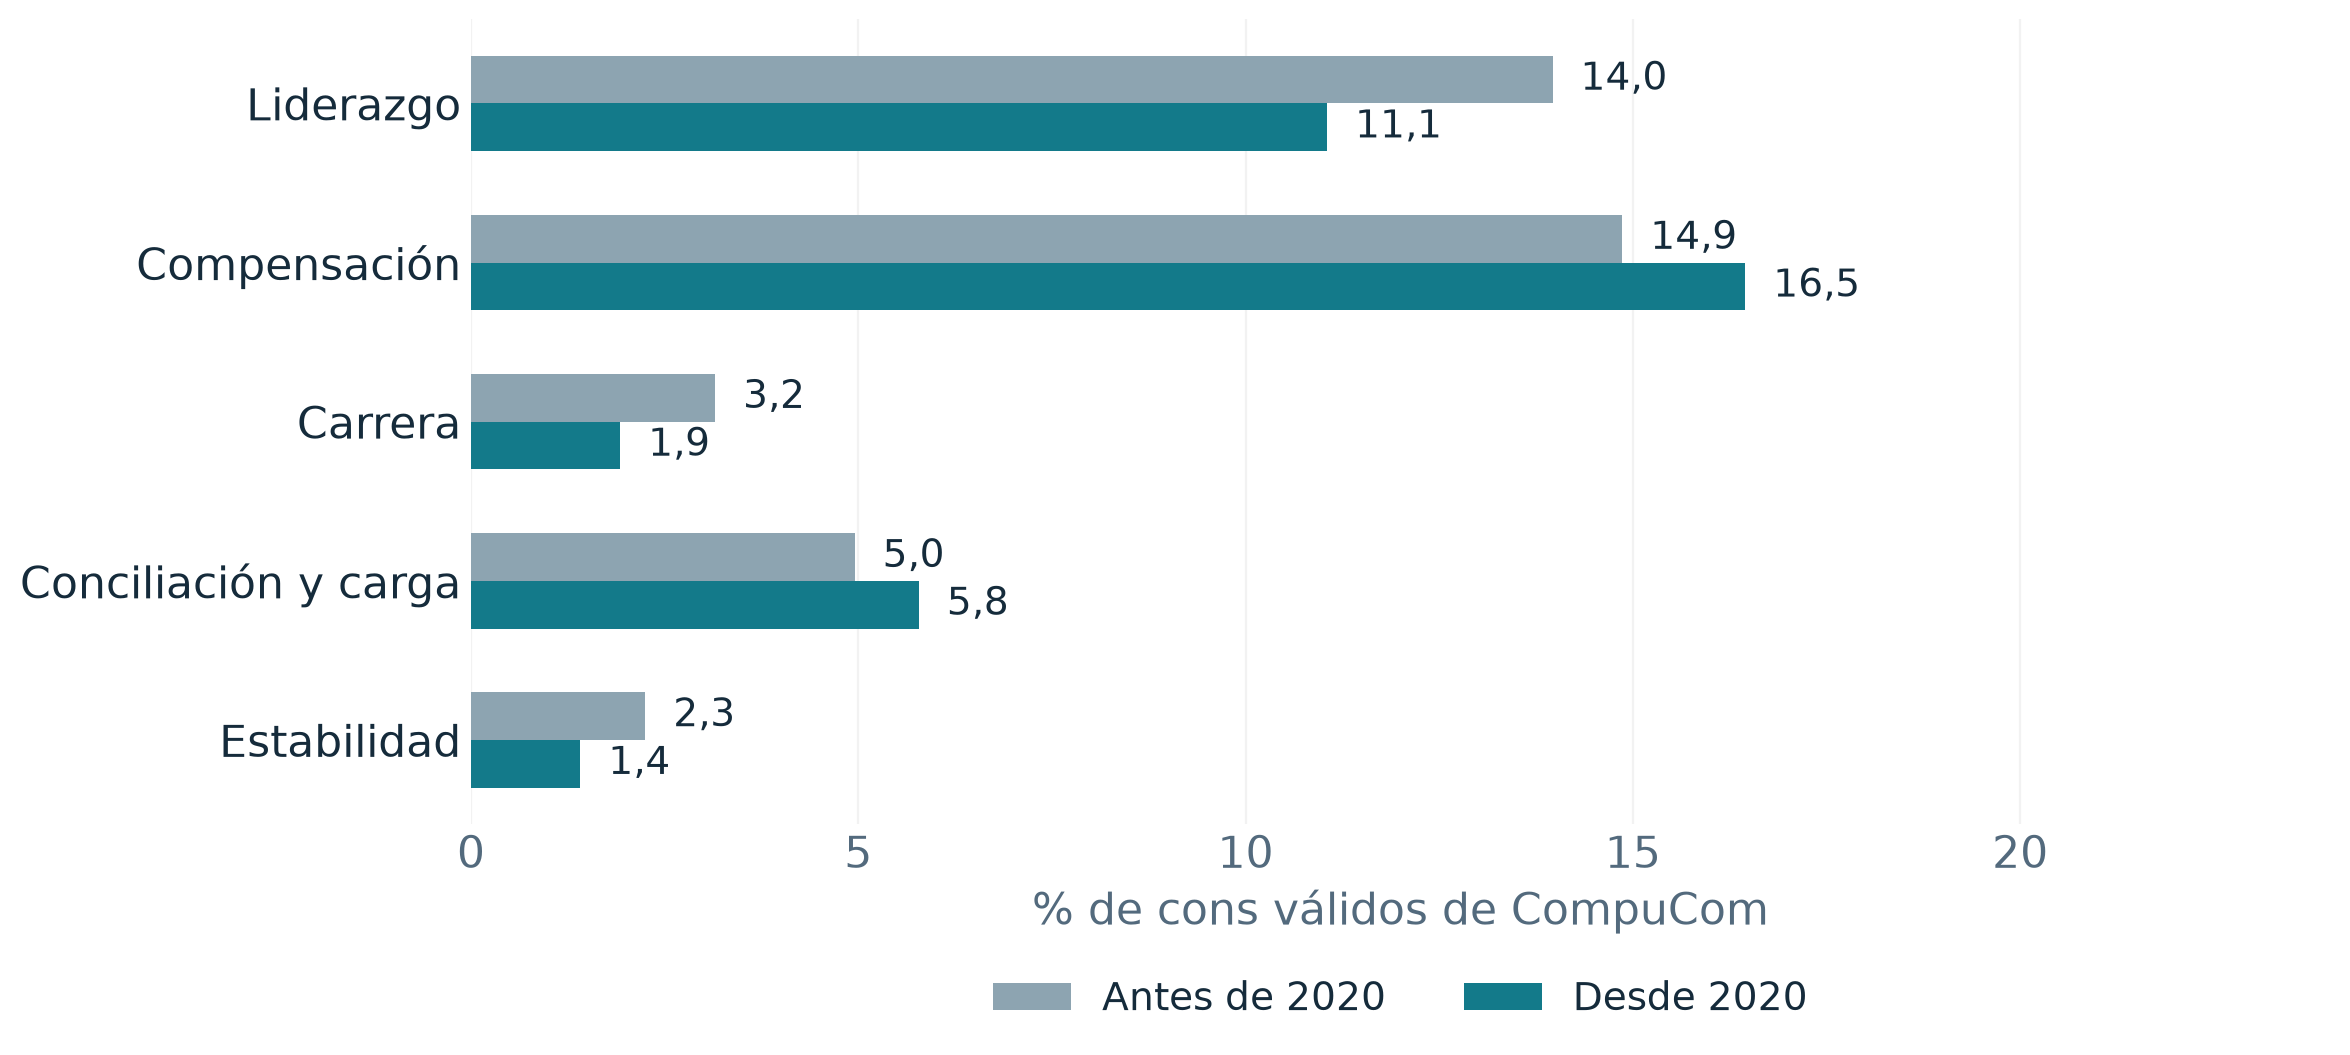

In [26]:
# Cambios de temas antes y desde 2020
firms, target, peers = FIRMS, TARGET, PEERS
labels = [NAMES[x] for x in firms]
summary = resumen
y = np.arange(len(firms))
themes = ['Management y liderazgo', 'Compensación y beneficios', 'Carrera y desarrollo', 'Conciliación y carga de trabajo', 'Estabilidad laboral']
times = tabla_temporal_topics
fig, ax = plt.subplots(figsize=(12, 5.6))
pairbars(ax, times.loc[themes, 'Antes de 2020'], times.loc[themes, 'Desde 2020'], [SHORT[c] for c in themes], 24, '', '% de cons válidos de CompuCom', 1, (GREY, TEAL), ('Antes de 2020', 'Desde 2020'))
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False, fontsize=14)
fig.tight_layout()
guardar_grafica(fig, '12_evolucion_temas')


## 8. Limitaciones, próximos pasos y entrega
- Glassdoor tiene sesgo de participación; no representa necesariamente a la plantilla ni permite estimar tasas de salida.
- Mezcla países, puestos, áreas y fechas. Los peers son comparables por actividad/escala, con tamaños históricos de fechas diferentes.
- La muestra de 1.000 reseñas por empresa añade variabilidad. Los porcentajes son composicionales y dependen de cobertura.
- El sentimiento binario puede fallar ante ironía, negación y lenguaje laboral; el truncado pierde contexto. Confianza no equivale a probabilidad de acierto calibrada.
- BERTopic asigna un asunto dominante aunque el texto contenga varios. Las etiquetas son interpretaciones humanas; outlier no significa que no haya problemas.
- Las asociaciones son descriptivas: no se calculan efectos causales ni significación estadística.
- La sensibilidad a etiquetas, umbrales y peers no cubre toda la incertidumbre del modelado.
- Los resultados describen reseñas de 2018–2023, no la plantilla actual.

**Próximos pasos:** contrastar prioridades y asuntos no cubiertos con entrevistas/encuestas internas; segmentar por puesto y país si se consiguen datos; ampliar anotación humana y evaluar clasificación multietiqueta supervisada si hay suficientes ejemplos.

**Entregables del PDF:** este notebook aporta el análisis, la matriz y conclusiones finales; el Markdown es una guía de lectura y base para la exposición. La presentación en clase o vídeo es un entregable separado que pesa el **40 %**; no queda sustituida por estos archivos.

## Referencias
- [Glassdoor Job Reviews 1, David Gauthier](https://www.kaggle.com/datasets/davidgauthier/glassdoor-job-reviews).
- [Glassdoor Job Reviews 2, David Gauthier](https://www.kaggle.com/datasets/davidgauthier/glassdoor-job-reviews-2).


## 9. Conclusiones y recomendaciones para RR. HH.
La celda final calcula los hallazgos y propone tres acciones a partir de la matriz, el contraste de indicadores y la cobertura. Los plazos son propuestas de trabajo; las metas de mejora deben acordarse tras obtener una línea base interna.


In [ ]:
ACCIONES = {
    "Management y liderazgo": ("Revisar comentarios de gestión por equipo y entrevistar a empleados y antiguos. Acordar con responsables un piloto de mejora de comunicación, trato y autonomía.", "Pulso de apoyo del responsable y autonomía; rotación voluntaria del equipo, con línea base.", "RR. HH. y responsables de área", "Diagnóstico en 30 días; piloto en 90"),
    "Compensación y beneficios": ("Contrastar salarios y beneficios por puesto/ubicación con equidad interna y mercado; explicar criterios de revisión antes de decidir ajustes.", "Brechas salariales por puesto y percepción de equidad; aceptación de ofertas.", "Compensación y beneficios", "Auditoría en 60 días"),
    "Conciliación y carga de trabajo": ("Revisar horarios, guardias y carga por equipo; acordar límites y un piloto de redistribución donde se confirme el problema.", "Horas extra/guardias y pulso de conciliación; seguimiento mensual.", "RR. HH. y operaciones", "Diagnóstico en 30 días; piloto en 90"),
    "Carrera y desarrollo": ("Revisar criterios de promoción y movimientos internos; acordar rutas de desarrollo con ejemplos y conversaciones periódicas.", "Movilidad interna y claridad de carrera en pulsos.", "Desarrollo de talento", "Diseño en 60 días"),
    "Estabilidad laboral": ("Revisar comunicación de cambios y oportunidades de recolocación; contrastar preocupaciones con entrevistas y datos internos.", "Percepción de seguridad y recolocaciones antes de desvinculación.", "RR. HH. y dirección", "Diagnóstico en 30 días"),
    "Aprendizaje y formación": ("Identificar carencias de capacitación por rol y contrastarlas con planes de incorporación y formación.", "Cobertura de capacitación y valoración de utilidad por rol.", "Formación y responsables", "Diagnóstico en 60 días"),
    "Proyectos y clientes": ("Revisar asignación de proyectos, alcance y transiciones entre clientes con empleados y operaciones.", "Tiempo sin asignación y claridad de alcance por equipo.", "RR. HH. y operaciones", "Diagnóstico en 60 días"),
    "Procesos y políticas internas": ("Identificar los procesos criticados y acordar con empleados una mejora concreta del procedimiento.", "Tiempo de respuesta y satisfacción con el procedimiento elegido.", "RR. HH. y operaciones", "Revisión en 60 días"),
    "Cultura y ambiente": ("Contrastar convivencia y colaboración con escucha interna y acordar medidas por equipo.", "Pulso de colaboración, inclusión y trato.", "RR. HH. y responsables", "Diagnóstico en 60 días"),
    "Instalaciones y servicios": ("Revisar incidencias de instalaciones y servicios y priorizar un piloto según uso y necesidad.", "Incidencias resueltas y satisfacción con el servicio.", "RR. HH. y servicios generales", "Revisión en 60 días"),
    "Ubicación y movilidad": ("Revisar traslados y desplazamientos por puesto y contrastar alternativas con afectados.", "Carga de desplazamientos y satisfacción con movilidad.", "RR. HH. y operaciones", "Revisión en 60 días"),
}
candidatas = matriz_priorizacion.loc[
    matriz_priorizacion["cons_compucom_pct"].ge(PESO_MINIMO) & matriz_priorizacion["desventaja_pp"].gt(0)
].copy()
candidatas["coherente_y_n"] = candidatas["senal_coherente_con_problema"] & candidatas["n_cons_categoria"].ge(20)
candidatas = candidatas.sort_values(["coherente_y_n", "puntuacion_operativa"], ascending=False)
mejoras_elegidas = candidatas.head(2)
fortalezas = comparacion_peers.loc[CATEGORIAS_ACCIONABLES].loc[
    lambda t: t["pros_compucom_pct"].ge(3) & t["gap_balance_pp"].gt(0)
].sort_values("gap_balance_pp", ascending=False)
filas_acciones = []
for numero, (tema, fila) in enumerate(mejoras_elegidas.iterrows(), 1):
    accion, metrica, responsable, plazo = ACCIONES[tema]
    evidencia = (
        f"Cons {fmt(fila['cons_compucom_pct'],1)} % (n={int(fila['n_cons_categoria'])}); "
        f"gap {fmt(fila['gap_balance_pp'])} pp; Δrating {fmt(fila['delta_rating'])}; "
        f"Δno recomienda {fmt(fila['delta_no_recomienda_pp'])} pp."
    )
    filas_acciones.append({
        "prioridad": numero, "tema": tema,
        "tipo": "Mejora a validar" if fila["coherente_y_n"] else ("Diagnóstico: contraste no confirma" if fila["delta_rating"] >= 0 and fila["delta_no_recomienda_pp"] <= 0 else "Diagnóstico: señal mixta"),
        "evidencia": evidencia, "accion": accion, "metrica": metrica,
        "responsable": responsable, "plazo_propuesto": plazo,
    })
if len(filas_acciones) < 3 and not fortalezas.empty:
    tema_fortaleza = fortalezas.index[0]
    fila = fortalezas.iloc[0]
    rango_fortaleza = sensibilidad_etiquetas[tema_fortaleza] if tema_fortaleza in sensibilidad_etiquetas else pd.Series([fila["gap_balance_pp"]])
    fortaleza_estable = bool(rango_fortaleza.gt(0).all() and sensibilidad_peers.loc[tema_fortaleza, "signo_estable"])
    filas_acciones.append({
        "prioridad": len(filas_acciones) + 1, "tema": tema_fortaleza,
        "tipo": "Atracción: fortaleza a comprobar" if fortaleza_estable else "Validar hipótesis: sensibilidad alta",
        "evidencia": f"Pros {fmt(fila['pros_compucom_pct'],1)} %; cons {fmt(fila['cons_compucom_pct'],1)} %; gap +{fmt(fila['gap_balance_pp'])} pp.",
        "accion": f"Revisar textos mixtos sobre {tema_fortaleza.lower()} y contrastar la experiencia por puesto con entrevistas internas. Comunicarlo en ofertas solo si se confirma; la señal cambia con decisiones de etiquetado." if not fortaleza_estable else f"Verificar que {tema_fortaleza.lower()} se mantiene en los puestos a cubrir y probar su comunicación con ejemplos en ofertas y entrevistas.",
        "metrica": "Aceptación de ofertas y feedback de candidatos por puesto; comparación con línea base.",
        "responsable": "Selección y responsables del puesto",
        "plazo_propuesto": "Validación en 30 días; prueba en 60",
    })
else:
    tema_fortaleza = None
recomendaciones = pd.DataFrame(filas_acciones)
assert len(recomendaciones) <= 3

partes = [
    f"**Posición general:** en {fmt(len(df),0)} reseñas equilibradas, CompuCom tiene rating **{fmt(resumen.loc[TARGET, 'rating_medio'])}/5** "
    f"frente a **{fmt(media_rating_peers)}** de media peer, y recomendación **{fmt(resumen.loc[TARGET, 'pct_recomienda'],1)} %** "
    f"frente a **{fmt(media_recomienda_peers)} %**. Investigar la brecha con información interna.",
]
for tema, fila in mejoras_elegidas.iterrows():
    contraste = contraste_compucom.loc[tema]
    tipo = "señal coherente con un problema" if fila["coherente_y_n"] else ("desventaja temática no confirmada por rating ni recomendación" if fila["delta_rating"] >= 0 and fila["delta_no_recomienda_pp"] <= 0 else "señal mixta que requiere diagnóstico")
    antiguos = tabla_actuales_vs_antiguos.loc[tema]
    peer_antiguos = comparacion_cons_antiguos_peers.loc[tema]
    partes.append(
        f"**{tema}:** {tipo}. Aparece en **{fmt(fila['cons_compucom_pct'],1)} %** de cons "
        f"(n={int(fila['n_cons_categoria'])}); gap de balance **{fmt(fila['gap_balance_pp'])} pp**. "
        f"Rating **{fmt(contraste['rating_categoria'])}** frente a **{fmt(contraste['rating_resto'])}** del resto; "
        f"no recomendación **{fmt(contraste['pct_no_recomienda_categoria'])} %** frente a **{fmt(contraste['pct_no_recomienda_resto'])} %**. "
        f"En antiguos pesa **{fmt(antiguos['pct_antiguos'])} %**, frente a **{fmt(antiguos['pct_actuales'])} %** en actuales "
        f"y **{fmt(peer_antiguos['pct_media_peers'])} %** en antiguos de peers. No demuestra un motivo de salida. "
        f"El gap conserva signo desfavorable en las alternativas individuales probadas "
        f"({fmt(sensibilidad_etiquetas[tema].min())} a {fmt(sensibilidad_etiquetas[tema].max())} pp); "
        "estas alternativas no cubren cambios simultáneos ni toda la incertidumbre."
    )
if tema_fortaleza:
    fila = fortalezas.iloc[0]
    partes.append(
        f"**Fortaleza provisional — {tema_fortaleza}:** pros **{fmt(fila['pros_compucom_pct'],1)} %**, "
        f"cons **{fmt(fila['cons_compucom_pct'],1)} %**, gap **+{fmt(fila['gap_balance_pp'])} pp**. "
        f"En las etiquetas alternativas el gap va de **{fmt(rango_fortaleza.min())} a {fmt(rango_fortaleza.max())} pp**. "
        + ("La señal se mantiene en estos escenarios; comprobar la experiencia por puesto antes de comunicarla." if fortaleza_estable
           else "El signo cambia: no presentar una ventaja consolidada. Revisar textos mixtos y validar la experiencia internamente antes de usarla en selección.")
    )
partes.append(
    f"**Límite del diagnóstico:** **{fmt(cobertura.loc[TARGET,'pct_cons_outliers'])} %** de cons de CompuCom es outlier; "
    f"**{fmt(cobertura.loc[TARGET,'pct_cons_otros_mixtos'])} %** es mixto/no interpretable y "
    f"**{fmt(cobertura.loc[TARGET,'pct_cons_sin_aspecto'])} %** no identifica un aspecto concreto. "
    f"La cobertura accionable es **{fmt(cobertura.loc[TARGET,'pct_cons_accionables'])} %**. "
    "La revisión de outliers confirma que hay asuntos relevantes fuera de la taxonomía. "
    "Las prioridades son hipótesis para validar, no un diagnóstico exhaustivo ni causal de toda la plantilla."
)
conclusiones_texto = "\n\n".join(partes)
mostrar(conclusiones_texto)
mostrar("### Acciones propuestas")
with pd.option_context("display.max_colwidth", None):
    display(recomendaciones)
mostrar(
    "**Condición para actuar:** contrastar primero los comentarios, la cobertura y las sensibilidades con datos internos; "
    "acordar metas después de obtener una línea base comparable. Las cifras describen reseñas históricas, no la plantilla actual."
)


**Posición general:** en 4.000 reseñas equilibradas, CompuCom tiene rating **2,91/5** frente a **3,79** de media peer, y recomendación **31,1 %** frente a **56,77 %**. Investigar la brecha con información interna.

**Management y liderazgo:** señal coherente con un problema. Aparece en **11,7 %** de cons (n=117); gap de balance **-5,23 pp**. Rating **2,27** frente a **2,99** del resto; no recomendación **64,10 %** frente a **38,84 %**. En antiguos pesa **13,85 %**, frente a **9,85 %** en actuales y **11,15 %** en antiguos de peers. No demuestra un motivo de salida. El gap conserva signo desfavorable en las alternativas individuales probadas (-5,50 a -1,90 pp); estas alternativas no cubren cambios simultáneos ni toda la incertidumbre.

**Compensación y beneficios:** desventaja temática no confirmada por rating ni recomendación. Aparece en **16,1 %** de cons (n=161); gap de balance **-7,77 pp**. Rating **2,99** frente a **2,89** del resto; no recomendación **36,65 %** frente a **42,79 %**. En antiguos pesa **12,34 %**, frente a **19,33 %** en actuales y **6,74 %** en antiguos de peers. No demuestra un motivo de salida. El gap conserva signo desfavorable en las alternativas individuales probadas (-12,33 a -7,77 pp); estas alternativas no cubren cambios simultáneos ni toda la incertidumbre.

**Fortaleza provisional — Aprendizaje y formación:** pros **6,5 %**, cons **0,0 %**, gap **+3,83 pp**. En las etiquetas alternativas el gap va de **-1,30 a 4,83 pp**. El signo cambia: no presentar una ventaja consolidada. Revisar textos mixtos y validar la experiencia internamente antes de usarla en selección.

**Límite del diagnóstico:** **44,20 %** de cons de CompuCom es outlier; **9,50 %** es mixto/no interpretable y **7,40 %** no identifica un aspecto concreto. La cobertura accionable es **38,90 %**. La revisión de outliers confirma que hay asuntos relevantes fuera de la taxonomía. Las prioridades son hipótesis para validar, no un diagnóstico exhaustivo ni causal de toda la plantilla.

### Acciones propuestas (máximo tres)

,prioridad,tema,tipo,evidencia,accion,metrica,responsable,plazo_propuesto
0,1,Management y liderazgo,Mejora a validar,"Cons 11,7 % (n=117); gap -5,23 pp; Δrating -0,72; Δno recomienda 25,26 pp.","Revisar comentarios de gestión por equipo y entrevistar a empleados y antiguos. Acordar con responsables un piloto de mejora de comunicación, trato y autonomía.","Pulso de apoyo del responsable y autonomía; rotación voluntaria del equipo, con línea base.",RR. HH. y responsables de área,Diagnóstico en 30 días; piloto en 90
1,2,Compensación y beneficios,Diagnóstico: contraste no confirma,"Cons 16,1 % (n=161); gap -7,77 pp; Δrating 0,10; Δno recomienda -6,14 pp.",Contrastar salarios y beneficios por puesto/ubicación con equidad interna y mercado; explicar criterios de revisión antes de decidir ajustes.,Brechas salariales por puesto y percepción de equidad; aceptación de ofertas.,Compensación y beneficios,Auditoría en 60 días
2,3,Aprendizaje y formación,Validar hipótesis: sensibilidad alta,"Pros 6,5 %; cons 0,0 %; gap +3,83 pp.",Revisar textos mixtos sobre aprendizaje y formación y contrastar la experiencia por puesto con entrevistas internas. Comunicarlo en ofertas solo si se confirma; la señal cambia con decisiones de etiquetado.,Aceptación de ofertas y feedback de candidatos por puesto; comparación con línea base.,Selección y responsables del puesto,Validación en 30 días; prueba en 60


**Condición para actuar:** contrastar primero los comentarios, la cobertura y las sensibilidades con datos internos; acordar metas después de obtener una línea base comparable. Las cifras describen reseñas históricas, no la plantilla actual.